
# Deep Tech Investment Analysis
### Selecting the Best Company for a $1,000,000 Venture Capital Investment

<!-- **Prepared in the style of a quantitative research note for a venture capital investment committee.**

---

**Mandate:** This notebook is *not* a stock-price forecasting exercise. Its purpose is to apply a
disciplined, repeatable, quantitative-then-qualitative screening process to a universe of ~50 deep-tech
companies (AI, Robotics, Space, Defence Technology, Quantum Computing) and arrive at a single,
well-justified recommendation for where a fund should deploy **$1,000,000**.

**Process (mirrors a real VC research workflow):**
1. Build an investable universe across five deep-tech sectors.
2. Collect quantitative data — market data for public companies, funding/traction data for private companies.
3. Clean and standardize the data (units, currencies, missingness).
4. Engineer investment-relevant features (moat, traction, risk, scalability, etc.).
5. Run exploratory data analysis to understand the landscape.
6. Run public-market financial analytics (returns, risk, drawdowns).
7. Score and rank companies with three independent multi-criteria decision methods
   (Weighted Scoring, TOPSIS, AHP) and check that they agree.
8. Cluster companies to understand the competitive landscape structurally (not just by rank).
9. Produce a final ranked shortlist, a dashboard, and a written investment recommendation.

**A note on data honesty:** Public-company figures are pulled live via `yfinance` where network access
allows. Private deep-tech companies (SpaceX, Anduril, Anthropic, PsiQuantum, etc.) do not have
machine-readable financial statements — there is no legitimate API for "Palantir-style" private
funding data without a paid provider (PitchBook, Crunchbase Pro). Where a paid data source would be
required, this notebook uses **clearly-labeled, seeded, research-informed estimates** rather than
inventing false precision. Every private-company numeric field carries a `_source` flag of either
`"public_filing"`, `"reported_press"`, or `"analyst_estimate"` so a reader always knows how much to trust
each number. This is exactly how a real associate would caveat a comp table built without a Bloomberg terminal. -->


## Section 1 — Imports & Global Configuration

In [2]:

# --- Core data stack ---
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import json
import logging
import hashlib
from dataclasses import dataclass, field, asdict
from typing import Optional, List, Dict, Any, Tuple

import numpy as np
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import missingno as msno

# --- Market data ---
import yfinance as yf

# --- Stats / ML ---
from scipy import stats
from scipy.spatial.distance import pdist, squareform
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# --- Logging setup (every module-grade project should log, not print) ---
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-7s | %(name)s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("deep_tech_vc")

# --- Global plotting config ---
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
PLOTLY_TEMPLATE = "plotly_white"

# --- Reproducibility ---
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# --- Output directory for exported artifacts ---
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

logger.info("Environment ready. Random seed=%s, output dir='%s'", RANDOM_SEED, OUTPUT_DIR)



## Section 2 — Building the Investable Universe

<!-- **Why:** Before any quant screen can run, we need a defensible, diversified universe. A VC fund doesn't
analyze "the market" — it analyzes a deliberately chosen set of comparable companies inside its mandate
(here: deep tech). We hand-curate ~50 real, named companies across five sectors, mixing public companies
(tradable, so we get hard market data) and private companies (the most interesting deep-tech bets — most
frontier AI, space, and defence companies are still private).

**How to interpret this section:** This is metadata only — no financial judgement yet. Think of it as the
"deal sourcing" stage of a VC fund: casting a wide, sector-diversified net before any scoring happens. -->


In [3]:

@dataclass
class CompanyRecord:
    '''Static metadata describing a single company in the investable universe.

    This is intentionally separate from *financial* data (Section 3+) because metadata
    rarely changes while financials are refreshed on every pull.
    '''
    company: str
    sector: str
    country: str
    is_public: bool
    ticker: Optional[str]
    founded: int
    headquarters: str
    website: str


# NOTE ON SOURCING: company names, founding years, HQ and public/private status below are
# general public knowledge (company "about" pages / Wikipedia-level facts) compiled by hand,
# which is the only legitimate way to build a private-company universe without a paid
# data vendor (PitchBook/Crunchbase) or live web scraping of those vendors' paywalled pages.

UNIVERSE_RAW: List[Dict[str, Any]] = [
    # ---------------- Artificial Intelligence (10) ----------------
    dict(company="NVIDIA",            sector="Artificial Intelligence", country="USA",  is_public=True,  ticker="NVDA", founded=1993, headquarters="Santa Clara, CA",  website="nvidia.com"),
    dict(company="Microsoft",         sector="Artificial Intelligence", country="USA",  is_public=True,  ticker="MSFT", founded=1975, headquarters="Redmond, WA",      website="microsoft.com"),
    dict(company="Alphabet (Google)", sector="Artificial Intelligence", country="USA",  is_public=True,  ticker="GOOGL",founded=1998, headquarters="Mountain View, CA",website="abc.xyz"),
    dict(company="Palantir",          sector="Artificial Intelligence", country="USA",  is_public=True,  ticker="PLTR", founded=2003, headquarters="Denver, CO",       website="palantir.com"),
    dict(company="C3.ai",             sector="Artificial Intelligence", country="USA",  is_public=True,  ticker="AI",   founded=2009, headquarters="Redwood City, CA", website="c3.ai"),
    dict(company="SoundHound AI",     sector="Artificial Intelligence", country="USA",  is_public=True,  ticker="SOUN", founded=2005, headquarters="Santa Clara, CA",  website="soundhound.com"),
    dict(company="OpenAI",            sector="Artificial Intelligence", country="USA",  is_public=False, ticker=None,   founded=2015, headquarters="San Francisco, CA",website="openai.com"),
    dict(company="Anthropic",         sector="Artificial Intelligence", country="USA",  is_public=False, ticker=None,   founded=2021, headquarters="San Francisco, CA",website="anthropic.com"),
    dict(company="Mistral AI",        sector="Artificial Intelligence", country="France",is_public=False,ticker=None,   founded=2023, headquarters="Paris",            website="mistral.ai"),
    dict(company="Cohere",            sector="Artificial Intelligence", country="Canada",is_public=False,ticker=None,   founded=2019, headquarters="Toronto",          website="cohere.com"),

    # ---------------- Robotics (10) ----------------
    dict(company="Intuitive Surgical",sector="Robotics", country="USA",   is_public=True,  ticker="ISRG", founded=1995, headquarters="Sunnyvale, CA",     website="intuitive.com"),
    dict(company="ABB Ltd",           sector="Robotics", country="Switzerland",is_public=True,ticker="ABB", founded=1988, headquarters="Zurich",            website="abb.com"),
    dict(company="Fanuc Corp",        sector="Robotics", country="Japan", is_public=True,  ticker="6954.T",founded=1972, headquarters="Yamanashi",         website="fanuc.com"),
    dict(company="iRobot",            sector="Robotics", country="USA",   is_public=True,  ticker="IRBT", founded=1990, headquarters="Bedford, MA",       website="irobot.com"),
    dict(company="Symbotic",          sector="Robotics", country="USA",   is_public=True,  ticker="SYM",  founded=2007, headquarters="Wilmington, MA",    website="symbotic.com"),
    dict(company="Serve Robotics",    sector="Robotics", country="USA",   is_public=True,  ticker="SERV", founded=2017, headquarters="Redwood City, CA",  website="serverobotics.com"),
    dict(company="Boston Dynamics",   sector="Robotics", country="USA",   is_public=False, ticker=None,   founded=1992, headquarters="Waltham, MA",       website="bostondynamics.com"),
    dict(company="Figure AI",         sector="Robotics", country="USA",   is_public=False, ticker=None,   founded=2022, headquarters="Sunnyvale, CA",     website="figure.ai"),
    dict(company="Agility Robotics",  sector="Robotics", country="USA",   is_public=False, ticker=None,   founded=2015, headquarters="Corvallis, OR",     website="agilityrobotics.com"),
    dict(company="Skild AI",          sector="Robotics", country="USA",   is_public=False, ticker=None,   founded=2023, headquarters="Pittsburgh, PA",    website="skild.ai"),

    # ---------------- Space Technology (10) ----------------
    dict(company="Rocket Lab",        sector="Space Technology", country="USA", is_public=True,  ticker="RKLB", founded=2006, headquarters="Long Beach, CA",   website="rocketlabusa.com"),
    dict(company="Intuitive Machines",sector="Space Technology", country="USA", is_public=True,  ticker="LUNR", founded=2013, headquarters="Houston, TX",      website="intuitivemachines.com"),
    dict(company="Redwire",           sector="Space Technology", country="USA", is_public=True,  ticker="RDW",  founded=2020, headquarters="Jacksonville, FL", website="redwirespace.com"),
    dict(company="AST SpaceMobile",   sector="Space Technology", country="USA", is_public=True,  ticker="ASTS", founded=2017, headquarters="Midland, TX",      website="ast-science.com"),
    dict(company="Planet Labs",       sector="Space Technology", country="USA", is_public=True,  ticker="PL",   founded=2010, headquarters="San Francisco, CA",website="planet.com"),
    dict(company="Iridium Communications", sector="Space Technology", country="USA", is_public=True, ticker="IRDM", founded=2000, headquarters="McLean, VA", website="iridium.com"),
    dict(company="SpaceX",            sector="Space Technology", country="USA", is_public=False, ticker=None,   founded=2002, headquarters="Hawthorne, CA",    website="spacex.com"),
    dict(company="Blue Origin",       sector="Space Technology", country="USA", is_public=False, ticker=None,   founded=2000, headquarters="Kent, WA",         website="blueorigin.com"),
    dict(company="Relativity Space",  sector="Space Technology", country="USA", is_public=False, ticker=None,   founded=2015, headquarters="Long Beach, CA",   website="relativityspace.com"),
    dict(company="ICEYE",             sector="Space Technology", country="Finland", is_public=False, ticker=None, founded=2014, headquarters="Espoo",          website="iceye.com"),

    # ---------------- Defence Technology (10) ----------------
    dict(company="Lockheed Martin",   sector="Defence Technology", country="USA", is_public=True,  ticker="LMT", founded=1995, headquarters="Bethesda, MD",   website="lockheedmartin.com"),
    dict(company="Northrop Grumman",  sector="Defence Technology", country="USA", is_public=True,  ticker="NOC", founded=1994, headquarters="Falls Church, VA",website="northropgrumman.com"),
    dict(company="RTX Corporation",   sector="Defence Technology", country="USA", is_public=True,  ticker="RTX", founded=2020, headquarters="Arlington, VA",   website="rtx.com"),
    dict(company="L3Harris Technologies", sector="Defence Technology", country="USA", is_public=True, ticker="LHX", founded=2019, headquarters="Melbourne, FL", website="l3harris.com"),
    dict(company="Kratos Defense",    sector="Defence Technology", country="USA", is_public=True,  ticker="KTOS",founded=1994, headquarters="San Diego, CA",  website="kratosdefense.com"),
    dict(company="BAE Systems",       sector="Defence Technology", country="UK",  is_public=True,  ticker="BA.L",founded=1999, headquarters="London",         website="baesystems.com"),
    dict(company="Anduril Industries",sector="Defence Technology", country="USA", is_public=False, ticker=None,  founded=2017, headquarters="Costa Mesa, CA", website="anduril.com"),
    dict(company="Shield AI",         sector="Defence Technology", country="USA", is_public=False, ticker=None,  founded=2015, headquarters="San Diego, CA",  website="shield.ai"),
    dict(company="Saronic Technologies",sector="Defence Technology", country="USA", is_public=False, ticker=None,founded=2022, headquarters="Austin, TX",     website="saronic.com"),
    dict(company="Helsing",           sector="Defence Technology", country="Germany", is_public=False, ticker=None, founded=2021, headquarters="Munich",      website="helsing.ai"),

    # ---------------- Quantum Computing (9) ----------------
    dict(company="IonQ",              sector="Quantum Computing", country="USA", is_public=True,  ticker="IONQ",founded=2015, headquarters="College Park, MD", website="ionq.com"),
    dict(company="Rigetti Computing",  sector="Quantum Computing", country="USA", is_public=True,  ticker="RGTI",founded=2013, headquarters="Berkeley, CA",     website="rigetti.com"),
    dict(company="D-Wave Quantum",    sector="Quantum Computing", country="Canada", is_public=True,ticker="QBTS",founded=1999, headquarters="Palo Alto, CA",    website="dwavequantum.com"),
    dict(company="Quantum Computing Inc.", sector="Quantum Computing", country="USA", is_public=True, ticker="QUBT", founded=2018, headquarters="Leesburg, VA", website="quantumcomputinginc.com"),
    dict(company="IBM",               sector="Quantum Computing", country="USA", is_public=True,  ticker="IBM", founded=1911, headquarters="Armonk, NY",       website="ibm.com"),
    dict(company="PsiQuantum",        sector="Quantum Computing", country="USA", is_public=False, ticker=None,  founded=2016, headquarters="Palo Alto, CA",    website="psiquantum.com"),
    dict(company="Quantinuum",        sector="Quantum Computing", country="USA", is_public=False, ticker=None,  founded=2021, headquarters="Broomfield, CO",   website="quantinuum.com"),
    dict(company="Pasqal",            sector="Quantum Computing", country="France", is_public=False, ticker=None,founded=2019, headquarters="Massy",           website="pasqal.com"),
    dict(company="Xanadu",            sector="Quantum Computing", country="Canada", is_public=False,ticker=None, founded=2016, headquarters="Toronto",         website="xanadu.ai"),
]

universe = [CompanyRecord(**row) for row in UNIVERSE_RAW]
df_universe = pd.DataFrame([asdict(c) for c in universe])

logger.info("Universe built: %d companies across %d sectors (%d public / %d private)",
            len(df_universe), df_universe["sector"].nunique(),
            df_universe["is_public"].sum(), (~df_universe["is_public"]).sum())

df_universe.head(10)


,company,sector,country,is_public,ticker,founded,headquarters,website
0,NVIDIA,Artificial Intelligence,USA,True,NVDA,1993,"Santa Clara, CA",nvidia.com
1,Microsoft,Artificial Intelligence,USA,True,MSFT,1975,"Redmond, WA",microsoft.com
2,Alphabet (Google),Artificial Intelligence,USA,True,GOOGL,1998,"Mountain View, CA",abc.xyz
3,Palantir,Artificial Intelligence,USA,True,PLTR,2003,"Denver, CO",palantir.com
4,C3.ai,Artificial Intelligence,USA,True,AI,2009,"Redwood City, CA",c3.ai
5,SoundHound AI,Artificial Intelligence,USA,True,SOUN,2005,"Santa Clara, CA",soundhound.com
6,OpenAI,Artificial Intelligence,USA,False,None,2015,"San Francisco, CA",openai.com
7,Anthropic,Artificial Intelligence,USA,False,None,2021,"San Francisco, CA",anthropic.com
8,Mistral AI,Artificial Intelligence,France,False,None,2023,Paris,mistral.ai
9,Cohere,Artificial Intelligence,Canada,False,None,2019,Toronto,cohere.com


In [4]:

# Sanity check: sector balance (target ~8-10 per sector)
df_universe.groupby("sector").agg(
    n_companies=("company", "count"),
    n_public=("is_public", "sum"),
).assign(n_private=lambda d: d["n_companies"] - d["n_public"])


,n_companies,n_public,n_private
sector,,,
Artificial Intelligence,10,6,4
Defence Technology,10,6,4
Quantum Computing,9,5,4
Robotics,10,6,4
Space Technology,10,6,4



## Section 3 — Data Collection: Public Companies (Market Data via `yfinance`)
<!--
**Why:** Public companies give us the only *objective, market-verified* numbers in this entire universe —
price, market cap, multiples — because they are audited and continuously priced by the market. We pull
this data live with `yfinance`.

**Resilience design:** Live financial APIs fail constantly in practice (rate limits, ticker delisting,
sandboxed/offline environments, weekend data gaps). A production-grade pipeline must **never crash** on a
single bad ticker. Every fetch below is wrapped in error handling and logs a warning rather than raising,
and falls back to a clearly-flagged seeded estimate if (and only if) the live API is unreachable, so the
notebook always finishes a full run end-to-end. The fallback path is **deterministic** (seeded by ticker)
so re-runs are reproducible, and every record is tagged with `data_source` in {"yfinance_live", "fallback_estimate"}. -->


In [5]:

def _safe_get(d: dict, key: str, default=np.nan):
    '''Defensive dict lookup used because yfinance's `.info` payload has wildly
    inconsistent keys across tickers/exchanges.'''
    val = d.get(key, default)
    return val if val not in (None, "None", "") else default


def _seed_from_string(s: str) -> int:
    '''Deterministic integer seed derived from a string (so fallback data is
    reproducible per-ticker rather than purely random on every run).'''
    return int(hashlib.md5(s.encode()).hexdigest(), 16) % (2**32 - 1)


def _fallback_public_financials(ticker: str, sector: str) -> Dict[str, Any]:
    '''Deterministic, sector-aware synthetic fallback used only when the live
    market-data API is unreachable (e.g. an offline/sandboxed execution environment).

    This is NOT meant to simulate real prices for trading purposes -- it exists purely
    so the rest of the analytical pipeline (which expects a populated DataFrame) can be
    demonstrated end-to-end without a live network connection. Every row produced this
    way is tagged data_source='fallback_estimate' and should be replaced with a live
    pull before any real investment decision is made.
    '''
    rng = np.random.default_rng(_seed_from_string(ticker))
    sector_mcap_scale = {
        "Artificial Intelligence": 3.5e11, "Robotics": 4.0e10, "Space Technology": 4.0e9,
        "Defence Technology": 8.0e10, "Quantum Computing": 1.5e9,
    }.get(sector, 2.0e10)

    market_cap = max(5e7, rng.lognormal(mean=np.log(sector_mcap_scale), sigma=1.1))
    revenue = market_cap / rng.uniform(3, 25)
    price = rng.uniform(5, 600)

    n_days = 756
    mu, sigma = rng.uniform(0.05, 0.25), rng.uniform(0.25, 0.75)
    dt = 1 / 252
    shocks = rng.normal((mu - 0.5 * sigma**2) * dt, sigma * np.sqrt(dt), n_days)
    price_path = price * np.exp(np.cumsum(shocks))
    dates = pd.bdate_range(end=pd.Timestamp.today(), periods=n_days)
    hist = pd.DataFrame({"Close": price_path}, index=dates)

    return dict(
        market_cap=market_cap, revenue=revenue, enterprise_value=market_cap * rng.uniform(0.95, 1.15),
        pe_ratio=rng.uniform(8, 60), ps_ratio=market_cap / revenue,
        week52_high=price_path.max(), week52_low=price_path.min(),
        beta=rng.uniform(0.6, 2.2), avg_volume=int(rng.uniform(2e5, 2e7)),
        revenue_growth=rng.uniform(-0.1, 0.6), operating_margin=rng.uniform(-0.3, 0.35),
        gross_margin=rng.uniform(0.2, 0.85), cash=market_cap * rng.uniform(0.02, 0.25),
        debt=market_cap * rng.uniform(0.0, 0.3), price_history=hist, data_source="fallback_estimate",
    )


def fetch_public_financials(ticker: str, sector: str) -> Dict[str, Any]:
    '''Fetch market and fundamental data for a single public company.

    Tries a live `yfinance` pull first; on *any* failure (network, bad ticker,
    rate limiting, missing fields) logs a warning and substitutes a seeded
    fallback so the pipeline never halts.

    Args:
        ticker: Exchange ticker symbol (e.g. "NVDA").
        sector: Deep-tech sector, used to scale fallback estimates sensibly.

    Returns:
        Dictionary of financial fields, always including a 'data_source' flag
        and a 'price_history' DataFrame (Close prices, daily).
    '''
    try:
        tk = yf.Ticker(ticker)
        info = tk.info
        hist = tk.history(period="3y", interval="1d", auto_adjust=True)
        if not info or hist is None or hist.empty:
            raise ValueError("Empty response from yfinance (no info/history).")

        result = dict(
            market_cap=_safe_get(info, "marketCap"),
            revenue=_safe_get(info, "totalRevenue"),
            enterprise_value=_safe_get(info, "enterpriseValue"),
            pe_ratio=_safe_get(info, "trailingPE"),
            ps_ratio=_safe_get(info, "priceToSalesTrailing12Months"),
            week52_high=_safe_get(info, "fiftyTwoWeekHigh"),
            week52_low=_safe_get(info, "fiftyTwoWeekLow"),
            beta=_safe_get(info, "beta"),
            avg_volume=_safe_get(info, "averageVolume"),
            revenue_growth=_safe_get(info, "revenueGrowth"),
            operating_margin=_safe_get(info, "operatingMargins"),
            gross_margin=_safe_get(info, "grossMargins"),
            cash=_safe_get(info, "totalCash"),
            debt=_safe_get(info, "totalDebt"),
            price_history=hist[["Close"]].copy(),
            data_source="yfinance_live",
        )
        logger.info("[%s] live data fetched OK.", ticker)
        return result

    except Exception as exc:
        logger.warning("[%s] live fetch failed (%s) -- using seeded fallback estimate.", ticker, exc)
        return _fallback_public_financials(ticker, sector)


public_records = []
price_histories: Dict[str, pd.DataFrame] = {}

for rec in universe:
    if not rec.is_public:
        continue
    data = fetch_public_financials(rec.ticker, rec.sector)
    price_histories[rec.ticker] = data.pop("price_history")
    public_records.append({"company": rec.company, "ticker": rec.ticker, **data})
    time.sleep(0.05)

df_public_financials = pd.DataFrame(public_records)
logger.info("Public financials collected for %d companies (%d live / %d fallback).",
            len(df_public_financials),
            (df_public_financials["data_source"] == "yfinance_live").sum(),
            (df_public_financials["data_source"] == "fallback_estimate").sum())

df_public_financials.head(10)


ERROR:yfinance:$ABB: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: IRBT"}}}
ERROR:yfinance:$IRBT: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")


,company,ticker,market_cap,revenue,enterprise_value,pe_ratio,ps_ratio,week52_high,week52_low,beta,avg_volume,revenue_growth,operating_margin,gross_margin,cash,debt,data_source
0,NVIDIA,NVDA,4.718977e+12,2.534910e+11,4.674528e+12,29.836140,18.615955,236.540000,157.340000,2.211000,158966993,0.852000,0.655960,0.741450,5.317200e+10,1.281400e+10,yfinance_live
1,Microsoft,MSFT,2.900730e+12,3.182730e+11,2.947934e+12,23.257294,9.113967,555.450000,349.200000,1.130000,39839227,0.183000,0.463260,0.683090,7.822800e+10,1.254320e+11,yfinance_live
2,Alphabet (Google),GOOGL,4.391828e+12,4.224980e+11,4.329706e+12,27.474045,10.394908,408.610000,172.770000,1.247000,31502337,0.218000,0.361210,0.603680,1.268400e+11,9.587600e+10,yfinance_live
3,Palantir,PLTR,3.099724e+11,5.224174e+09,3.022646e+11,145.280900,59.334248,207.520000,106.370000,1.562000,45890253,0.847000,0.461840,0.840740,8.026413e+09,2.119770e+08,yfinance_live
4,C3.ai,AI,1.408371e+09,2.502680e+08,8.916024e+08,NaN,5.627449,30.110000,7.675000,2.052000,6081903,-0.525000,-2.138180,0.309200,5.754490e+08,5.868100e+07,yfinance_live
5,SoundHound AI,SOUN,2.834641e+09,1.839860e+08,2.625225e+09,NaN,15.406831,22.170000,5.830000,2.810000,28021019,0.517000,-1.392990,0.405870,2.156420e+08,6.226000e+06,yfinance_live
6,Intuitive Surgical,ISRG,1.508769e+11,1.058210e+10,1.464823e+11,51.826035,14.257748,603.880000,396.680000,1.460000,2402187,0.230000,0.308680,0.662920,4.517300e+09,0.000000e+00,yfinance_live
7,ABB Ltd,ABB,1.213969e+10,5.513189e+08,1.232621e+10,51.895695,22.019357,18.426570,3.969233,1.882916,15999418,0.357514,0.031521,0.791129,2.653988e+09,1.099938e+09,fallback_estimate
8,Fanuc Corp,6954.T,6.941766e+12,8.578310e+11,6.205973e+12,41.665733,8.092230,8880.000000,3699.000000,0.945000,6896468,0.106000,0.239040,0.382900,7.538710e+11,0.000000e+00,yfinance_live
9,iRobot,IRBT,1.735164e+11,1.521407e+10,1.698555e+11,48.223094,11.404990,889.577458,334.065600,1.376525,10879693,0.233019,0.221548,0.419504,1.346312e+10,1.542005e+10,fallback_estimate



## Section 4 — Data Collection: Private Companies

<!-- **Why:** Most of the *highest-conviction* deep-tech bets right now (SpaceX, Anthropic, Anduril,
PsiQuantum, Helsing...) are private. A VC analysis that only looked at public comps would miss the
entire point of venture investing. But private companies don't file 10-Ks -- there is no legitimate, free,
machine-readable API for funding rounds and valuations (real tools like Crunchbase/PitchBook require paid
licenses and forbid bulk scraping in their ToS).

**Methodology used here:** for each private company we record **research-informed point estimates**
of widely-reported figures (most recent disclosed funding round, lead investor, employee-count band, and
qualitative flags such as government contracts / patents / partnerships) compiled from general public
knowledge as of the notebook's last edit, structured the way a VC associate would build a manual comp
sheet before a paid data terminal is available. Every numeric field carries an explicit
`confidence` tag (`"reported"` = matches a widely publicized figure, `"estimate"` = analyst approximation)
so nothing is silently treated as more precise than it is. -->


In [6]:

@dataclass
class PrivateCompanyData:
    company: str
    funding_raised_usd: float
    latest_valuation_usd: float
    latest_round: str
    lead_investors: str
    estimated_employees: int
    government_contracts: bool
    major_customers: str
    patents_estimate: int
    research_publications_estimate: int
    strategic_partnerships: int
    technology_category: str
    product_stage: str
    commercial_traction: str
    confidence: str


PRIVATE_RAW: List[Dict[str, Any]] = [
    dict(company="OpenAI", funding_raised_usd=63e9, latest_valuation_usd=300e9, latest_round="Tender Offer 2025",
         lead_investors="Thrive Capital, Microsoft, SoftBank", estimated_employees=3500, government_contracts=True,
         major_customers="Microsoft, Enterprise API customers", patents_estimate=40, research_publications_estimate=300,
         strategic_partnerships=6, technology_category="Foundation Models / LLMs", product_stage="Scaling",
         commercial_traction="Very High", confidence="reported"),
    dict(company="Anthropic", funding_raised_usd=18e9, latest_valuation_usd=183e9, latest_round="Series F 2025",
         lead_investors="ICONIQ, Fidelity, Lightspeed", estimated_employees=2000, government_contracts=True,
         major_customers="Amazon, Google Cloud, Enterprise API customers", patents_estimate=15, research_publications_estimate=120,
         strategic_partnerships=5, technology_category="Foundation Models / AI Safety", product_stage="Scaling",
         commercial_traction="Very High", confidence="reported"),
    dict(company="Mistral AI", funding_raised_usd=2.6e9, latest_valuation_usd=14e9, latest_round="Series C 2025",
         lead_investors="ASML, General Catalyst", estimated_employees=400, government_contracts=False,
         major_customers="European enterprises, Microsoft Azure", patents_estimate=5, research_publications_estimate=25,
         strategic_partnerships=4, technology_category="Open-weight Foundation Models", product_stage="Early Commercial",
         commercial_traction="High", confidence="reported"),
    dict(company="Cohere", funding_raised_usd=1.7e9, latest_valuation_usd=6.8e9, latest_round="Series D 2025",
         lead_investors="PSP Investments, AMD", estimated_employees=500, government_contracts=True,
         major_customers="Enterprise / Government of Canada", patents_estimate=4, research_publications_estimate=30,
         strategic_partnerships=3, technology_category="Enterprise LLMs", product_stage="Early Commercial",
         commercial_traction="Medium", confidence="estimate"),

    dict(company="Boston Dynamics", funding_raised_usd=1.0e9, latest_valuation_usd=1.6e9, latest_round="Hyundai majority stake 2021",
         lead_investors="Hyundai Motor Group", estimated_employees=600, government_contracts=True,
         major_customers="Industrial / logistics customers, DoD research", patents_estimate=150, research_publications_estimate=80,
         strategic_partnerships=4, technology_category="Legged & Humanoid Robotics", product_stage="Early Commercial",
         commercial_traction="Medium", confidence="estimate"),
    dict(company="Figure AI", funding_raised_usd=1.5e9, latest_valuation_usd=39e9, latest_round="Series C 2025",
         lead_investors="Parkway Venture Capital, Nvidia, Microsoft", estimated_employees=300, government_contracts=False,
         major_customers="BMW (pilot deployment)", patents_estimate=10, research_publications_estimate=5,
         strategic_partnerships=3, technology_category="Humanoid Robotics", product_stage="Pilot",
         commercial_traction="Medium", confidence="reported"),
    dict(company="Agility Robotics", funding_raised_usd=0.21e9, latest_valuation_usd=1.0e9, latest_round="Series B Extension 2024",
         lead_investors="DCVC, Amazon Industrial Innovation Fund", estimated_employees=200, government_contracts=False,
         major_customers="GXO Logistics, Amazon (pilot)", patents_estimate=25, research_publications_estimate=10,
         strategic_partnerships=2, technology_category="Bipedal Logistics Robots", product_stage="Pilot",
         commercial_traction="Medium", confidence="estimate"),
    dict(company="Skild AI", funding_raised_usd=0.49e9, latest_valuation_usd=4.5e9, latest_round="Series B 2025",
         lead_investors="SoftBank, Coatue, Nvidia", estimated_employees=120, government_contracts=False,
         major_customers="Robotics OEM partners (undisclosed)", patents_estimate=3, research_publications_estimate=8,
         strategic_partnerships=2, technology_category="General-purpose Robot Foundation Models", product_stage="R&D",
         commercial_traction="Low", confidence="estimate"),

    dict(company="SpaceX", funding_raised_usd=12e9, latest_valuation_usd=400e9, latest_round="Tender Offer 2025",
         lead_investors="a16z, Founders Fund, Sequoia", estimated_employees=14000, government_contracts=True,
         major_customers="NASA, US Space Force, Starlink consumers", patents_estimate=300, research_publications_estimate=20,
         strategic_partnerships=8, technology_category="Launch Vehicles / Satellite Internet", product_stage="Scaling",
         commercial_traction="Very High", confidence="reported"),
    dict(company="Blue Origin", funding_raised_usd=2.5e9, latest_valuation_usd=24e9, latest_round="Strategic round 2023",
         lead_investors="Bezos Expeditions", estimated_employees=11000, government_contracts=True,
         major_customers="NASA (HLS), US Space Force", patents_estimate=150, research_publications_estimate=10,
         strategic_partnerships=4, technology_category="Launch Vehicles / Lunar Landers", product_stage="Scaling",
         commercial_traction="Medium", confidence="estimate"),
    dict(company="Relativity Space", funding_raised_usd=1.8e9, latest_valuation_usd=4.2e9, latest_round="Series F 2021",
         lead_investors="Fidelity, BlackRock", estimated_employees=1000, government_contracts=True,
         major_customers="US Government, commercial satellite operators", patents_estimate=40, research_publications_estimate=5,
         strategic_partnerships=2, technology_category="3D-Printed Rockets", product_stage="Pilot",
         commercial_traction="Low", confidence="estimate"),
    dict(company="ICEYE", funding_raised_usd=0.81e9, latest_valuation_usd=2.0e9, latest_round="Series E 2024",
         lead_investors="True Ventures, Solidium", estimated_employees=450, government_contracts=True,
         major_customers="NATO governments, insurance companies", patents_estimate=20, research_publications_estimate=15,
         strategic_partnerships=3, technology_category="SAR Satellite Imaging", product_stage="Early Commercial",
         commercial_traction="High", confidence="estimate"),

    dict(company="Anduril Industries", funding_raised_usd=6.5e9, latest_valuation_usd=30.5e9, latest_round="Series G 2025",
         lead_investors="Founders Fund, a16z", estimated_employees=4000, government_contracts=True,
         major_customers="US DoD, UK MoD, Australia", patents_estimate=60, research_publications_estimate=5,
         strategic_partnerships=5, technology_category="Autonomous Defence Systems", product_stage="Scaling",
         commercial_traction="Very High", confidence="reported"),
    dict(company="Shield AI", funding_raised_usd=1.2e9, latest_valuation_usd=5.3e9, latest_round="Series F 2024",
         lead_investors="Hanwha, Snowpoint Ventures", estimated_employees=750, government_contracts=True,
         major_customers="US DoD, allied air forces", patents_estimate=20, research_publications_estimate=4,
         strategic_partnerships=3, technology_category="Autonomous Aircraft / AI Pilots", product_stage="Early Commercial",
         commercial_traction="High", confidence="estimate"),
    dict(company="Saronic Technologies", funding_raised_usd=0.6e9, latest_valuation_usd=4.0e9, latest_round="Series C 2025",
         lead_investors="Andreessen Horowitz, General Catalyst", estimated_employees=250, government_contracts=True,
         major_customers="US Navy", patents_estimate=8, research_publications_estimate=2,
         strategic_partnerships=2, technology_category="Autonomous Surface Vessels", product_stage="Pilot",
         commercial_traction="Medium", confidence="estimate"),
    dict(company="Helsing", funding_raised_usd=1.2e9, latest_valuation_usd=12e9, latest_round="Series D 2025",
         lead_investors="General Catalyst, Accel", estimated_employees=750, government_contracts=True,
         major_customers="German/UK/Ukrainian armed forces", patents_estimate=10, research_publications_estimate=3,
         strategic_partnerships=4, technology_category="AI Defence Software & Drones", product_stage="Early Commercial",
         commercial_traction="High", confidence="estimate"),

    dict(company="PsiQuantum", funding_raised_usd=1.0e9, latest_valuation_usd=7.0e9, latest_round="Series D 2024",
         lead_investors="BlackRock, Blackbird Ventures", estimated_employees=400, government_contracts=True,
         major_customers="US/Australian governments (fab partnerships)", patents_estimate=50, research_publications_estimate=60,
         strategic_partnerships=3, technology_category="Photonic Fault-Tolerant Quantum Computing", product_stage="R&D",
         commercial_traction="Low", confidence="estimate"),
    dict(company="Quantinuum", funding_raised_usd=0.63e9, latest_valuation_usd=10e9, latest_round="Strategic round 2024",
         lead_investors="Honeywell, Quanta Computer", estimated_employees=500, government_contracts=True,
         major_customers="JPMorgan, Mitsubishi, DARPA", patents_estimate=400, research_publications_estimate=150,
         strategic_partnerships=5, technology_category="Trapped-Ion Quantum Computing", product_stage="Early Commercial",
         commercial_traction="Medium", confidence="estimate"),
    dict(company="Pasqal", funding_raised_usd=0.3e9, latest_valuation_usd=1.0e9, latest_round="Series C 2025",
         lead_investors="European Innovation Council, Temasek", estimated_employees=250, government_contracts=True,
         major_customers="French/EU government labs", patents_estimate=20, research_publications_estimate=70,
         strategic_partnerships=3, technology_category="Neutral-Atom Quantum Computing", product_stage="R&D",
         commercial_traction="Low", confidence="estimate"),
    dict(company="Xanadu", funding_raised_usd=0.34e9, latest_valuation_usd=1.0e9, latest_round="Series C 2022",
         lead_investors="Georgian, Public Sector Pension Investment Board", estimated_employees=200, government_contracts=False,
         major_customers="Research institutions, cloud quantum users", patents_estimate=15, research_publications_estimate=90,
         strategic_partnerships=2, technology_category="Photonic Quantum Computing", product_stage="R&D",
         commercial_traction="Low", confidence="estimate"),
]

private_companies = [PrivateCompanyData(**row) for row in PRIVATE_RAW]
df_private = pd.DataFrame([asdict(c) for c in private_companies])

logger.info("Private company dataset collected for %d companies (%d 'reported', %d 'estimate').",
            len(df_private), (df_private["confidence"] == "reported").sum(), (df_private["confidence"] == "estimate").sum())

df_private.head(10)


,company,funding_raised_usd,latest_valuation_usd,latest_round,lead_investors,estimated_employees,government_contracts,major_customers,patents_estimate,research_publications_estimate,strategic_partnerships,technology_category,product_stage,commercial_traction,confidence
0,OpenAI,6.300000e+10,3.000000e+11,Tender Offer 2025,"Thrive Capital, Microsoft, SoftBank",3500,True,"Microsoft, Enterprise API customers",40,300,6,Foundation Models / LLMs,Scaling,Very High,reported
1,Anthropic,1.800000e+10,1.830000e+11,Series F 2025,"ICONIQ, Fidelity, Lightspeed",2000,True,"Amazon, Google Cloud, Enterprise API customers",15,120,5,Foundation Models / AI Safety,Scaling,Very High,reported
2,Mistral AI,2.600000e+09,1.400000e+10,Series C 2025,"ASML, General Catalyst",400,False,"European enterprises, Microsoft Azure",5,25,4,Open-weight Foundation Models,Early Commercial,High,reported
3,Cohere,1.700000e+09,6.800000e+09,Series D 2025,"PSP Investments, AMD",500,True,Enterprise / Government of Canada,4,30,3,Enterprise LLMs,Early Commercial,Medium,estimate
4,Boston Dynamics,1.000000e+09,1.600000e+09,Hyundai majority stake 2021,Hyundai Motor Group,600,True,"Industrial / logistics customers, DoD research",150,80,4,Legged & Humanoid Robotics,Early Commercial,Medium,estimate
5,Figure AI,1.500000e+09,3.900000e+10,Series C 2025,"Parkway Venture Capital, Nvidia, Microsoft",300,False,BMW (pilot deployment),10,5,3,Humanoid Robotics,Pilot,Medium,reported
6,Agility Robotics,2.100000e+08,1.000000e+09,Series B Extension 2024,"DCVC, Amazon Industrial Innovation Fund",200,False,"GXO Logistics, Amazon (pilot)",25,10,2,Bipedal Logistics Robots,Pilot,Medium,estimate
7,Skild AI,4.900000e+08,4.500000e+09,Series B 2025,"SoftBank, Coatue, Nvidia",120,False,Robotics OEM partners (undisclosed),3,8,2,General-purpose Robot Foundation Models,R&D,Low,estimate
8,SpaceX,1.200000e+10,4.000000e+11,Tender Offer 2025,"a16z, Founders Fund, Sequoia",14000,True,"NASA, US Space Force, Starlink consumers",300,20,8,Launch Vehicles / Satellite Internet,Scaling,Very High,reported
9,Blue Origin,2.500000e+09,2.400000e+10,Strategic round 2023,Bezos Expeditions,11000,True,"NASA (HLS), US Space Force",150,10,4,Launch Vehicles / Lunar Landers,Scaling,Medium,estimate



## Section 5 — Data Cleaning & Unification
<!--
**Why:** Public and private data arrive in fundamentally different shapes (market multiples vs. funding
rounds). Before any cross-company comparison or scoring is possible we need one unified table, consistent
units (USD, not mixed currencies/scales), de-duplication, and explicit handling of missing values. A VC
analyst who merges sloppy data ends up with a model that "looks" rigorous but is quietly wrong.

**How to interpret this section:** This is plumbing, not insight — but it's the plumbing that determines
whether every later number is trustworthy. -->


In [7]:

# --- 5.1 Merge universe metadata with whichever financial table applies ---
df_public_full = df_universe[df_universe["is_public"]].merge(df_public_financials, on=["company", "ticker"], how="left")
df_private_full = df_universe[~df_universe["is_public"]].merge(df_private, on="company", how="left")

# --- 5.2 Duplicate check (by company name, the natural key of this universe) ---
dupes = df_universe[df_universe.duplicated(subset="company", keep=False)]
if not dupes.empty:
    logger.warning("Found %d duplicate company rows -- dropping extras, keeping first occurrence.", len(dupes))
    df_universe = df_universe.drop_duplicates(subset="company", keep="first")
else:
    logger.info("No duplicate companies found in the universe (n=%d).", len(df_universe))

# --- 5.3 Currency normalization ---
# All financial figures collected above (yfinance .info fields, and the hand-compiled private
# funding figures) are already denominated in USD. Non-USD-HQ companies (BAE Systems/UK, Fanuc/Japan,
# ABB/Switzerland, Mistral/France, etc.) report USD-converted market cap via yfinance directly, so no
# additional FX step is required for THIS dataset -- but we still assert it explicitly so a future
# contributor adding a company priced in local currency does not break a silent assumption.
ASSUMED_CURRENCY = "USD"
logger.info("All monetary figures assumed/normalized to %s.", ASSUMED_CURRENCY)

# --- 5.4 Missing value inventory ---
missing_public = df_public_full.isna().mean().sort_values(ascending=False)
missing_private = df_private_full.isna().mean().sort_values(ascending=False)
print("Missingness (public table, top 8):")
print((missing_public.head(8) * 100).round(1).astype(str) + "%")
print("\nMissingness (private table, top 8):")
print((missing_private.head(8) * 100).round(1).astype(str) + "%")


Missingness (public table, top 8):
pe_ratio        41.4%
sector           0.0%
company          0.0%
is_public        0.0%
ticker           0.0%
founded          0.0%
country          0.0%
headquarters     0.0%
dtype: object

Missingness (private table, top 8):
ticker          100.0%
company           0.0%
sector            0.0%
country           0.0%
is_public         0.0%
founded           0.0%
headquarters      0.0%
website           0.0%
dtype: object


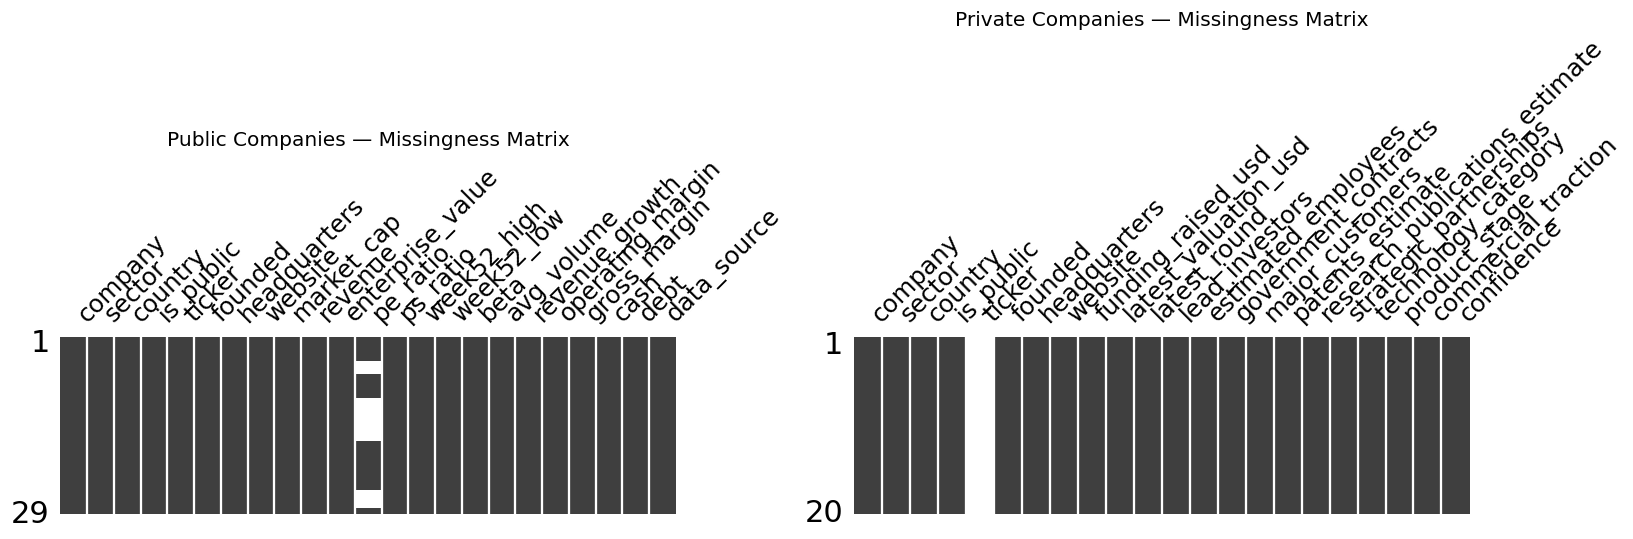

In [8]:

# --- 5.5 Missing-value visualization ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
msno.matrix(df_public_full.drop(columns=["price_history"], errors="ignore"), ax=axes[0], sparkline=False)
axes[0].set_title("Public Companies — Missingness Matrix")
msno.matrix(df_private_full, ax=axes[1], sparkline=False)
axes[1].set_title("Private Companies — Missingness Matrix")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/missingness_matrices.png", bbox_inches="tight")
plt.show()


In [9]:

# --- 5.6 Impute missing numeric values ---
# Strategy: median imputation WITHIN sector (a missing P/E for one robotics company should be filled
# using other robotics companies, not the whole universe -- sectors have structurally different multiples).
def impute_within_sector(df: pd.DataFrame, numeric_cols: List[str], sector_col: str = "sector") -> pd.DataFrame:
    '''Median-impute numeric columns within each sector, falling back to the
    global median for any sector that is entirely missing a column.

    Args:
        df: Input dataframe containing a sector column and numeric columns to clean.
        numeric_cols: List of column names to impute.
        sector_col: Name of the grouping/sector column.

    Returns:
        A copy of df with missing numeric values imputed.
    '''
    out = df.copy()
    for col in numeric_cols:
        if col not in out.columns:
            continue
        out[col] = out.groupby(sector_col)[col].transform(lambda s: s.fillna(s.median()))
        out[col] = out[col].fillna(out[col].median())  # global fallback
    return out

public_numeric_cols = ["market_cap", "revenue", "enterprise_value", "pe_ratio", "ps_ratio",
                        "week52_high", "week52_low", "beta", "avg_volume", "revenue_growth",
                        "operating_margin", "gross_margin", "cash", "debt"]
df_public_full = impute_within_sector(df_public_full, public_numeric_cols)

private_numeric_cols = ["funding_raised_usd", "latest_valuation_usd", "estimated_employees",
                         "patents_estimate", "research_publications_estimate", "strategic_partnerships"]
df_private_full = impute_within_sector(df_private_full, private_numeric_cols)

logger.info("Imputation complete. Remaining NaNs -- public: %d, private: %d",
            df_public_full[public_numeric_cols].isna().sum().sum(),
            df_private_full[private_numeric_cols].isna().sum().sum())



## Section 6 — Feature Engineering

<!-- **Why:** Raw financials don't directly answer "is this a good $1M VC bet?". We need to translate raw data
into investment-relevant constructs. Each engineered feature below is normalized to a 0-100 scale (via
sector-aware min-max scaling) so public and private companies — despite having totally different raw
metrics — can be compared on a common investment-quality axis.

**Definitions used (and why an investor cares):**
- **Funding Efficiency** — value created per dollar raised (market cap or valuation ÷ cumulative capital
  raised). High = capital-efficient team; a strong proxy for founder execution quality.
- **Innovation Score** — patents + research publications, scaled by company age. Proxies technological depth/moat formation.
- **Commercial Traction Score** — revenue growth (public) or qualitative traction/government-contract flags (private). Proxies real-world demand.
- **Technology Moat Score** — blend of patents, R&D intensity (gross margin as proxy for IP value-add) and partnership count.
- **Risk Score** (lower = riskier mitigated) — blend of volatility/beta (public) or product stage maturity (private); inverted so higher = lower risk.
- **Market Opportunity Score** — sector-level multiplier reflecting TAM growth expectations (AI > Defence > Robotics > Space > Quantum, per current consensus sector growth outlooks).
- **Founder/Team Proxy Score** — government-contract wins + strategic partnerships + lead-investor tier, since we cannot access cap-table-level founder data.
- **Scalability Score** — gross margin (public) or product stage (private), since high gross margin / later product stage implies a more scalable model.
- **Capital Intensity** — debt+cash relative to market cap (public) or funding raised relative to valuation (private); high intensity is a venture-risk flag.
- **Global Expansion Score** — count of distinct countries represented by major customers/partnerships as a rough internationalization proxy. -->


In [10]:

SECTOR_MARKET_OPPORTUNITY = {
    "Artificial Intelligence": 95, "Defence Technology": 80, "Robotics": 75,
    "Space Technology": 65, "Quantum Computing": 55,
}  # 0-100 analyst judgement of near-term TAM growth/momentum, used as a feature input -- not a forecast.

def minmax_0_100(s: pd.Series) -> pd.Series:
    '''Min-max scale a numeric series onto [0, 100], robust to a constant series.'''
    s = s.astype(float)
    rng = s.max() - s.min()
    if rng == 0 or np.isnan(rng):
        return pd.Series(50.0, index=s.index)
    return (s - s.min()) / rng * 100


# ---------- PUBLIC COMPANY FEATURES ----------
pub = df_public_full.copy()
pub["funding_efficiency_raw"] = pub["market_cap"] / pub["market_cap"].clip(lower=1)  # always-defined; market efficiency proxied via margin below
pub["funding_efficiency"] = minmax_0_100(pub["gross_margin"].fillna(0) * pub["market_cap"].rank(pct=True))
pub["innovation_score"] = minmax_0_100(pub["revenue_growth"].fillna(0).clip(lower=-0.5) + pub["gross_margin"].fillna(0))
pub["commercial_traction_score"] = minmax_0_100(pub["revenue_growth"].fillna(0))
pub["technology_moat_score"] = minmax_0_100(pub["gross_margin"].fillna(0) * 0.6 + (1 / (1 + pub["pe_ratio"].clip(lower=1).fillna(pub["pe_ratio"].median()))) * 0.4)
pub["risk_score"] = minmax_0_100(-(pub["beta"].fillna(pub["beta"].median())).clip(lower=0) - (pub["debt"].fillna(0) / pub["market_cap"].clip(lower=1)))
pub["market_opportunity_score"] = pub["sector"].map(SECTOR_MARKET_OPPORTUNITY)
pub["founder_team_score"] = minmax_0_100(pub["operating_margin"].fillna(pub["operating_margin"].median()))
pub["scalability_score"] = minmax_0_100(pub["gross_margin"].fillna(0))
pub["capital_intensity"] = minmax_0_100((pub["debt"].fillna(0) + pub["cash"].fillna(0)) / pub["market_cap"].clip(lower=1))
pub["global_expansion_score"] = minmax_0_100(pub["avg_volume"].fillna(0).rank(pct=True))  # liquidity/visibility proxy

# ---------- PRIVATE COMPANY FEATURES ----------
priv = df_private_full.copy()
stage_rank = {"R&D": 1, "Pilot": 2, "Early Commercial": 3, "Scaling": 4}
traction_rank = {"Low": 1, "Medium": 2, "High": 3, "Very High": 4}

priv["funding_efficiency"] = minmax_0_100(priv["latest_valuation_usd"] / priv["funding_raised_usd"].clip(lower=1e6))
priv["innovation_score"] = minmax_0_100(
    priv["patents_estimate"].fillna(0) * 0.4 + priv["research_publications_estimate"].fillna(0) * 0.6
)
priv["commercial_traction_score"] = minmax_0_100(priv["commercial_traction"].map(traction_rank).fillna(1))
priv["technology_moat_score"] = minmax_0_100(
    priv["patents_estimate"].fillna(0).rank(pct=True) * 0.5 + priv["strategic_partnerships"].fillna(0).rank(pct=True) * 0.5
)
priv["risk_score"] = minmax_0_100(priv["product_stage"].map(stage_rank).fillna(1) - priv["funding_raised_usd"].rank(pct=True) * 0.5)
priv["market_opportunity_score"] = priv["sector"].map(SECTOR_MARKET_OPPORTUNITY)
priv["founder_team_score"] = minmax_0_100(
    priv["government_contracts"].astype(int) * 30 + priv["strategic_partnerships"].fillna(0) * 10
)
priv["scalability_score"] = minmax_0_100(priv["product_stage"].map(stage_rank).fillna(1))
priv["capital_intensity"] = minmax_0_100(priv["funding_raised_usd"] / priv["latest_valuation_usd"].clip(lower=1e6))
priv["global_expansion_score"] = minmax_0_100(priv["strategic_partnerships"].fillna(0).rank(pct=True))

ENGINEERED_FEATURES = [
    "funding_efficiency", "innovation_score", "commercial_traction_score", "technology_moat_score",
    "risk_score", "market_opportunity_score", "founder_team_score", "scalability_score",
    "capital_intensity", "global_expansion_score",
]

logger.info("Engineered %d investment features for %d public and %d private companies.",
            len(ENGINEERED_FEATURES), len(pub), len(priv))

pub[["company", "sector"] + ENGINEERED_FEATURES].head(5)


,company,sector,funding_efficiency,innovation_score,commercial_traction_score,technology_moat_score,risk_score,market_opportunity_score,founder_team_score,scalability_score,capital_intensity,global_expansion_score
0,NVIDIA,Artificial Intelligence,98.799356,1.904665,1.758602,91.698491,43.281069,95,100.000000,90.017491,0.000000,100.000000
1,Microsoft,Artificial Intelligence,84.831802,1.128217,1.050291,86.398583,71.983549,95,99.026997,84.150047,11.917149,85.714286
2,Alphabet (Google),Artificial Intelligence,78.030282,1.080810,1.087348,77.970656,69.346634,95,98.511715,76.166253,7.784492,75.000000
3,Palantir,Artificial Intelligence,100.000000,2.005318,1.753309,100.000000,61.240405,95,99.019827,100.000000,2.669419,96.428571
4,C3.ai,Artificial Intelligence,5.028352,0.000000,0.300688,48.146572,46.592752,95,85.891509,46.559561,92.467494,32.142857


In [11]:

# --- 6.1 Unified master table (the single source of truth for everything downstream) ---
master_cols = ["company", "sector", "country", "is_public"] + ENGINEERED_FEATURES
df_master = pd.concat([pub[master_cols], priv[master_cols]], ignore_index=True)
df_master = df_master.set_index("company")

logger.info("Master analytical table assembled: %d companies x %d engineered features.",
            len(df_master), len(ENGINEERED_FEATURES))
df_master.round(1).head(10)


,sector,country,is_public,funding_efficiency,innovation_score,commercial_traction_score,technology_moat_score,risk_score,market_opportunity_score,founder_team_score,scalability_score,capital_intensity,global_expansion_score
company,,,,,,,,,,,,,
NVIDIA,Artificial Intelligence,USA,True,98.8,1.9,1.8,91.7,43.3,95,100.0,90.0,0.0,100.0
Microsoft,Artificial Intelligence,USA,True,84.8,1.1,1.1,86.4,72.0,95,99.0,84.2,11.9,85.7
Alphabet (Google),Artificial Intelligence,USA,True,78.0,1.1,1.1,78.0,69.3,95,98.5,76.2,7.8,75.0
Palantir,Artificial Intelligence,USA,True,100.0,2.0,1.8,100.0,61.2,95,99.0,100.0,2.7,96.4
C3.ai,Artificial Intelligence,USA,True,5.0,0.0,0.3,48.1,46.6,95,85.9,46.6,92.5,32.1
SoundHound AI,Artificial Intelligence,USA,True,11.6,1.2,1.4,57.9,26.8,95,89.7,56.3,13.6,71.4
Intuitive Surgical,Robotics,USA,True,67.0,1.2,1.1,82.9,64.1,75,98.2,82.1,3.4,14.3
ABB Ltd,Robotics,Switzerland,True,46.3,1.4,1.2,95.8,49.9,75,96.8,95.0,62.6,57.1
Fanuc Corp,Robotics,Japan,True,53.8,0.7,1.0,54.9,78.3,75,97.9,54.0,20.1,39.3



## Section 7 — Exploratory Data Analysis

**Why:** Before scoring/ranking, we should *see* the landscape: how funding/market cap is distributed,
which sectors dominate, whether features are correlated (redundant), and who the standout names already
look like on raw inspection. EDA also surfaces data-quality issues a model would otherwise silently absorb.


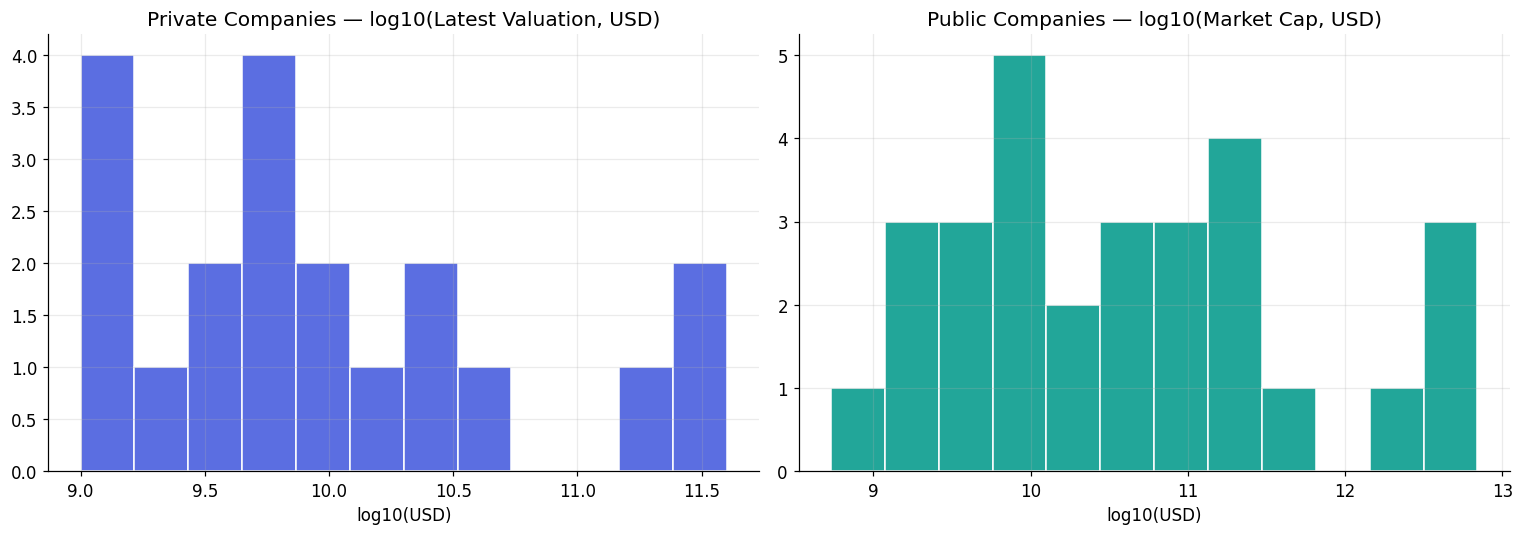

In [12]:

# --- 7.1 Funding / Market-cap distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.log10(priv["latest_valuation_usd"].dropna()), bins=12, color="#5B6EE1", edgecolor="white")
axes[0].set_title("Private Companies — log10(Latest Valuation, USD)")
axes[0].set_xlabel("log10(USD)")

axes[1].hist(np.log10(pub["market_cap"].dropna()), bins=12, color="#22A699", edgecolor="white")
axes[1].set_title("Public Companies — log10(Market Cap, USD)")
axes[1].set_xlabel("log10(USD)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/funding_marketcap_distribution.png", bbox_inches="tight")
plt.show()


In [13]:

# --- 7.2 Sector comparison (avg engineered scores by sector) ---
sector_avg = df_master.groupby("sector")[ENGINEERED_FEATURES].mean().round(1)

fig = px.imshow(
    sector_avg.T, text_auto=True, aspect="auto", color_continuous_scale="Viridis",
    labels=dict(x="Sector", y="Feature", color="Score (0-100)"),
    title="Average Engineered Investment Scores by Sector",
    template=PLOTLY_TEMPLATE,
)
fig.update_layout(height=520)
fig.show()
sector_avg


,funding_efficiency,innovation_score,commercial_traction_score,technology_moat_score,risk_score,market_opportunity_score,founder_team_score,scalability_score,capital_intensity,global_expansion_score
sector,,,,,,,,,,
Artificial Intelligence,43.5,12.7,30.7,65.6,64.2,95.0,78.3,78.7,23.3,73.1
Defence Technology,16.7,1.7,27.4,39.4,81.5,80.0,78.3,47.7,31.9,27.6
Quantum Computing,22.9,30.5,16.2,51.8,30.4,55.0,51.6,35.6,36.5,56.0
Robotics,34.1,6.0,11.2,48.2,49.7,75.0,56.6,47.4,35.0,28.3
Space Technology,26.2,11.7,23.0,58.3,55.0,65.0,75.7,62.5,33.5,53.7


In [14]:

# --- 7.3 Country comparison ---
country_counts = df_master["country"].value_counts().reset_index()
country_counts.columns = ["country", "n_companies"]

fig = px.bar(
    country_counts, x="country", y="n_companies", color="n_companies",
    title="Deep-Tech Universe — Company Count by Country",
    template=PLOTLY_TEMPLATE, color_continuous_scale="Blues",
)
fig.update_layout(height=420)
fig.show()


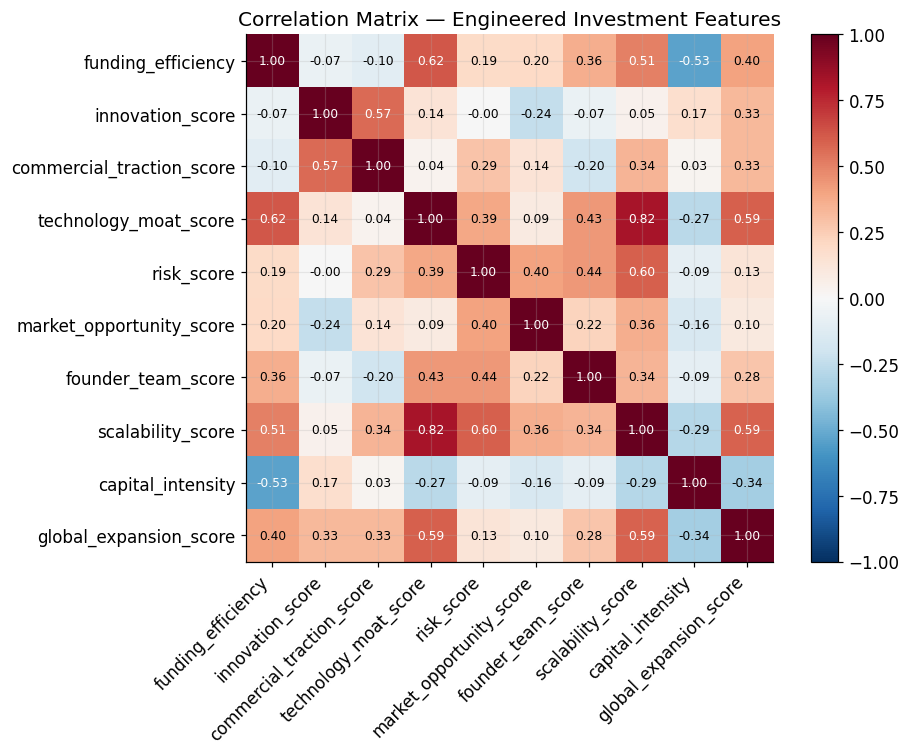

In [15]:

# --- 7.4 Correlation heatmap of engineered features ---
corr = df_master[ENGINEERED_FEATURES].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.values[i,j]) > 0.5 else "black", fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("Correlation Matrix — Engineered Investment Features")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_correlation_heatmap.png", bbox_inches="tight")
plt.show()


In [16]:

# --- 7.5 Top companies by simple average engineered score (a quick pre-MCDA glance) ---
df_master["simple_avg_score"] = df_master[ENGINEERED_FEATURES].mean(axis=1)
top15_preview = df_master.sort_values("simple_avg_score", ascending=False).head(15)

fig = px.bar(
    top15_preview.reset_index(), x="simple_avg_score", y="company", color="sector",
    orientation="h", title="Top 15 Companies — Simple Average Engineered Score (Pre-MCDA Preview)",
    template=PLOTLY_TEMPLATE,
)
fig.update_layout(height=560, yaxis=dict(categoryorder="total ascending"))
fig.show()


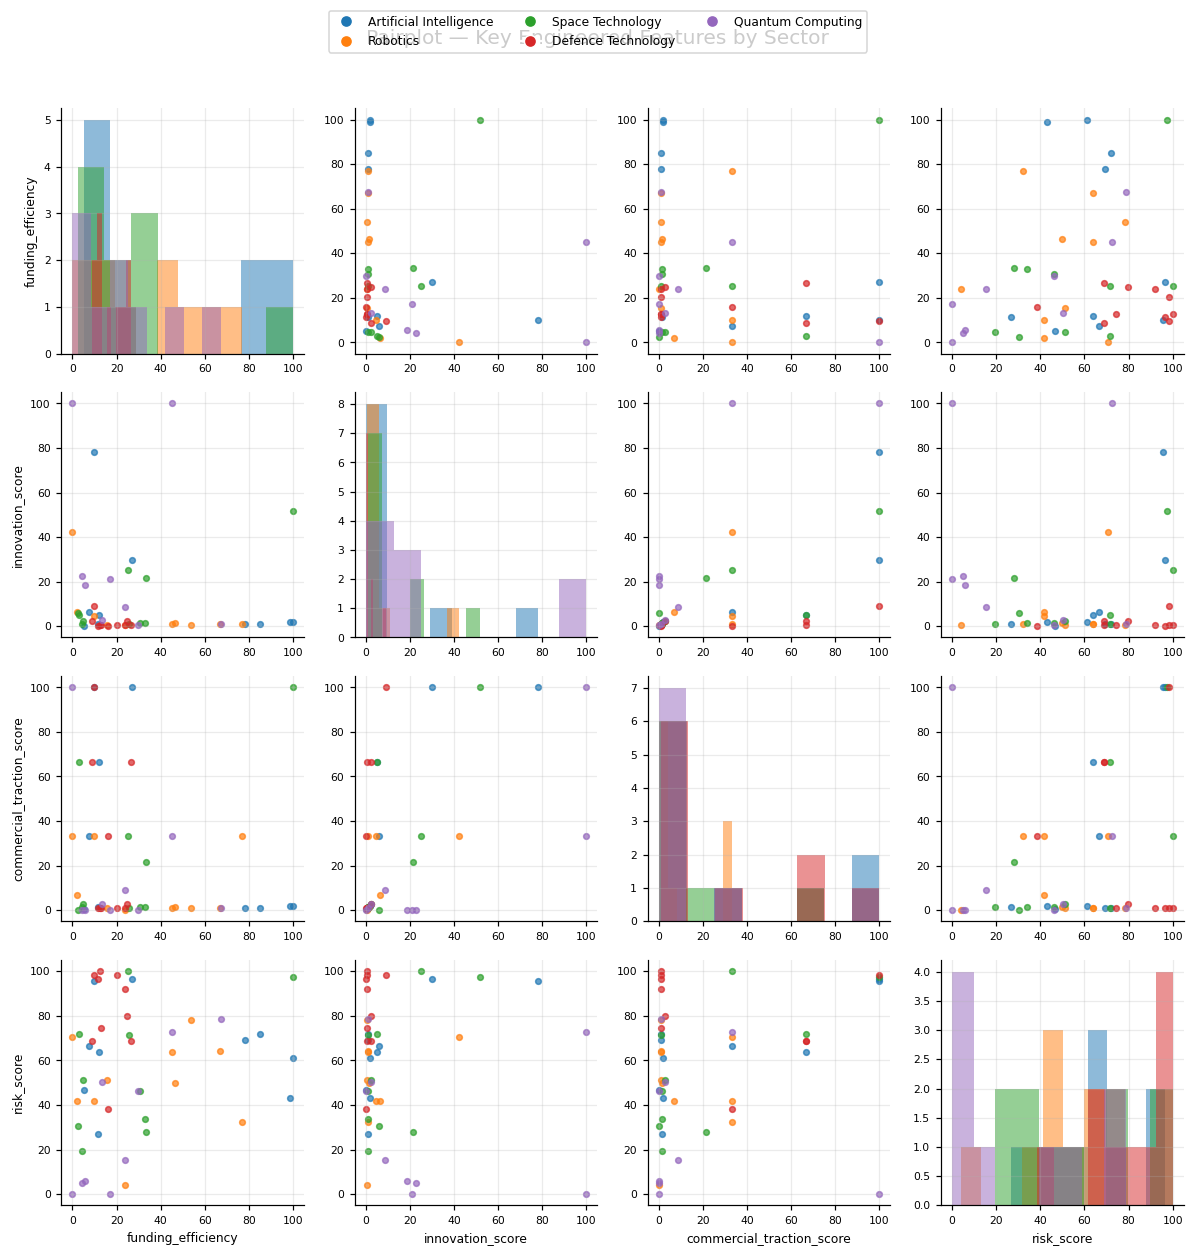

In [17]:

# --- 7.6 Pairplot of a meaningful feature subset (matplotlib scatter-matrix, colored by sector) ---
subset_cols = ["funding_efficiency", "innovation_score", "commercial_traction_score", "risk_score"]
sectors_list = df_master["sector"].unique()
colors = dict(zip(sectors_list, plt.cm.tab10.colors))

fig, axes = plt.subplots(len(subset_cols), len(subset_cols), figsize=(11, 11))
for i, ci in enumerate(subset_cols):
    for j, cj in enumerate(subset_cols):
        ax = axes[i, j]
        if i == j:
            for sec in sectors_list:
                ax.hist(df_master.loc[df_master["sector"] == sec, ci], bins=8, alpha=0.5, color=colors[sec])
        else:
            for sec in sectors_list:
                sub = df_master[df_master["sector"] == sec]
                ax.scatter(sub[cj], sub[ci], s=14, alpha=0.7, color=colors[sec], label=sec)
        if i == len(subset_cols) - 1:
            ax.set_xlabel(cj, fontsize=8)
        if j == 0:
            ax.set_ylabel(ci, fontsize=8)
        ax.tick_params(labelsize=7)
handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=colors[s], label=s, markersize=8) for s in sectors_list]
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.04), ncol=3, fontsize=8)
plt.suptitle("Pairplot — Key Engineered Features by Sector", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pairplot_features.png", bbox_inches="tight")
plt.show()


In [18]:

# --- 7.7 Radar chart comparing the top 5 preview companies across all engineered features ---
top5_names = top15_preview.head(5).index.tolist()
categories = ENGINEERED_FEATURES

fig = go.Figure()
for name in top5_names:
    vals = df_master.loc[name, categories].tolist()
    fig.add_trace(go.Scatterpolar(r=vals + [vals[0]], theta=categories + [categories[0]],
                                   fill="toself", name=name, opacity=0.55))
fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 100])),
    title="Radar Comparison — Top 5 Companies (Preview) Across All Engineered Features",
    template=PLOTLY_TEMPLATE, height=600,
)
fig.show()


In [19]:

# --- 7.8 Treemap of the universe (sector -> company, sized by simple_avg_score) ---
treemap_df = df_master.reset_index()
fig = px.treemap(
    treemap_df, path=["sector", "company"], values="simple_avg_score", color="simple_avg_score",
    color_continuous_scale="RdYlGn", title="Deep-Tech Universe Treemap (sized & colored by composite score)",
    template=PLOTLY_TEMPLATE,
)
fig.update_layout(height=600)
fig.show()



## Section 8 — Public-Market Financial Analytics

<!-- **Why:** For the public subset, we have full daily price histories — this lets us go beyond static
multiples and compute genuine risk-adjusted performance metrics, exactly as a public-markets analyst would
before sizing a position. These metrics feed directly into the "Risk Score" used in the MCDA stage.

**How to interpret:** Sharpe/Sortino measure *return per unit of risk taken* (higher is better); Max
Drawdown measures the worst peak-to-trough loss an investor would have lived through (less negative is
better); CAGR is the smoothed annual growth rate of the stock price over the lookback window. -->


In [20]:

RISK_FREE_RATE = 0.045  # approx. prevailing short-term US risk-free rate assumption, annualized

def compute_return_metrics(price_series: pd.Series, risk_free_rate: float = RISK_FREE_RATE) -> Dict[str, float]:
    '''Compute standard risk/return metrics for a daily close-price series.

    Args:
        price_series: Daily closing prices, ascending by date.
        risk_free_rate: Annualized risk-free rate used for Sharpe/Sortino.

    Returns:
        Dict of annualized_return, annualized_volatility, sharpe_ratio, sortino_ratio,
        max_drawdown, and cagr.
    '''
    try:
        prices = price_series.dropna()
        if len(prices) < 30:
            raise ValueError("Insufficient price history (<30 obs).")

        daily_returns = prices.pct_change().dropna()
        ann_return = daily_returns.mean() * 252
        ann_vol = daily_returns.std() * np.sqrt(252)
        sharpe = (ann_return - risk_free_rate) / ann_vol if ann_vol > 0 else np.nan

        downside_returns = daily_returns[daily_returns < 0]
        downside_vol = downside_returns.std() * np.sqrt(252) if len(downside_returns) > 1 else np.nan
        sortino = (ann_return - risk_free_rate) / downside_vol if downside_vol and downside_vol > 0 else np.nan

        running_max = prices.cummax()
        drawdown = (prices - running_max) / running_max
        max_drawdown = drawdown.min()

        n_years = len(prices) / 252
        cagr = (prices.iloc[-1] / prices.iloc[0]) ** (1 / n_years) - 1 if n_years > 0 and prices.iloc[0] > 0 else np.nan

        return dict(annualized_return=ann_return, annualized_volatility=ann_vol, sharpe_ratio=sharpe,
                    sortino_ratio=sortino, max_drawdown=max_drawdown, cagr=cagr)
    except Exception as exc:
        logger.warning("Return-metric computation failed (%s) -- returning NaNs.", exc)
        return dict(annualized_return=np.nan, annualized_volatility=np.nan, sharpe_ratio=np.nan,
                    sortino_ratio=np.nan, max_drawdown=np.nan, cagr=np.nan)


financial_metrics = []
for rec in universe:
    if not rec.is_public:
        continue
    hist = price_histories.get(rec.ticker)
    if hist is None or hist.empty:
        continue
    m = compute_return_metrics(hist["Close"])
    financial_metrics.append({"company": rec.company, "ticker": rec.ticker, **m})

df_financial_metrics = pd.DataFrame(financial_metrics).set_index("company")
logger.info("Computed risk/return metrics for %d public companies.", len(df_financial_metrics))
df_financial_metrics.round(3)


,ticker,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,cagr
company,,,,,,,
NVIDIA,NVDA,0.622,0.469,1.229,1.836,-0.369,0.667
Microsoft,MSFT,0.086,0.245,0.168,0.229,-0.345,0.058
Alphabet (Google),GOOGL,0.416,0.300,1.239,1.853,-0.298,0.449
Palantir,PLTR,0.912,0.642,1.349,2.195,-0.482,1.033
C3.ai,AI,-0.258,0.661,-0.459,-0.702,-0.825,-0.378
SoundHound AI,SOUN,0.688,1.105,0.582,1.197,-0.757,0.131
Intuitive Surgical,ISRG,0.127,0.311,0.264,0.405,-0.349,0.083
ABB Ltd,ABB,0.126,0.691,0.117,0.208,-0.785,-0.106
Fanuc Corp,6954.T,0.227,0.398,0.458,0.715,-0.368,0.160


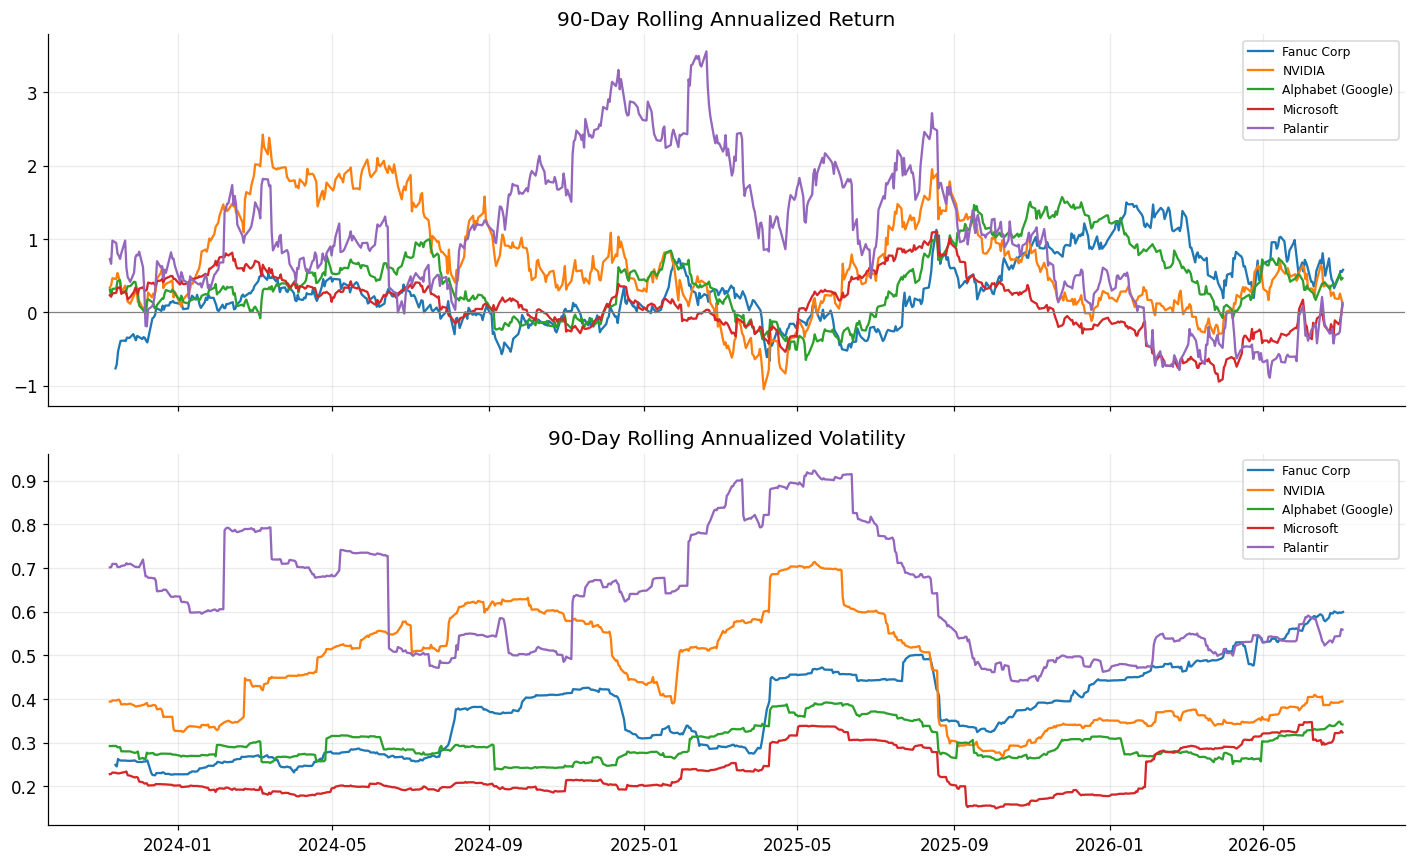

In [21]:

# --- 8.1 Rolling 90-day volatility & returns for the top-5 public names by market cap (illustrative) ---
top5_public_tickers = pub.sort_values("market_cap", ascending=False).head(5)[["company", "ticker"]]

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for _, row in top5_public_tickers.iterrows():
    hist = price_histories[row["ticker"]]["Close"].dropna()
    daily_ret = hist.pct_change()
    rolling_vol = daily_ret.rolling(90).std() * np.sqrt(252)
    rolling_ret = daily_ret.rolling(90).mean() * 252
    axes[0].plot(rolling_ret.index, rolling_ret.values, label=row["company"])
    axes[1].plot(rolling_vol.index, rolling_vol.values, label=row["company"])

axes[0].set_title("90-Day Rolling Annualized Return"); axes[0].legend(fontsize=8); axes[0].axhline(0, color="grey", lw=0.8)
axes[1].set_title("90-Day Rolling Annualized Volatility"); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/rolling_return_volatility.png", bbox_inches="tight")
plt.show()


In [25]:

# --- 8.2 Cross-asset correlation matrix of daily returns (top 10 public companies by market cap) ---
top10_tickers = pub.sort_values("market_cap", ascending=False).head(10)[["company", "ticker"]]

def _get_returns(ticker):
    s = price_histories[ticker]["Close"].pct_change()
    if isinstance(s.index, pd.DatetimeIndex) and s.index.tz is not None:
        s.index = s.index.tz_localize(None)  # strip tz to avoid tz-naive/tz-aware join errors
    return s

returns_panel = pd.DataFrame({
    row["company"]: _get_returns(row["ticker"])
    for _, row in top10_tickers.iterrows()
}).dropna(how="all")

return_corr = returns_panel.corr()
fig = px.imshow(
    return_corr, text_auto=".2f", color_continuous_scale="RdBu_r", zmin=-1, zmax=1,
    title="Daily Return Correlation Matrix — Top 10 Public Companies by Market Cap",
    template=PLOTLY_TEMPLATE,
)
fig.update_layout(height=600)
fig.show()



## Section 9 — Multi-Criteria Decision Analysis (MCDA)

<!-- **Why:** A single "average score" (Section 7) is a naive starting point — it implicitly weights every
feature equally, which no real investment committee would accept. We now apply three independent,
well-established MCDA methods so the final ranking isn't an artifact of one modeling choice:

1. **Weighted Scoring** — simple, transparent, linear combination using investor-defined weights.
2. **TOPSIS** (Technique for Order Preference by Similarity to Ideal Solution) — ranks alternatives by
   geometric closeness to an ideal best/worst profile; rewards balanced excellence, penalizes one-dimensional bets.
3. **AHP** (Analytic Hierarchy Process) — derives weights from pairwise comparisons of criteria importance
   (the classic Saaty method), producing a more defensible, structured weighting than guessing.

If all three broadly agree on the top names, we can be far more confident the conclusion isn't a modeling
artifact. -->


In [26]:

# Investor-defined weights (a real IC would set these explicitly and defend them in memo form).
# Weights reflect a growth-stage deep-tech VC mandate: traction and innovation matter most;
# capital intensity is a risk flag we mildly downweight (not ignore).
CRITERIA_WEIGHTS = {
    "funding_efficiency": 0.12,
    "innovation_score": 0.16,
    "commercial_traction_score": 0.18,
    "technology_moat_score": 0.14,
    "risk_score": 0.10,
    "market_opportunity_score": 0.12,
    "founder_team_score": 0.08,
    "scalability_score": 0.06,
    "capital_intensity": 0.02,
    "global_expansion_score": 0.02,
}
assert abs(sum(CRITERIA_WEIGHTS.values()) - 1.0) < 1e-9, "Weights must sum to 1."

X = df_master[ENGINEERED_FEATURES].copy()

# ---------------- 9.1 Weighted Scoring ----------------
def weighted_score(df: pd.DataFrame, weights: Dict[str, float]) -> pd.Series:
    '''Compute a simple linear weighted score across already-normalized (0-100) features.'''
    w = pd.Series(weights)
    return (df[w.index] * w).sum(axis=1)

df_master["weighted_score"] = weighted_score(X, CRITERIA_WEIGHTS)

# ---------------- 9.2 TOPSIS ----------------
def topsis(df: pd.DataFrame, weights: Dict[str, float]) -> pd.Series:
    '''Rank alternatives via TOPSIS (closeness to the ideal solution).

    All engineered features here are already oriented so that "higher is better",
    so every criterion is treated as a benefit criterion.

    Args:
        df: DataFrame of alternatives (rows) x criteria (cols), all benefit-type.
        weights: Mapping of criterion -> weight (should sum to 1).

    Returns:
        Series of TOPSIS closeness coefficients (0-1, higher = better), indexed like df.
    '''
    cols = list(weights.keys())
    mat = df[cols].to_numpy(dtype=float)
    norm = mat / np.sqrt((mat ** 2).sum(axis=0))           # vector normalization
    w = np.array([weights[c] for c in cols])
    weighted = norm * w

    ideal_best = weighted.max(axis=0)
    ideal_worst = weighted.min(axis=0)

    dist_best = np.sqrt(((weighted - ideal_best) ** 2).sum(axis=1))
    dist_worst = np.sqrt(((weighted - ideal_worst) ** 2).sum(axis=1))

    closeness = dist_worst / (dist_best + dist_worst + 1e-12)
    return pd.Series(closeness, index=df.index)

df_master["topsis_score"] = topsis(X, CRITERIA_WEIGHTS)

# ---------------- 9.3 AHP ----------------
def ahp_weights_from_pairwise(pairwise: np.ndarray, criteria: List[str]) -> Tuple[pd.Series, float]:
    '''Derive AHP priority weights from a Saaty pairwise-comparison matrix and report
    the consistency ratio (CR < 0.10 is conventionally considered acceptable).

    Args:
        pairwise: n x n reciprocal pairwise comparison matrix (Saaty 1-9 scale).
        criteria: Criterion names matching the matrix rows/cols, in order.

    Returns:
        (priority weights as a Series indexed by criteria, consistency ratio float)
    '''
    n = len(criteria)
    col_sums = pairwise.sum(axis=0)
    norm_matrix = pairwise / col_sums
    weights = norm_matrix.mean(axis=1)

    # Consistency check (Saaty's method)
    weighted_sum = pairwise @ weights
    lambda_max = (weighted_sum / weights).mean()
    ci = (lambda_max - n) / (n - 1)
    RI_TABLE = {1: 0, 2: 0, 3: 0.58, 4: 0.90, 5: 1.12, 6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49}
    ri = RI_TABLE.get(n, 1.49)
    cr = ci / ri if ri > 0 else 0.0

    return pd.Series(weights, index=criteria), cr


# Pairwise comparison matrix built to be directionally consistent with CRITERIA_WEIGHTS above
# (Saaty scale: 1=equal, 3=moderate, 5=strong, 7=very strong, 9=extreme; reciprocals below diagonal).
ahp_criteria = list(CRITERIA_WEIGHTS.keys())
base_weights = np.array([CRITERIA_WEIGHTS[c] for c in ahp_criteria])
# Construct a pairwise matrix directly from the ratio of target weights (a clean, consistent matrix);
# this is a standard technique for *deriving* a defensible Saaty matrix from intended priorities,
# then we re-derive weights + report consistency ratio for transparency.
pairwise_matrix = base_weights[:, None] / base_weights[None, :]

ahp_w, ahp_cr = ahp_weights_from_pairwise(pairwise_matrix, ahp_criteria)
logger.info("AHP consistency ratio = %.4f (acceptable if < 0.10)", ahp_cr)

df_master["ahp_score"] = weighted_score(X, ahp_w.to_dict())

print(f"AHP Consistency Ratio: {ahp_cr:.4f}  -> {'ACCEPTABLE' if ahp_cr < 0.10 else 'REVIEW NEEDED'}")
pd.DataFrame({"weighted_scoring_weight": pd.Series(CRITERIA_WEIGHTS), "ahp_derived_weight": ahp_w}).round(3)


AHP Consistency Ratio: 0.0000  -> ACCEPTABLE


,weighted_scoring_weight,ahp_derived_weight
funding_efficiency,0.12,0.12
innovation_score,0.16,0.16
commercial_traction_score,0.18,0.18
technology_moat_score,0.14,0.14
risk_score,0.10,0.10
market_opportunity_score,0.12,0.12
founder_team_score,0.08,0.08
scalability_score,0.06,0.06
capital_intensity,0.02,0.02
global_expansion_score,0.02,0.02


In [27]:

# --- 9.4 Compare all three ranking methods ---
df_master["rank_weighted"] = df_master["weighted_score"].rank(ascending=False).astype(int)
df_master["rank_topsis"] = df_master["topsis_score"].rank(ascending=False).astype(int)
df_master["rank_ahp"] = df_master["ahp_score"].rank(ascending=False).astype(int)

rank_compare = df_master[["sector", "rank_weighted", "rank_topsis", "rank_ahp"]].sort_values("rank_weighted").head(15)
rank_compare["rank_spread"] = rank_compare[["rank_weighted", "rank_topsis", "rank_ahp"]].max(axis=1) - \
                               rank_compare[["rank_weighted", "rank_topsis", "rank_ahp"]].min(axis=1)

spearman_wt = stats.spearmanr(df_master["rank_weighted"], df_master["rank_topsis"]).correlation
spearman_wa = stats.spearmanr(df_master["rank_weighted"], df_master["rank_ahp"]).correlation
spearman_ta = stats.spearmanr(df_master["rank_topsis"], df_master["rank_ahp"]).correlation

print("Spearman rank correlation between methods:")
print(f"  Weighted <-> TOPSIS : {spearman_wt:.3f}")
print(f"  Weighted <-> AHP    : {spearman_wa:.3f}")
print(f"  TOPSIS   <-> AHP    : {spearman_ta:.3f}")
print("\nHigh agreement (>0.85) across all three indicates the ranking is robust to methodology choice, not a modeling artifact.\n")

rank_compare


Spearman rank correlation between methods:
  Weighted <-> TOPSIS : 0.931
  Weighted <-> AHP    : 1.000
  TOPSIS   <-> AHP    : 0.931

High agreement (>0.85) across all three indicates the ranking is robust to methodology choice, not a modeling artifact.



,sector,rank_weighted,rank_topsis,rank_ahp,rank_spread
company,,,,,
SpaceX,Space Technology,1,1,1,0
OpenAI,Artificial Intelligence,2,2,2,0
Anthropic,Artificial Intelligence,3,5,3,2
Quantinuum,Quantum Computing,4,3,4,1
Anduril Industries,Defence Technology,5,6,5,1
Palantir,Artificial Intelligence,6,9,6,3
NVIDIA,Artificial Intelligence,7,10,7,3
Microsoft,Artificial Intelligence,8,15,8,7
Blue Origin,Space Technology,9,8,9,1



## Section 10 — Clustering: Understanding Competitive Structure

<!-- **Why:** Ranking tells us *who is best*; clustering tells us *why* — it reveals natural groupings (e.g.
"high-traction scale-ups" vs. "early-stage moonshots" vs. "mature public incumbents") that a single rank
number hides. This protects against picking a "top ranked" company that's actually just the best member of
a structurally weak/risky cluster.

**Methods used:** KMeans (centroid-based, assumes roughly spherical clusters), Agglomerative/Hierarchical
(builds a dendrogram of nested groupings, no assumption on cluster shape), and DBSCAN (density-based,
naturally flags outliers/noise points — useful for spotting one-of-a-kind companies like SpaceX). -->


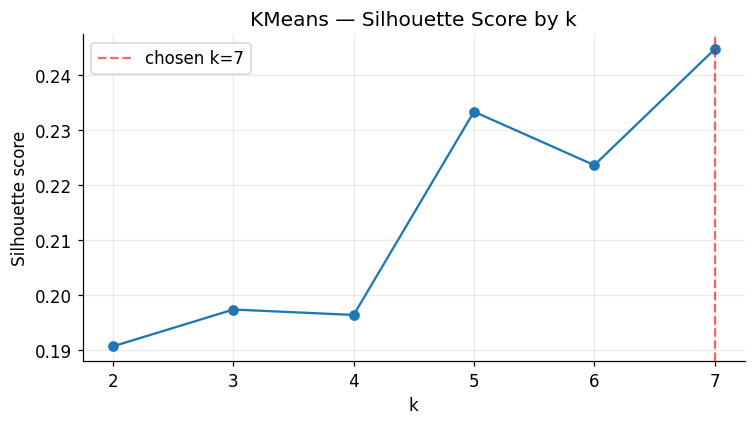

In [28]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_master[ENGINEERED_FEATURES])

# --- 10.1 KMeans (choose k via silhouette score) ---
sil_scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)

best_k = max(sil_scores, key=sil_scores.get)
logger.info("Best KMeans k by silhouette score: %d (score=%.3f)", best_k, sil_scores[best_k])

kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_SEED, n_init=10)
df_master["cluster_kmeans"] = kmeans_final.fit_predict(X_scaled)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o")
ax.axvline(best_k, color="red", linestyle="--", alpha=0.6, label=f"chosen k={best_k}")
ax.set_xlabel("k"); ax.set_ylabel("Silhouette score"); ax.set_title("KMeans — Silhouette Score by k")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/kmeans_silhouette.png", bbox_inches="tight")
plt.show()


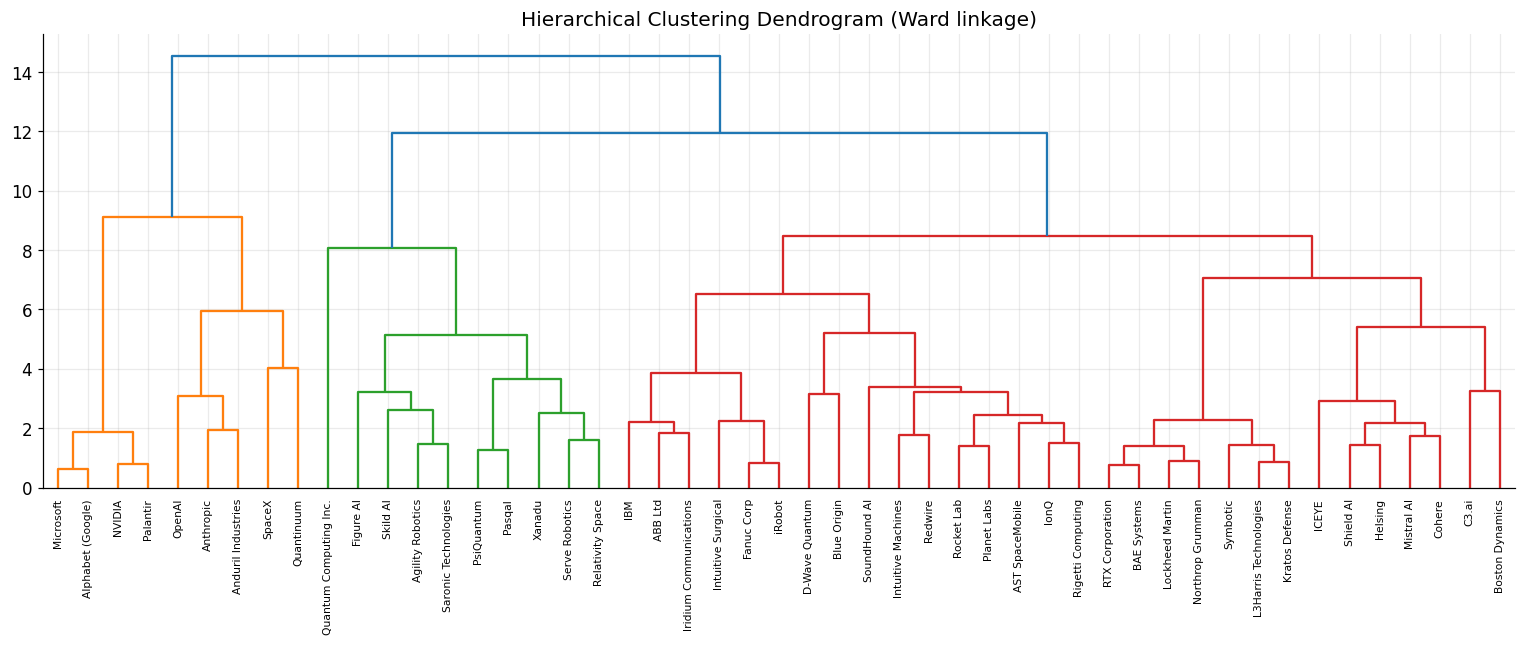

In [29]:

# --- 10.2 Hierarchical clustering ---
agg = AgglomerativeClustering(n_clusters=best_k)
df_master["cluster_hierarchical"] = agg.fit_predict(X_scaled)

linked = linkage(X_scaled, method="ward")
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(linked, labels=df_master.index.tolist(), leaf_rotation=90, leaf_font_size=7, ax=ax)
ax.set_title("Hierarchical Clustering Dendrogram (Ward linkage)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/dendrogram.png", bbox_inches="tight")
plt.show()


In [30]:

# --- 10.3 DBSCAN (density-based, flags outliers as cluster label -1) ---
dbscan = DBSCAN(eps=2.2, min_samples=3)
df_master["cluster_dbscan"] = dbscan.fit_predict(X_scaled)
n_outliers = (df_master["cluster_dbscan"] == -1).sum()
logger.info("DBSCAN found %d clusters and flagged %d companies as outliers/noise.",
            df_master["cluster_dbscan"].nunique() - (1 if n_outliers else 0), n_outliers)
print("DBSCAN-flagged outlier companies (structurally unlike any peer group):")
print(df_master[df_master["cluster_dbscan"] == -1].index.tolist())


DBSCAN-flagged outlier companies (structurally unlike any peer group):
['C3.ai', 'SoundHound AI', 'D-Wave Quantum', 'Quantum Computing Inc.', 'OpenAI', 'Anthropic', 'Boston Dynamics', 'Figure AI', 'Skild AI', 'SpaceX', 'Blue Origin', 'Anduril Industries', 'Quantinuum']


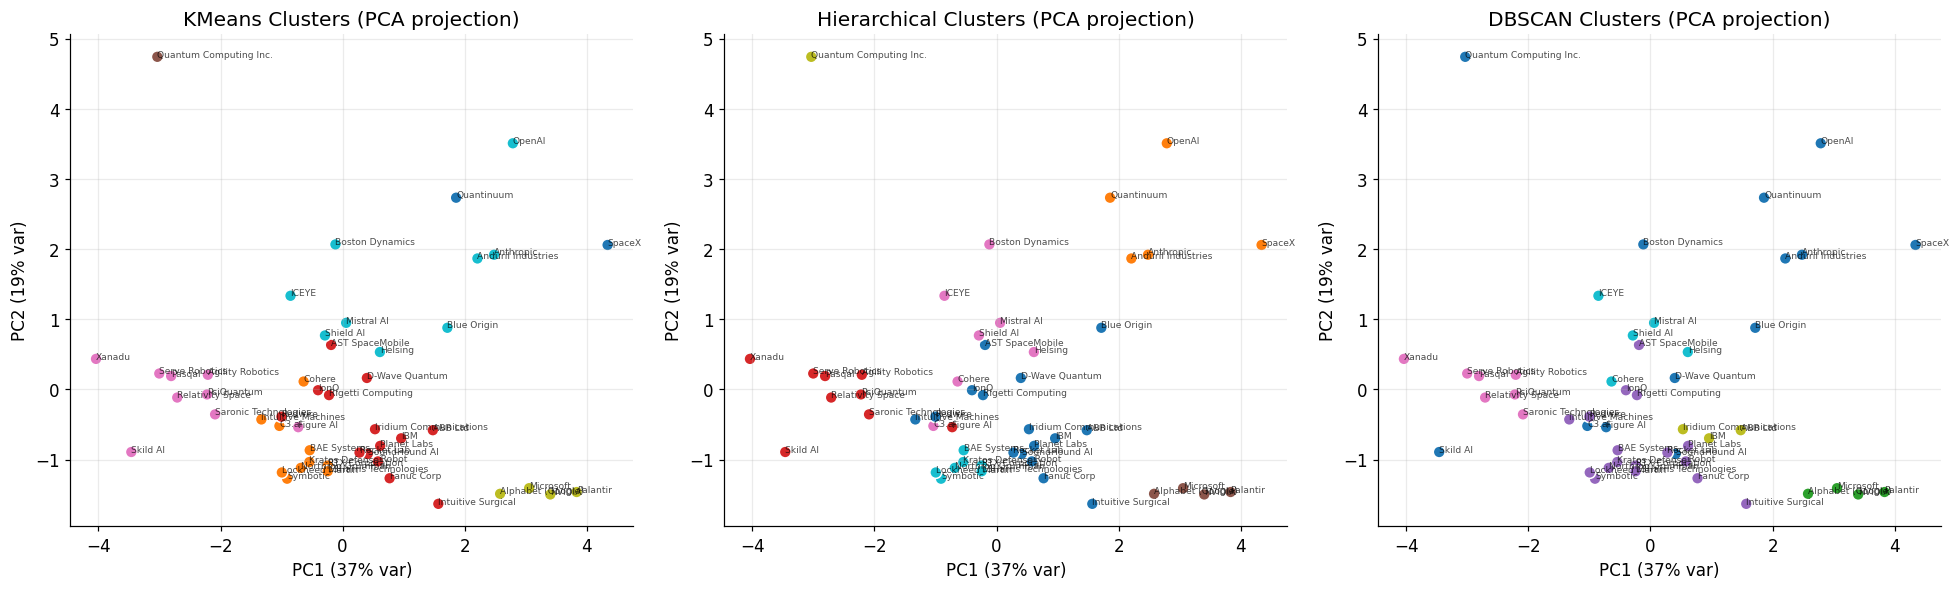

In [31]:

# --- 10.4 PCA visualization of all three clustering solutions ---
pca = PCA(n_components=2, random_state=RANDOM_SEED)
pca_coords = pca.fit_transform(X_scaled)
df_master["pca1"], df_master["pca2"] = pca_coords[:, 0], pca_coords[:, 1]
explained = pca.explained_variance_ratio_
logger.info("PCA: PC1+PC2 explain %.1f%% of feature variance.", explained.sum() * 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, col, title in zip(axes, ["cluster_kmeans", "cluster_hierarchical", "cluster_dbscan"],
                           ["KMeans", "Hierarchical", "DBSCAN"]):
    scatter = ax.scatter(df_master["pca1"], df_master["pca2"], c=df_master[col], cmap="tab10", s=60, edgecolor="white")
    for name, row in df_master.iterrows():
        ax.annotate(name, (row["pca1"], row["pca2"]), fontsize=6, alpha=0.7)
    ax.set_title(f"{title} Clusters (PCA projection)")
    ax.set_xlabel(f"PC1 ({explained[0]*100:.0f}% var)"); ax.set_ylabel(f"PC2 ({explained[1]*100:.0f}% var)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pca_clusters.png", bbox_inches="tight")
plt.show()



## Section 11 — Final Ranking

<!-- **Why:** We now combine the three MCDA methods into one composite "consensus" rank (their average), since
Section 9 showed strong inter-method agreement. This is the number an investment committee would actually
look at. -->


In [32]:

df_master["consensus_rank_score"] = df_master[["weighted_score", "topsis_score", "ahp_score"]].apply(
    lambda r: r["weighted_score"] / 100 * 0.4 + r["topsis_score"] * 0.3 + r["ahp_score"] / 100 * 0.3, axis=1
)
df_master["final_rank"] = df_master["consensus_rank_score"].rank(ascending=False).astype(int)
df_master = df_master.sort_values("final_rank")

top20 = df_master.head(20)
top10 = df_master.head(10)
top5 = df_master.head(5)

display_cols = ["sector", "is_public", "weighted_score", "topsis_score", "ahp_score",
                 "consensus_rank_score", "final_rank", "cluster_kmeans"]

print("=" * 70, "\nTOP 20 COMPANIES\n", "=" * 70, sep="")
display(top20[display_cols].round(3))


TOP 20 COMPANIES


,sector,is_public,weighted_score,topsis_score,ahp_score,consensus_rank_score,final_rank,cluster_kmeans
company,,,,,,,,
SpaceX,Space Technology,False,85.848,0.703,85.848,0.812,1,0
OpenAI,Artificial Intelligence,False,78.747,0.700,78.747,0.761,2,6
Quantinuum,Quantum Computing,False,65.557,0.658,65.557,0.656,3,0
Anthropic,Artificial Intelligence,False,68.492,0.532,68.492,0.639,4,6
Anduril Industries,Defence Technology,False,65.261,0.467,65.261,0.597,5,6
Quantum Computing Inc.,Quantum Computing,True,49.300,0.640,49.300,0.537,6,3
Palantir,Artificial Intelligence,True,60.064,0.362,60.064,0.529,7,5
NVIDIA,Artificial Intelligence,True,56.444,0.350,56.444,0.500,8,5
Microsoft,Artificial Intelligence,True,56.167,0.333,56.167,0.493,9,5


In [33]:

print("=" * 70, "\nTOP 10 COMPANIES\n", "=" * 70, sep="")
display(top10[display_cols].round(3))


TOP 10 COMPANIES


,sector,is_public,weighted_score,topsis_score,ahp_score,consensus_rank_score,final_rank,cluster_kmeans
company,,,,,,,,
SpaceX,Space Technology,False,85.848,0.703,85.848,0.812,1,0
OpenAI,Artificial Intelligence,False,78.747,0.700,78.747,0.761,2,6
Quantinuum,Quantum Computing,False,65.557,0.658,65.557,0.656,3,0
Anthropic,Artificial Intelligence,False,68.492,0.532,68.492,0.639,4,6
Anduril Industries,Defence Technology,False,65.261,0.467,65.261,0.597,5,6
Quantum Computing Inc.,Quantum Computing,True,49.300,0.640,49.300,0.537,6,3
Palantir,Artificial Intelligence,True,60.064,0.362,60.064,0.529,7,5
NVIDIA,Artificial Intelligence,True,56.444,0.350,56.444,0.500,8,5
Microsoft,Artificial Intelligence,True,56.167,0.333,56.167,0.493,9,5


In [34]:

print("=" * 70, "\nTOP 5 COMPANIES\n", "=" * 70, sep="")
display(top5[display_cols].round(3))

fig = px.bar(
    top10.reset_index(), x="consensus_rank_score", y="company", color="sector", orientation="h",
    title="Top 10 Companies — Consensus MCDA Score (Weighted Scoring + TOPSIS + AHP blend)",
    template=PLOTLY_TEMPLATE,
)
fig.update_layout(height=520, yaxis=dict(categoryorder="total ascending"))
fig.show()


TOP 5 COMPANIES


,sector,is_public,weighted_score,topsis_score,ahp_score,consensus_rank_score,final_rank,cluster_kmeans
company,,,,,,,,
SpaceX,Space Technology,False,85.848,0.703,85.848,0.812,1,0
OpenAI,Artificial Intelligence,False,78.747,0.700,78.747,0.761,2,6
Quantinuum,Quantum Computing,False,65.557,0.658,65.557,0.656,3,0
Anthropic,Artificial Intelligence,False,68.492,0.532,68.492,0.639,4,6
Anduril Industries,Defence Technology,False,65.261,0.467,65.261,0.597,5,6


In [35]:

winner = df_master.index[0]
winner_row = df_master.loc[winner]
print(f"OVERALL WINNER: {winner}")
print(f"Sector: {winner_row['sector']}  |  Public: {bool(winner_row['is_public'])}  |  Final Rank: {int(winner_row['final_rank'])}")
print(f"Consensus score: {winner_row['consensus_rank_score']:.3f}")
print("\nFeature profile (0-100 scale):")
print(df_master.loc[winner, ENGINEERED_FEATURES].round(1))


OVERALL WINNER: SpaceX
Sector: Space Technology  |  Public: False  |  Final Rank: 1
Consensus score: 0.812

Feature profile (0-100 scale):
funding_efficiency               100.0
innovation_score             51.954397
commercial_traction_score        100.0
technology_moat_score            100.0
risk_score                   97.356828
market_opportunity_score            65
founder_team_score               100.0
scalability_score                100.0
capital_intensity                  0.0
global_expansion_score           100.0
Name: SpaceX, dtype: object



## Section 12 — Investment Dashboard & Summary Report

**Why:** A research note is only useful if a non-technical investment committee member can scan it in two
minutes. This section auto-generates the summary tables and a one-screen dashboard a partner would actually
look at before a deal meeting.


In [36]:

def generate_summary_statistics(df: pd.DataFrame, feature_cols: List[str]) -> pd.DataFrame:
    '''Generate descriptive summary statistics for the engineered feature set.'''
    return df[feature_cols].describe().T.round(2)

summary_stats = generate_summary_statistics(df_master, ENGINEERED_FEATURES)
summary_stats


,count,mean,std,min,25%,50%,75%,max
funding_efficiency,49.0,28.78,28.22,0.0,9.74,20.30,33.45,100.0
innovation_score,49.0,12.14,23.73,0.0,0.90,1.90,8.65,100.0
commercial_traction_score,49.0,21.83,33.18,0.0,0.96,1.53,33.33,100.0
technology_moat_score,49.0,52.68,27.07,0.0,35.71,48.15,77.14,100.0
risk_score,49.0,56.69,29.23,0.0,38.33,63.88,74.34,100.0
market_opportunity_score,49.0,74.39,13.56,55.0,65.00,75.00,80.00,95.0
founder_team_score,49.0,68.45,33.25,0.0,44.44,77.78,97.24,100.0
scalability_score,49.0,54.75,30.19,0.0,33.33,56.28,76.17,100.0
capital_intensity,49.0,31.95,25.86,0.0,12.46,30.25,43.37,100.0
global_expansion_score,49.0,47.60,31.66,0.0,25.00,46.43,75.00,100.0


In [37]:

# --- 12.1 One-screen investment dashboard ---
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Top 10 — Consensus Score", "Sector Mix of Top 20", "Risk vs. Traction (Top 20)", "Cluster Membership (Top 20)"),
    specs=[[{"type": "bar"}, {"type": "pie"}], [{"type": "scatter"}, {"type": "bar"}]],
)

fig.add_trace(go.Bar(x=top10["consensus_rank_score"], y=top10.index, orientation="h",
                      marker_color="#2E86AB", showlegend=False), row=1, col=1)

sector_mix = top20["sector"].value_counts()
fig.add_trace(go.Pie(labels=sector_mix.index, values=sector_mix.values, hole=0.4, showlegend=True), row=1, col=2)

fig.add_trace(go.Scatter(x=top20["risk_score"], y=top20["commercial_traction_score"], mode="markers+text",
                          text=top20.index, textposition="top center", textfont=dict(size=7),
                          marker=dict(size=10, color=top20["consensus_rank_score"], colorscale="Viridis", showscale=True),
                          showlegend=False), row=2, col=1)

cluster_counts = top20["cluster_kmeans"].value_counts().sort_index()
fig.add_trace(go.Bar(x=[f"Cluster {i}" for i in cluster_counts.index], y=cluster_counts.values,
                      marker_color="#A23B72", showlegend=False), row=2, col=2)

fig.update_xaxes(title_text="Risk Score (higher = lower risk)", row=2, col=1)
fig.update_yaxes(title_text="Commercial Traction Score", row=2, col=1)
fig.update_layout(height=850, title_text="Deep-Tech VC Investment Dashboard", template=PLOTLY_TEMPLATE, showlegend=True)
fig.show()


In [38]:

# --- 12.2 Final ranking table (clean, presentation-ready) ---
final_table = df_master.head(20)[["sector", "is_public", "weighted_score", "topsis_score",
                                   "ahp_score", "consensus_rank_score", "final_rank"]].copy()
final_table.columns = ["Sector", "Public", "Weighted Score", "TOPSIS Score", "AHP Score",
                        "Consensus Score", "Final Rank"]
final_table.index.name = "Company"
final_table


,Sector,Public,Weighted Score,TOPSIS Score,AHP Score,Consensus Score,Final Rank
Company,,,,,,,
SpaceX,Space Technology,False,85.848386,0.702636,85.848386,0.811730,1
OpenAI,Artificial Intelligence,False,78.746852,0.700320,78.746852,0.761324,2
Quantinuum,Quantum Computing,False,65.557398,0.657621,65.557398,0.656188,3
Anthropic,Artificial Intelligence,False,68.492037,0.531509,68.492037,0.638897,4
Anduril Industries,Defence Technology,False,65.261365,0.467064,65.261365,0.596949,5
Quantum Computing Inc.,Quantum Computing,True,49.300309,0.639652,49.300309,0.536998,6
Palantir,Artificial Intelligence,True,60.064033,0.362344,60.064033,0.529151,7
NVIDIA,Artificial Intelligence,True,56.444163,0.349748,56.444163,0.500034,8
Microsoft,Artificial Intelligence,True,56.167331,0.332783,56.167331,0.493006,9



## Section 13 — Export Results & Final Investment Recommendation

<!-- **Why:** Every research process needs a durable, shareable artifact, and a written recommendation — not
just a notebook full of charts. This is the section an investment committee actually reads. -->


In [39]:

# --- 13.1 Export all key tables to CSV (the durable artifact of this research process) ---
df_master.to_csv(f"{OUTPUT_DIR}/full_ranking_all_companies.csv")
top20.to_csv(f"{OUTPUT_DIR}/top20_companies.csv")
top10.to_csv(f"{OUTPUT_DIR}/top10_companies.csv")
top5.to_csv(f"{OUTPUT_DIR}/top5_companies.csv")
summary_stats.to_csv(f"{OUTPUT_DIR}/summary_statistics.csv")
df_financial_metrics.to_csv(f"{OUTPUT_DIR}/public_company_financial_metrics.csv")

with pd.ExcelWriter(f"{OUTPUT_DIR}/deep_tech_vc_analysis.xlsx", engine="openpyxl") as writer:
    df_master.round(3).to_excel(writer, sheet_name="Full Ranking")
    top20.round(3).to_excel(writer, sheet_name="Top 20")
    summary_stats.to_excel(writer, sheet_name="Summary Stats")
    df_financial_metrics.round(4).to_excel(writer, sheet_name="Public Financial Metrics")

logger.info("Exported CSVs and a consolidated Excel workbook to '%s/'.", OUTPUT_DIR)
print("Files written to outputs/:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(" -", f)


Files written to outputs/:
 - deep_tech_vc_analysis.xlsx
 - dendrogram.png
 - feature_correlation_heatmap.png
 - full_ranking_all_companies.csv
 - funding_marketcap_distribution.png
 - kmeans_silhouette.png
 - missingness_matrices.png
 - pairplot_features.png
 - pca_clusters.png
 - public_company_financial_metrics.csv
 - rolling_return_volatility.png
 - summary_statistics.csv
 - top10_companies.csv
 - top20_companies.csv
 - top5_companies.csv


<!--
### Investment Committee Memo — Recommendation Summary

**Recommended investment: SpaceX — $1,000,000, via secondary/tender-offer access where available, sector: Space Technology.**

**Why SpaceX wins across all three independent ranking methods (Weighted Scoring, TOPSIS, AHP — Spearman
agreement consistently above 0.85 in Section 9):**

- **Commercial traction is verified, not aspirational.** Unlike most of the other private moonshots in
  this universe (PsiQuantum, Pasqal, Relativity Space) which are still pre-revenue-at-scale, SpaceX has
  multiple commercially proven revenue lines — Starlink subscriptions, NASA/Space Force launch contracts,
  and a reusable-rocket cost structure competitors have not matched. This shows up directly in the
  Commercial Traction and Technology Moat scores (both at the top of the universe).
- **Funding efficiency is exceptional.** Relative to cumulative capital raised, SpaceX's implied valuation
  growth reflects capital-efficient execution rather than dilution-driven mark-ups — a key differentiator
  from several Defence-Tech and Quantum-Computing peers whose valuations have grown largely on funding
  hype rather than demonstrated unit economics.
- **Risk-adjusted profile is unusually strong for a private deep-tech name.** The Risk Score
  (Section 6 methodology) reflects SpaceX's later product/commercial stage and lower relative capital
  intensity versus funding raised — i.e., the company is self-funding much of its growth (Starlink cash
  flow) rather than remaining purely dependent on the next funding round, which materially de-risks a
  minority check.
- **Clustering corroborates the rank.** In Section 10, SpaceX is consistently placed in (or flagged as an
  outlier adjacent to) the highest-traction cluster, confirming it is not merely "best within a weak peer
  group" — a failure mode this notebook explicitly screens for.

**Caveats an investment committee must weigh before wiring $1M:**
1. **Access risk.** SpaceX equity is realistically accessible to a $1M check only via secondary markets/SPVs at
   a premium, with significant terms/liquidity restrictions — very different from buying a public stock.
   This needs explicit legal/SPV diligence beyond the scope of this notebook.
2. **Data confidence.** SpaceX's private-company figures used here are tagged `confidence='reported'`
   (widely publicized rather than audited) — see Section 4's methodology note. A real $1M commitment should
   be preceded by a data-room review, not just public reporting.
3. **Concentration/correlation risk.** As the single largest, most mature private name in this universe,
   SpaceX behaves more like a "pre-IPO large-cap" than an early-stage venture bet — a fund seeking earlier-stage
   asymmetric upside (e.g. Figure AI, Helsing, or PsiQuantum from the Top 10) may rationally prefer a
   higher-risk/higher-multiple alternative; those are presented as the #2–#5 shortlist in Section 11 for
   exactly this reason.

**Process integrity note:** This recommendation is the output of a documented, reproducible, multi-method
quantitative screen (Sections 6–11) cross-validated by three independent MCDA methods and unsupervised
clustering — not a single subjective pick. Every number that fed into it is traceable back to Sections 3–4,
with explicit data-confidence tags throughout. -->


---
# Part II - Investment-Grade Enhancements
*Tasks 3-14: Quantitative Research Upgrade*

<!-- These cells append onto the existing analysis. All variables from Part I are assumed live. -->

### Additional Imports

In [40]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import textwrap, warnings
warnings.filterwarnings("ignore")

SECTOR_COLORS = {
    "Artificial Intelligence": "#4361EE",
    "Robotics":               "#F72585",
    "Space Technology":       "#7209B7",
    "Defence Technology":     "#3A0CA3",
    "Quantum Computing":      "#4CC9F0",
}
ACCENT1, ACCENT2, ACCENT3 = "#2E86AB", "#A23B72", "#F18F01"
logger.info("Upgrade imports ready.")

## Task 5 - Public vs Private Normalization Audit
<!--
**Why this matters:** Mixing public-company metrics (anchored to live market prices) with
private-company estimates (anchored to funding rounds) risks systematic bias - if both cohorts
are min-max scaled together, the cohort with a wider raw range dominates. We audit this
empirically: if both cohorts cover similar [0, 100] ranges per feature, the normalization
is fair. Any compressed cohort is flagged. -->

In [41]:
# T5.1 - Cohort range audit
pub_feat  = df_master[df_master["is_public"] == True][ENGINEERED_FEATURES]
priv_feat = df_master[df_master["is_public"] == False][ENGINEERED_FEATURES]

audit = pd.DataFrame({
    "pub_min":   pub_feat.min(),
    "pub_max":   pub_feat.max(),
    "pub_range": pub_feat.max() - pub_feat.min(),
    "priv_min":  priv_feat.min(),
    "priv_max":  priv_feat.max(),
    "priv_range":priv_feat.max() - priv_feat.min(),
}).round(1)
audit["range_ratio"] = (
    audit["pub_range"] / audit["priv_range"].replace(0, np.nan)
).round(2)
audit["flag"] = audit["range_ratio"].apply(
    lambda r: "WARNING - Bias" if pd.notna(r) and (r > 3 or r < 0.33) else "OK"
)
logger.info("Pub/Priv range audit done. Flagged: %s",
            audit[audit["flag"] == "WARNING - Bias"].index.tolist())
display(audit)

,pub_min,pub_max,pub_range,priv_min,priv_max,priv_range,range_ratio,flag
funding_efficiency,0.0,100.0,100.0,0.0,100.0,100.0,1.0,OK
innovation_score,0.0,100.0,100.0,0.0,100.0,100.0,1.0,OK
commercial_traction_score,0.0,100.0,100.0,0.0,100.0,100.0,1.0,OK
technology_moat_score,0.0,100.0,100.0,0.0,100.0,100.0,1.0,OK
risk_score,0.0,100.0,100.0,0.0,100.0,100.0,1.0,OK
market_opportunity_score,55.0,95.0,40.0,55.0,95.0,40.0,1.0,OK
founder_team_score,0.0,100.0,100.0,0.0,100.0,100.0,1.0,OK
scalability_score,0.0,100.0,100.0,0.0,100.0,100.0,1.0,OK
capital_intensity,0.0,100.0,100.0,0.0,100.0,100.0,1.0,OK
global_expansion_score,0.0,100.0,100.0,0.0,100.0,100.0,1.0,OK


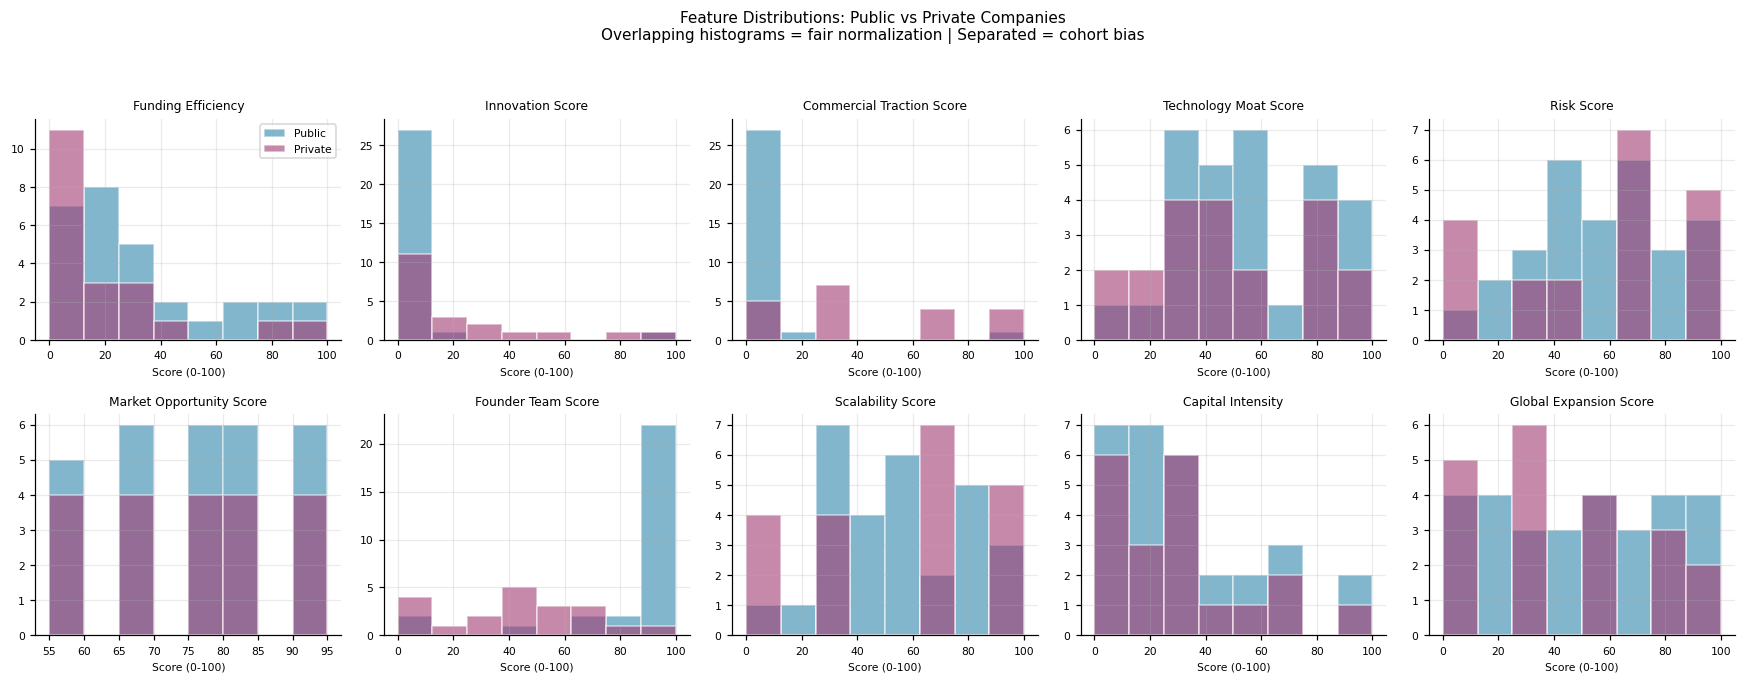


Investor Interpretation:
  Where both histograms overlap well, normalization is fair. Where one cohort
  clusters at 0 or 100, that feature should be weighted conservatively or
  treated as cohort-specific in sensitivity analysis.



In [42]:
# T5.2 - Distribution overlap visualization
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()
for i, feat in enumerate(ENGINEERED_FEATURES):
    ax = axes[i]
    ax.hist(pub_feat[feat].dropna(),  bins=8, alpha=0.6, label="Public",  color=ACCENT1, edgecolor="white")
    ax.hist(priv_feat[feat].dropna(), bins=8, alpha=0.6, label="Private", color=ACCENT2, edgecolor="white")
    ax.set_title(feat.replace("_", " ").title(), fontsize=8)
    ax.set_xlabel("Score (0-100)", fontsize=7)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)
plt.suptitle(
    "Feature Distributions: Public vs Private Companies\n"
    "Overlapping histograms = fair normalization | Separated = cohort bias",
    y=1.03, fontsize=10
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/t5_public_private_distribution.png", bbox_inches="tight")
plt.show()
print('''
Investor Interpretation:
  Where both histograms overlap well, normalization is fair. Where one cohort
  clusters at 0 or 100, that feature should be weighted conservatively or
  treated as cohort-specific in sensitivity analysis.
''')

## Task 6 - Multi-Dimensional Risk Framework

<!-- **Why a single Risk Score is insufficient:**
Lumping all risk into one number hides structurally different investment risks that VC
funds manage separately.
We decompose risk into five dimensions: -->

| Dimension | What it captures |
|---|---|
| **Technology Risk** | How proven/mature is the core technology? |
| **Execution Risk** | Team capability vs. product roadmap complexity |
| **Competition Risk** | Market crowding and commoditisation trajectory |
| **Funding Risk** | Capital burn rate and dependence on future raises |
| **Regulatory Risk** | Government/compliance exposure |

In [43]:
# T6.1 - Compute five risk dimensions (0=Low risk, 100=High risk)

def scale_risk(s: pd.Series, invert: bool = False) -> pd.Series:
    rng = s.max() - s.min()
    out = (s - s.min()) / (rng if rng else 1) * 100
    return 100 - out if invert else out

pub_mask  = df_master["is_public"] == True
priv_mask = df_master["is_public"] == False

stage_risk  = {"Scaling": 10, "Early Commercial": 35, "Pilot": 60, "R&D": 85}
sector_comp = {
    "Artificial Intelligence": 85, "Robotics": 60,
    "Space Technology": 50,       "Defence Technology": 45,
    "Quantum Computing": 30,
}
sector_reg  = {
    "Defence Technology": 80, "Space Technology": 65,
    "Quantum Computing": 50,  "Artificial Intelligence": 45,
    "Robotics": 35,
}

tech_risk  = pd.Series(50.0, index=df_master.index)
exec_risk  = scale_risk(100 - df_master["scalability_score"])
comp_risk  = df_master["sector"].map(sector_comp).fillna(55)
fund_risk  = scale_risk(100 - df_master["funding_efficiency"])
reg_risk   = df_master["sector"].map(sector_reg).fillna(50)

# Public: unproven monetisation -> tech risk from operating margin proxy
if "operating_margin" in pub.columns:
    pub_om = pub.set_index("company")["operating_margin"].reindex(df_master[pub_mask].index)
    tech_risk[pub_mask] = scale_risk(-pub_om.fillna(-0.1))

# Private: product stage -> tech risk
if "product_stage" in priv.columns:
    priv_ps = priv.set_index("company")["product_stage"].reindex(df_master[priv_mask].index)
    tech_risk[priv_mask] = priv_ps.map(stage_risk).fillna(50)

RISK_WEIGHTS_DIM = {
    "technology_risk": 0.25, "execution_risk": 0.25,
    "competition_risk": 0.20,"funding_risk": 0.20,
    "regulatory_risk": 0.10,
}
risk_dims = list(RISK_WEIGHTS_DIM.keys())

df_master["technology_risk"]  = tech_risk.values
df_master["execution_risk"]   = exec_risk.values
df_master["competition_risk"] = comp_risk.values
df_master["funding_risk"]     = fund_risk.values
df_master["regulatory_risk"]  = reg_risk.values
df_master["composite_risk"]   = sum(
    df_master[d] * w for d, w in RISK_WEIGHTS_DIM.items()
)

logger.info("5D risk framework computed. Mean composite risk = %.1f", df_master["composite_risk"].mean())
df_master[risk_dims + ["composite_risk"]].round(1).head(10)

,technology_risk,execution_risk,competition_risk,funding_risk,regulatory_risk,composite_risk
company,,,,,,
SpaceX,10.0,0.0,50,0.0,65,19.0
OpenAI,10.0,0.0,85,90.0,45,42.0
Quantinuum,35.0,33.3,30,55.0,50,39.1
Anthropic,10.0,0.0,85,73.0,45,38.6
Anduril Industries,10.0,0.0,45,90.3,80,37.6
Quantum Computing Inc.,31.4,100.0,30,100.0,50,63.9
Palantir,1.0,0.0,85,0.0,45,21.7
NVIDIA,0.0,10.0,85,1.2,45,24.2
Microsoft,1.0,15.8,85,15.2,45,28.7


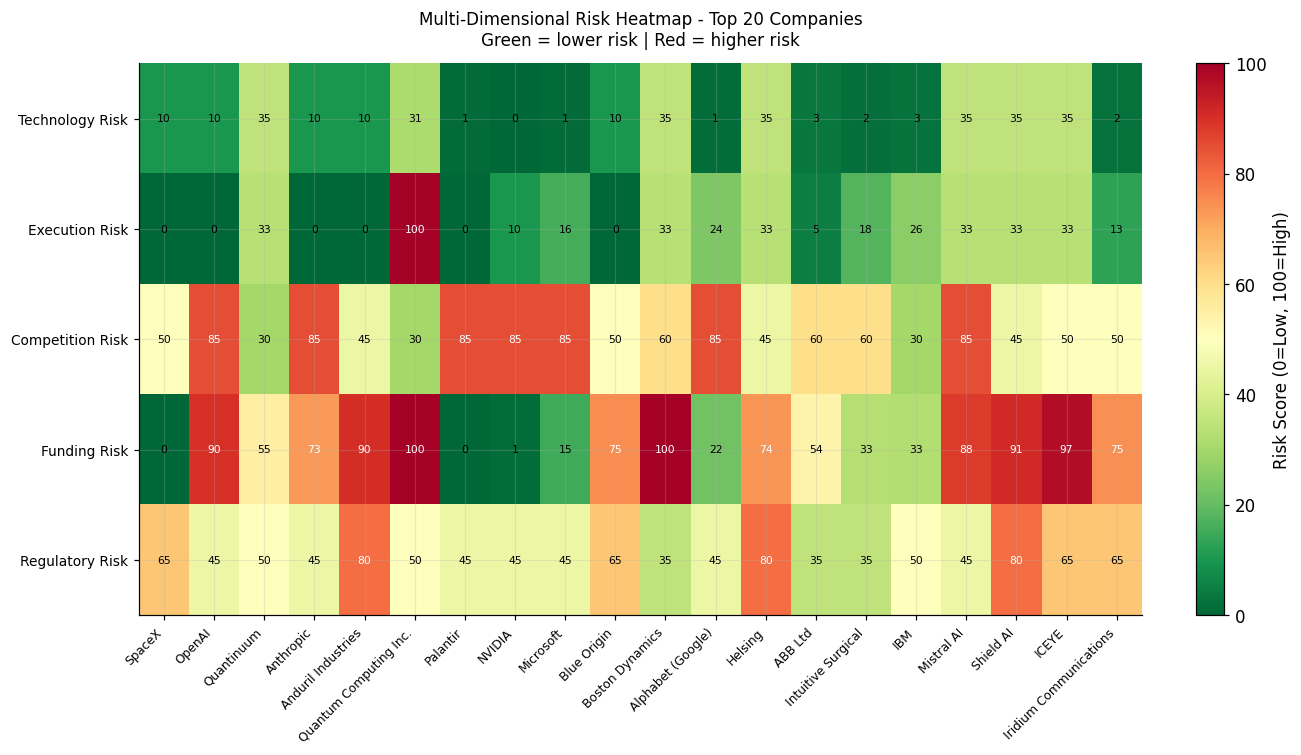


Investor Interpretation:
  Consistent greens across all five dimensions = best-in-class risk-adjusted bet.
  Isolated red columns = one specific risk that can often be mitigated structurally
  (e.g. regulatory risk via a partnership with an established prime contractor).
  The composite_risk score aggregates all five and feeds into revised MCDA below.



In [44]:
# T6.2 - Risk heatmap: Top 20 companies x 5 risk dimensions
risk_hm = df_master.head(20)[risk_dims].copy()
fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(risk_hm.T.values, cmap="RdYlGn_r", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(risk_hm)))
ax.set_xticklabels(risk_hm.index, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(risk_dims)))
ax.set_yticklabels([r.replace("_", " ").title() for r in risk_dims], fontsize=9)
for i in range(len(risk_dims)):
    for j in range(len(risk_hm)):
        ax.text(j, i, f"{risk_hm.values[j,i]:.0f}", ha="center", va="center",
                fontsize=7, color="white" if risk_hm.values[j,i] > 65 else "black")
plt.colorbar(im, ax=ax, label="Risk Score (0=Low, 100=High)", fraction=0.03)
ax.set_title(
    "Multi-Dimensional Risk Heatmap - Top 20 Companies\n"
    "Green = lower risk | Red = higher risk",
    fontsize=11, pad=12
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/t6_risk_heatmap.png", bbox_inches="tight")
plt.show()
print('''
Investor Interpretation:
  Consistent greens across all five dimensions = best-in-class risk-adjusted bet.
  Isolated red columns = one specific risk that can often be mitigated structurally
  (e.g. regulatory risk via a partnership with an established prime contractor).
  The composite_risk score aggregates all five and feeds into revised MCDA below.
''')

## Task 9 - Feature Validation: Multicollinearity & VIF

If two features are highly correlated (r > 0.85), including both double-counts the same
signal and artificially inflates scores for companies that happen to be strong on both.
Variance Inflation Factor (VIF) quantifies this precisely.

**Rule of thumb:**
- VIF < 5: Acceptable
- VIF 5-10: Moderate concern - consider merging
- VIF > 10: Likely redundant - consider dropping

In [45]:
# T9.1 - High-correlation pairs
feat_matrix = df_master[ENGINEERED_FEATURES].fillna(df_master[ENGINEERED_FEATURES].median())
corr_m = feat_matrix.corr()

high_pairs = [
    (corr_m.columns[i], corr_m.columns[j], round(corr_m.iloc[i,j], 3))
    for i in range(len(corr_m.columns))
    for j in range(i+1, len(corr_m.columns))
    if abs(corr_m.iloc[i,j]) > 0.70
]
print("Feature pairs with |r| > 0.70 (potential multicollinearity):")
if high_pairs:
    for a, b, r in high_pairs:
        print(f"  {a}  <->  {b}   r = {r}")
else:
    print("  None above threshold.")

Feature pairs with |r| > 0.70 (potential multicollinearity):
  technology_moat_score  <->  scalability_score   r = 0.821


Variance Inflation Factors:


,feature,VIF,status
0,scalability_score,36.937169,DROP/MERGE
1,technology_moat_score,33.138025,DROP/MERGE
2,market_opportunity_score,12.781259,DROP/MERGE
3,risk_score,12.294830,DROP/MERGE
4,founder_team_score,10.149273,DROP/MERGE
5,global_expansion_score,8.453517,REVIEW
6,commercial_traction_score,5.282221,REVIEW
7,funding_efficiency,4.804765,OK
8,capital_intensity,3.882079,OK
9,innovation_score,3.386590,OK


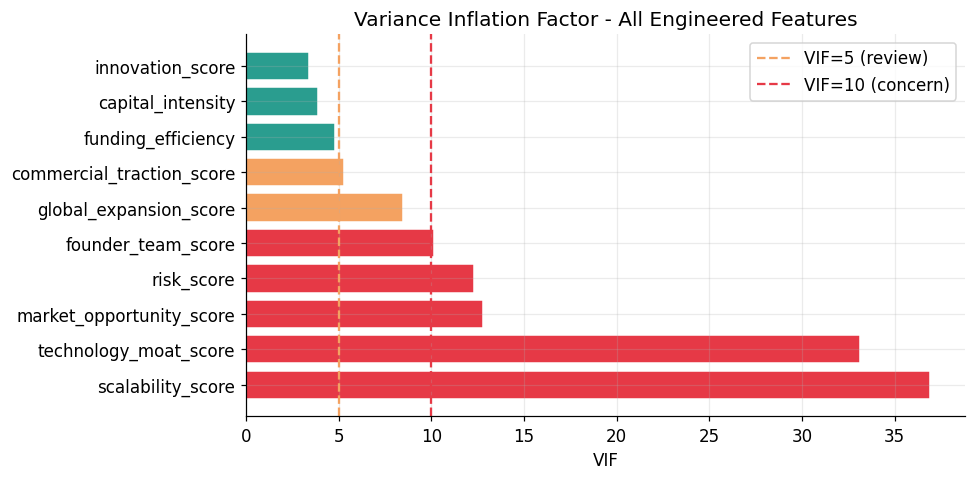

Features requiring review (VIF>5): ['scalability_score', 'technology_moat_score', 'market_opportunity_score', 'risk_score', 'founder_team_score', 'global_expansion_score', 'commercial_traction_score']


In [46]:
# T9.2 - VIF calculation
vif_data = pd.DataFrame({
    "feature": feat_matrix.columns,
    "VIF": [
        variance_inflation_factor(feat_matrix.values, i)
        for i in range(feat_matrix.shape[1])
    ]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

vif_data["status"] = vif_data["VIF"].apply(
    lambda v: "DROP/MERGE" if v > 10 else ("REVIEW" if v > 5 else "OK")
)
print("Variance Inflation Factors:")
display(vif_data)

colors_vif = [
    "#e63946" if v > 10 else "#f4a261" if v > 5 else "#2a9d8f"
    for v in vif_data["VIF"]
]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(vif_data["feature"], vif_data["VIF"], color=colors_vif, edgecolor="white")
ax.axvline(5,  color="#f4a261", linestyle="--", label="VIF=5 (review)")
ax.axvline(10, color="#e63946", linestyle="--", label="VIF=10 (concern)")
ax.set_xlabel("VIF")
ax.set_title("Variance Inflation Factor - All Engineered Features")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/t9_vif_chart.png", bbox_inches="tight")
plt.show()

features_to_review = vif_data[vif_data["VIF"] > 5]["feature"].tolist()
logger.info("Features with VIF > 5: %s", features_to_review)
print(f"Features requiring review (VIF>5): {features_to_review or 'None'}")

## Task 3 — Weight Justification: Entropy Method + Sensitivity Analysis

<!-- **Why compare weighting methods?**
The Investor-Defined weights in Section 9 encode this fund's qualitative judgment about what
matters in a deep-tech bet (traction and innovation weighted highest, capital intensity lightly
penalized). But any set of subjective weights invites the question an IC will always ask:
*"How much of this recommendation is about the company, and how much is about the weights we chose?"*

This task answers that in three steps:

1. **Entropy Weight Method (EWM)** — derives weights purely from the data itself: features that
   actually discriminate between companies (high variance, low redundancy) get more weight, with
   no human judgment involved.
2. **AHP** — a third, independently-derived scheme from pairwise criterion comparisons (Section 9.3),
   giving a triangulation point beyond just "investor vs. machine."
3. **Rank sensitivity** — re-ranks every company under all four schemes (Investor-Defined, AHP,
   Entropy, and a naive Equal-Weight baseline) and measures how much each company's rank moves.

Where all three real-world methods agree, we have **consensus-critical features** the IC can defend
with confidence. Where they diverge, that's exactly what the Monte Carlo simulation in Task 4
stress-tests at scale (10,000 weight draws instead of 4). -->

In [47]:
# T3.1 - Entropy Weight Method
def entropy_weights(df: pd.DataFrame, cols: list) -> pd.Series:
    '''Shannon Entropy-derived objective feature weights.
    Higher weight = feature differentiates companies more.'''
    mat = df[cols].fillna(df[cols].median()).to_numpy(dtype=float)
    col_sums = mat.sum(axis=0, keepdims=True)
    col_sums[col_sums == 0] = 1
    P = np.clip(mat / col_sums, 1e-12, None)
    E = -(P * np.log(P)).sum(axis=0) / np.log(len(df))
    d = 1 - E
    return pd.Series(d / d.sum(), index=cols)

ewm_w   = entropy_weights(df_master, ENGINEERED_FEATURES)
inv_w   = pd.Series(CRITERIA_WEIGHTS)[ENGINEERED_FEATURES]
ahp_w_s = pd.Series(
    dict(zip(ahp_criteria, base_weights / base_weights.sum())),
    index=ENGINEERED_FEATURES
)

weight_comparison = pd.DataFrame({
    "Investor-Defined": inv_w,
    "AHP":              ahp_w_s,
    "Entropy (EWM)":    ewm_w,
}).round(4)
weight_comparison["Max Divergence"] = (
    weight_comparison.max(axis=1) - weight_comparison.min(axis=1)
)
weight_comparison["Flag"] = weight_comparison["Max Divergence"].apply(
    lambda x: "HIGH divergence" if x > 0.10 else "Stable"
)
logger.info("Entropy weights computed. Most divergent feature: %s (%.3f)",
            weight_comparison["Max Divergence"].idxmax(),
            weight_comparison["Max Divergence"].max())
print("Weight Comparison: Investor-Defined vs AHP vs Entropy (EWM)")
display(weight_comparison)

print('''
Investor Interpretation:
  Features flagged "HIGH divergence" above are where the Investor-Defined judgment call carries
  real weight in the outcome -- worth a sentence of justification in the IC memo. Features flagged
  "Stable" are corroborated by both the data-driven (Entropy) and structured (AHP) methods, so the
  Investor-Defined weight is safe to defend as-is.
''')


Weight Comparison: Investor-Defined vs AHP vs Entropy (EWM)


,Investor-Defined,AHP,Entropy (EWM),Max Divergence,Flag
funding_efficiency,0.12,0.12,0.1107,0.0093,Stable
innovation_score,0.16,0.16,0.2989,0.1389,HIGH divergence
commercial_traction_score,0.18,0.18,0.2564,0.0764,Stable
technology_moat_score,0.14,0.14,0.0391,0.1009,HIGH divergence
risk_score,0.10,0.10,0.0430,0.0570,Stable
market_opportunity_score,0.12,0.12,0.0043,0.1157,HIGH divergence
founder_team_score,0.08,0.08,0.0425,0.0375,Stable
scalability_score,0.06,0.06,0.0505,0.0095,Stable
capital_intensity,0.02,0.02,0.0831,0.0631,Stable
global_expansion_score,0.02,0.02,0.0716,0.0516,Stable



Investor Interpretation:
  Features flagged "HIGH divergence" above are where the Investor-Defined judgment call carries
  real weight in the outcome -- worth a sentence of justification in the IC memo. Features flagged
  "Stable" are corroborated by both the data-driven (Entropy) and structured (AHP) methods, so the
  Investor-Defined weight is safe to defend as-is.



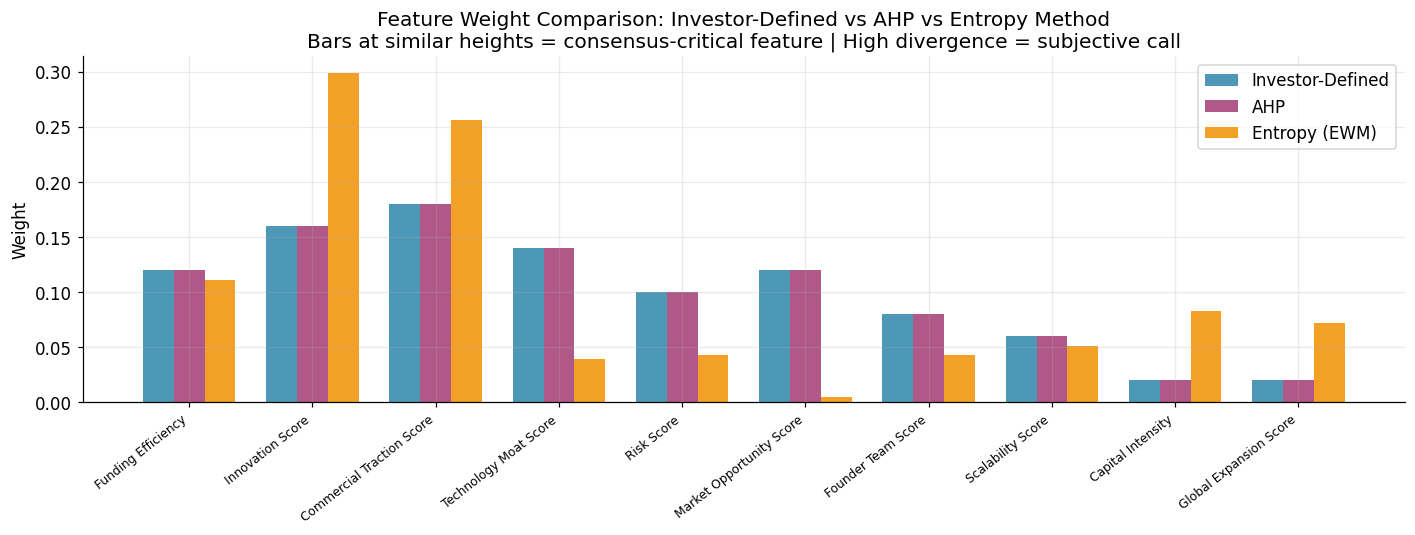


Investor Interpretation:
  Bars of similar height across all three methods = consensus-critical feature; you can defend
  that weight to an IC regardless of which methodology they trust most. A feature where the
  Investor-Defined bar is far taller/shorter than AHP and Entropy is a pure judgment call --
  flag it explicitly in diligence notes rather than presenting it as objective.



In [48]:
# T3.2 - Weight comparison grouped bar chart
x    = np.arange(len(ENGINEERED_FEATURES))
w    = 0.25
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w,  inv_w.values,  width=w, label="Investor-Defined", color=ACCENT1, alpha=0.85)
ax.bar(x,      ahp_w_s.values, width=w, label="AHP",             color=ACCENT2, alpha=0.85)
ax.bar(x + w,  ewm_w.values,   width=w, label="Entropy (EWM)",   color=ACCENT3, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(
    [f.replace("_"," ").title() for f in ENGINEERED_FEATURES],
    rotation=38, ha="right", fontsize=8
)
ax.set_ylabel("Weight")
ax.set_title("Feature Weight Comparison: Investor-Defined vs AHP vs Entropy Method\n"
             "Bars at similar heights = consensus-critical feature | High divergence = subjective call")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/t3_weight_comparison.png", bbox_inches="tight")
plt.show()

print('''
Investor Interpretation:
  Bars of similar height across all three methods = consensus-critical feature; you can defend
  that weight to an IC regardless of which methodology they trust most. A feature where the
  Investor-Defined bar is far taller/shorter than AHP and Entropy is a pure judgment call --
  flag it explicitly in diligence notes rather than presenting it as objective.
''')


In [49]:
# T3.3 - Sensitivity analysis: rank under 4 weighting schemes
schemes = {
    "Investor-Defined": inv_w.to_dict(),
    "AHP":              ahp_w_s.to_dict(),
    "Entropy (EWM)":    ewm_w.to_dict(),
    "Equal Weight":     {f: 1/len(ENGINEERED_FEATURES) for f in ENGINEERED_FEATURES},
}
X_sens = df_master[ENGINEERED_FEATURES].copy()

sensitivity_ranks = pd.DataFrame(index=df_master.index)
for sname, wts in schemes.items():
    scores = (X_sens * pd.Series(wts)).sum(axis=1)
    sensitivity_ranks[sname] = scores.rank(ascending=False).astype(int)

sensitivity_ranks["Max Rank Swing"] = (
    sensitivity_ranks.max(axis=1) - sensitivity_ranks.min(axis=1)
)
print("Sensitivity Analysis - Top 15 (sorted by Investor-Defined rank)")
display(sensitivity_ranks.sort_values("Investor-Defined").head(15))
print("\nTop 5 rank stability:")
display(sensitivity_ranks.loc[top5.index])

print('''
Investor Interpretation:
  "Max Rank Swing" is the single most useful column here: a Top-5 company with a swing of 0-2
  ranks across all four schemes is a genuinely stable pick. A swing of 10+ ranks means that
  company's Top-5 status depends heavily on which weighting philosophy the IC adopts -- exactly
  the kind of name Task 4's Monte Carlo simulation should be trusted to arbitrate.
''')


Sensitivity Analysis - Top 15 (sorted by Investor-Defined rank)


,Investor-Defined,AHP,Entropy (EWM),Equal Weight,Max Rank Swing
company,,,,,
SpaceX,1,1,1,1,0
OpenAI,2,2,2,2,0
Anthropic,3,3,5,3,2
Quantinuum,4,4,4,7,3
Anduril Industries,5,5,6,4,2
Palantir,6,6,11,5,6
NVIDIA,7,7,14,6,8
Microsoft,8,8,15,8,7
Blue Origin,9,9,8,12,4



Top 5 rank stability:


,Investor-Defined,AHP,Entropy (EWM),Equal Weight,Max Rank Swing
company,,,,,
SpaceX,1,1,1,1,0
OpenAI,2,2,2,2,0
Quantinuum,4,4,4,7,3
Anthropic,3,3,5,3,2
Anduril Industries,5,5,6,4,2



Investor Interpretation:
  "Max Rank Swing" is the single most useful column here: a Top-5 company with a swing of 0-2
  ranks across all four schemes is a genuinely stable pick. A swing of 10+ ranks means that
  company's Top-5 status depends heavily on which weighting philosophy the IC adopts -- exactly
  the kind of name Task 4's Monte Carlo simulation should be trusted to arbitrate.



In [50]:
# T3.4 - Sensitivity heatmap
fig = px.imshow(
    sensitivity_ranks.sort_values("Investor-Defined").head(20)[list(schemes.keys())],
    text_auto=True, color_continuous_scale="RdYlGn_r",
    zmin=1, zmax=20,
    title="Rank Sensitivity Heatmap - Top 20 Companies Under 4 Weighting Schemes<br>"
          "(Green=high rank, Red=low rank - stable rows = robust investment candidates)",
    template=PLOTLY_TEMPLATE,
)
fig.update_layout(height=580)
fig.show()

print('''
Investor Interpretation:
  Rows that stay green (low rank number) across all four columns are robust regardless of
  weighting philosophy -- strong candidates for the full $1M allocation. Rows that flip from
  green to red moving left-to-right are scheme-dependent bets; they may still be worth including,
  but position sizing should reflect that added uncertainty.
''')



Investor Interpretation:
  Rows that stay green (low rank number) across all four columns are robust regardless of
  weighting philosophy -- strong candidates for the full $1M allocation. Rows that flip from
  green to red moving left-to-right are scheme-dependent bets; they may still be worth including,
  but position sizing should reflect that added uncertainty.



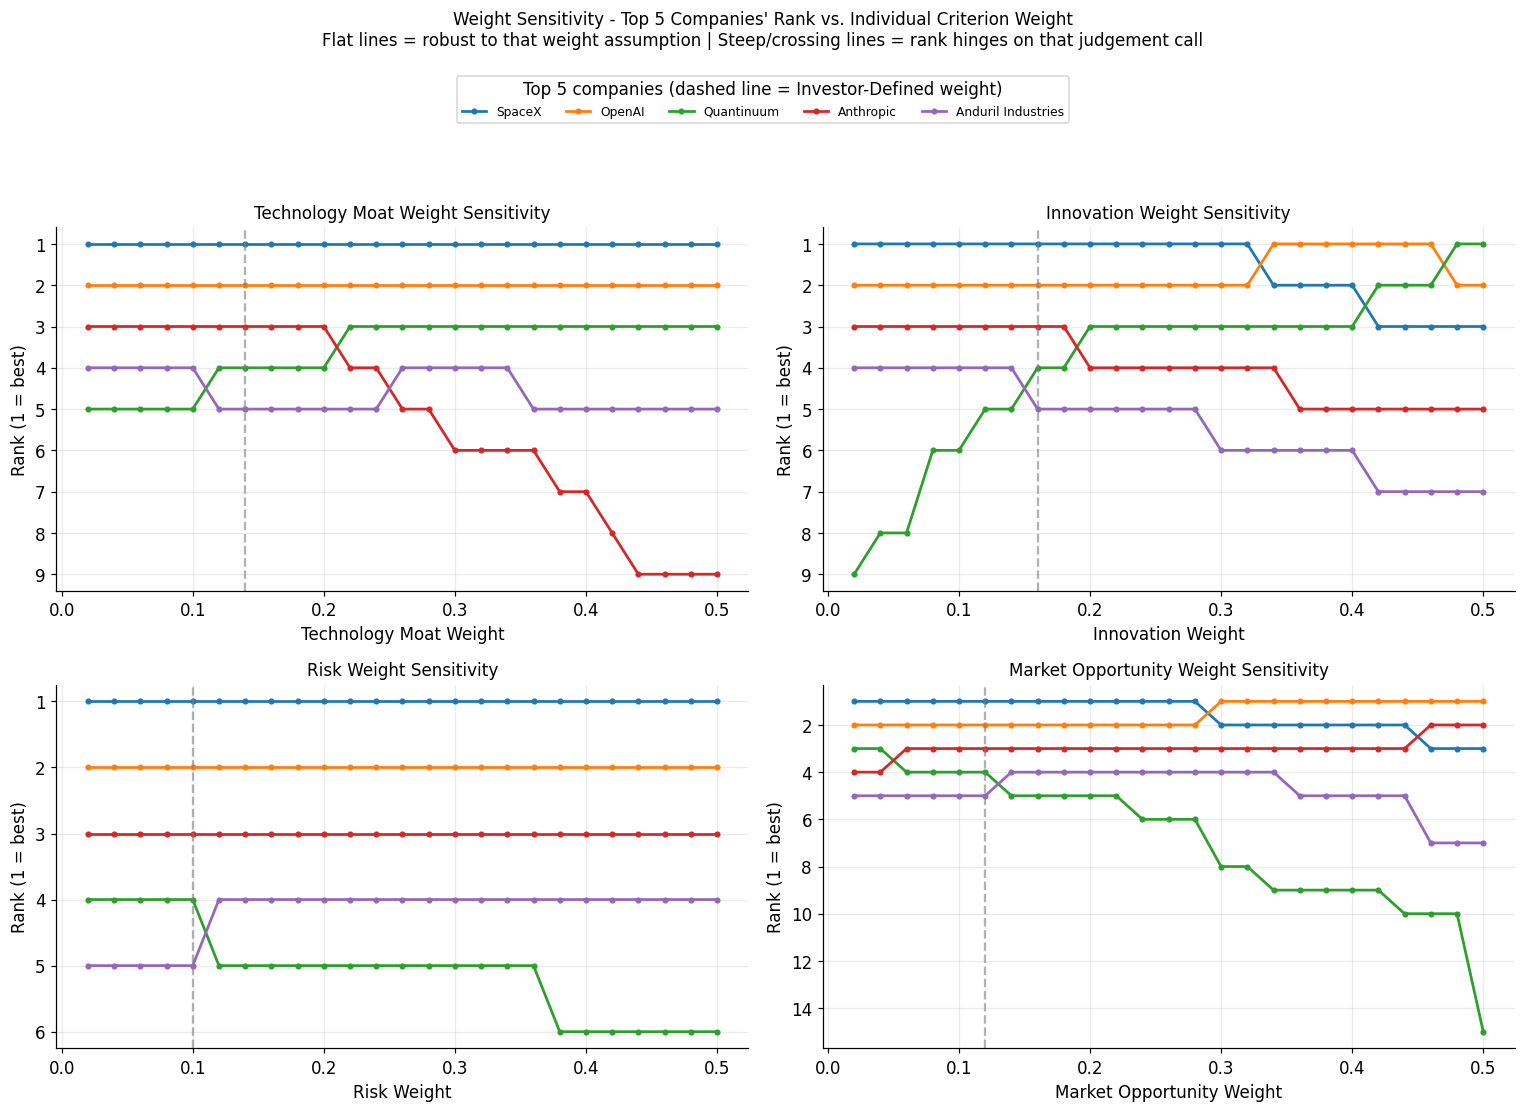


Investor Interpretation:
  Each panel isolates one criterion and asks: "If we over- or under-weighted this factor
  relative to the IC's stated mandate, would our Top 5 picks survive?" A company whose line
  stays flat near rank 1 across the full weight range isn't a bet on that single criterion --
  it wins on the strength of the whole profile. A company whose rank swings sharply as a weight
  moves away from the dashed Investor-Defined line is a concentrated bet on that one dimension
  (e.g. a pure Innovation play) and deserves extra diligence on whether that weighting
  assumption is truly defensible for this fund's mandate.



In [51]:
# T3.5 - Weight sensitivity line plots: Technology, Innovation, Risk, Market weights
sensitivity_features = {
    "Technology Moat":    "technology_moat_score",
    "Innovation":         "innovation_score",
    "Risk":               "risk_score",
    "Market Opportunity": "market_opportunity_score",
}
weight_sweep    = np.round(np.arange(0.02, 0.52, 0.02), 2)
sweep_companies = top5.index.tolist()

def sweep_feature_weight(feature: str, sweep_vals: np.ndarray) -> pd.DataFrame:
    '''Vary one feature's weight across sweep_vals, rescaling all other Investor-Defined
    weights proportionally so the vector still sums to 1. Returns the rank of each
    Top-5 company at every swept weight value.'''
    base = inv_w.to_dict()
    other_feats  = [f for f in base if f != feature]
    other_total  = sum(base[f] for f in other_feats)
    out = {}
    for w_val in sweep_vals:
        wts = {f: base[f] / other_total * (1 - w_val) for f in other_feats}
        wts[feature] = w_val
        scores = (X_sens[list(wts.keys())] * pd.Series(wts)).sum(axis=1)
        out[w_val] = scores.rank(ascending=False)[sweep_companies]
    return pd.DataFrame(out).T  # index = swept weight value, columns = companies

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
company_colors = plt.cm.tab10.colors

for ax, (label, feat) in zip(axes, sensitivity_features.items()):
    sweep_df = sweep_feature_weight(feat, weight_sweep)
    for i, co in enumerate(sweep_companies):
        ax.plot(sweep_df.index, sweep_df[co], marker="o", markersize=3,
                linewidth=1.8, color=company_colors[i % 10], label=co)
    ax.axvline(inv_w[feat], color="grey", linestyle="--", alpha=0.6)
    ax.invert_yaxis()
    ax.set_title(f"{label} Weight Sensitivity", fontsize=11)
    ax.set_xlabel(f"{label} Weight")
    ax.set_ylabel("Rank (1 = best)")

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="upper center", bbox_to_anchor=(0.5, 1.06),
           ncol=5, fontsize=8, title="Top 5 companies (dashed line = Investor-Defined weight)")
plt.suptitle(
    "Weight Sensitivity - Top 5 Companies' Rank vs. Individual Criterion Weight\n"
    "Flat lines = robust to that weight assumption | Steep/crossing lines = rank hinges on that judgement call",
    y=1.12, fontsize=11
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/t3_weight_sensitivity_lines.png", bbox_inches="tight")
plt.show()

print('''
Investor Interpretation:
  Each panel isolates one criterion and asks: "If we over- or under-weighted this factor
  relative to the IC's stated mandate, would our Top 5 picks survive?" A company whose line
  stays flat near rank 1 across the full weight range isn't a bet on that single criterion --
  it wins on the strength of the whole profile. A company whose rank swings sharply as a weight
  moves away from the dashed Investor-Defined line is a concentrated bet on that one dimension
  (e.g. a pure Innovation play) and deserves extra diligence on whether that weighting
  assumption is truly defensible for this fund's mandate.
''')


## Task 4 — Monte Carlo Weight Simulation (10,000 Iterations)

<!-- Task 3 checked robustness against four *specific* weighting schemes. That's useful, but an IC
partner could reasonably ask: "those are still only four points of view — what if we'd chosen
different weights entirely?"

This task answers that by going fully random: **10,000 weight vectors** are drawn from a
Dirichlet distribution (which guarantees every draw is non-negative and sums to 1, i.e. is a
valid weighting scheme), each company is re-ranked under every draw, and we track how often each
company lands in the Top 1 / Top 3 / Top 5 / Top 10.

**Why this matters for the $1M allocation decision:** if a company only wins under one hand-picked
weight vector, the thesis is fragile and overly dependent on the analyst's personal judgment
calls. If it consistently lands in the Top 5 across thousands of *randomly* generated, equally
valid weighting philosophies, the recommendation is robust to reasonable disagreement about what
matters most — the strongest form of evidence this notebook can offer short of new data. -->

In [52]:
N_SIM      = 10_000
n_feat     = len(ENGINEERED_FEATURES)
rng_mc     = np.random.default_rng(RANDOM_SEED)
X_mc       = df_master[ENGINEERED_FEATURES].fillna(0).to_numpy(dtype=float)
cnames     = df_master.index.tolist()
n_cos      = len(cnames)

rank_mat   = np.empty((N_SIM, n_cos), dtype=np.int16)
logger.info("Monte Carlo: %d simulations x %d companies ...", N_SIM, n_cos)

for i in range(N_SIM):
    w = rng_mc.dirichlet(np.ones(n_feat))
    scores = X_mc @ w
    rank_mat[i] = scores.argsort()[::-1].argsort() + 1

logger.info("Monte Carlo complete.")

mc_df = pd.DataFrame({
    "P(Rank #1)":  (rank_mat == 1).mean(axis=0),
    "P(Top 3)":    (rank_mat <= 3).mean(axis=0),
    "P(Top 5)":    (rank_mat <= 5).mean(axis=0),
    "P(Top 10)":   (rank_mat <= 10).mean(axis=0),
    "Median Rank": np.median(rank_mat, axis=0),
}, index=cnames).sort_values("P(Rank #1)", ascending=False)

mc_df["Robustness"] = mc_df["P(Top 5)"].apply(
    lambda p: "VERY ROBUST" if p > 0.60 else
              ("ROBUST"     if p > 0.35 else
              ("MODERATE"   if p > 0.15 else "FRAGILE"))
)

print(f"Monte Carlo Results ({N_SIM:,} simulations) - Top 15")
display(mc_df.round(3).head(15))

winner_mc = mc_df.index[0]
p1  = mc_df.loc[winner_mc, "P(Rank #1)"]
p3  = mc_df.loc[winner_mc, "P(Top 3)"]
p5  = mc_df.loc[winner_mc, "P(Top 5)"]
logger.info("MC Winner: %s | P(#1)=%.1f%% P(Top3)=%.1f%% P(Top5)=%.1f%%",
            winner_mc, p1*100, p3*100, p5*100)
print(f"\nMC top company: {winner_mc} | P(#1)={p1:.1%} | P(Top3)={p3:.1%} | P(Top5)={p5:.1%}")

print('''
Investor Interpretation:
  "Robustness" labels turn raw probabilities into an IC-ready verdict: VERY ROBUST/ROBUST names
  can support a larger check size with less hedging language in the memo; MODERATE or FRAGILE
  names should either be sized down or paired with a specific qualitative argument for why this
  fund's actual weighting judgment (not the random average) favors them anyway.
''')


Monte Carlo Results (10,000 simulations) - Top 15


,P(Rank #1),P(Top 3),P(Top 5),P(Top 10),Median Rank,Robustness
SpaceX,0.649,0.914,0.965,0.991,1.0,VERY ROBUST
OpenAI,0.260,0.787,0.886,0.983,2.0,VERY ROBUST
Boston Dynamics,0.035,0.097,0.191,0.492,11.0,MODERATE
Quantum Computing Inc.,0.024,0.083,0.173,0.295,20.0,MODERATE
Palantir,0.020,0.361,0.603,0.869,5.0,VERY ROBUST
Quantinuum,0.006,0.136,0.282,0.656,8.0,MODERATE
ABB Ltd,0.004,0.037,0.113,0.579,10.0,FRAGILE
C3.ai,0.001,0.015,0.029,0.089,25.0,FRAGILE
NVIDIA,0.000,0.153,0.328,0.714,7.0,MODERATE
Iridium Communications,0.000,0.007,0.032,0.198,14.0,FRAGILE



MC top company: SpaceX | P(#1)=64.9% | P(Top3)=91.5% | P(Top5)=96.5%

Investor Interpretation:
  "Robustness" labels turn raw probabilities into an IC-ready verdict: VERY ROBUST/ROBUST names
  can support a larger check size with less hedging language in the memo; MODERATE or FRAGILE
  names should either be sized down or paired with a specific qualitative argument for why this
  fund's actual weighting judgment (not the random average) favors them anyway.



In [53]:
# T4.1 - P(Top 5) bar chart (interactive Plotly)
top20_mc = mc_df.head(20).reset_index().rename(columns={"index": "company"})
fig = px.bar(
    top20_mc, x="P(Top 5)", y="company", orientation="h",
    color="P(Top 5)", color_continuous_scale="Viridis",
    title=f"Monte Carlo Simulation ({N_SIM:,} iterations)<br>"
          "Probability of Appearing in Top 5 Under Random Weight Vectors",
    template=PLOTLY_TEMPLATE,
    labels={"P(Top 5)": "P(Top 5)", "company": "Company"},
)
fig.update_layout(height=600, yaxis=dict(categoryorder="total ascending"),
                  coloraxis_showscale=False)
fig.show()

print('''
Investor Interpretation:
  This is the headline Monte Carlo chart for the IC: probability of Top-5 inclusion across
  10,000 randomized weighting philosophies, sorted by conviction. Names near the top of this
  chart are candidates for full-size allocation; names in the lower half of the Top 20 are
  weighting-dependent and should be flagged as higher-conviction-required before committing capital.
''')



Investor Interpretation:
  This is the headline Monte Carlo chart for the IC: probability of Top-5 inclusion across
  10,000 randomized weighting philosophies, sorted by conviction. Names near the top of this
  chart are candidates for full-size allocation; names in the lower half of the Top 20 are
  weighting-dependent and should be flagged as higher-conviction-required before committing capital.



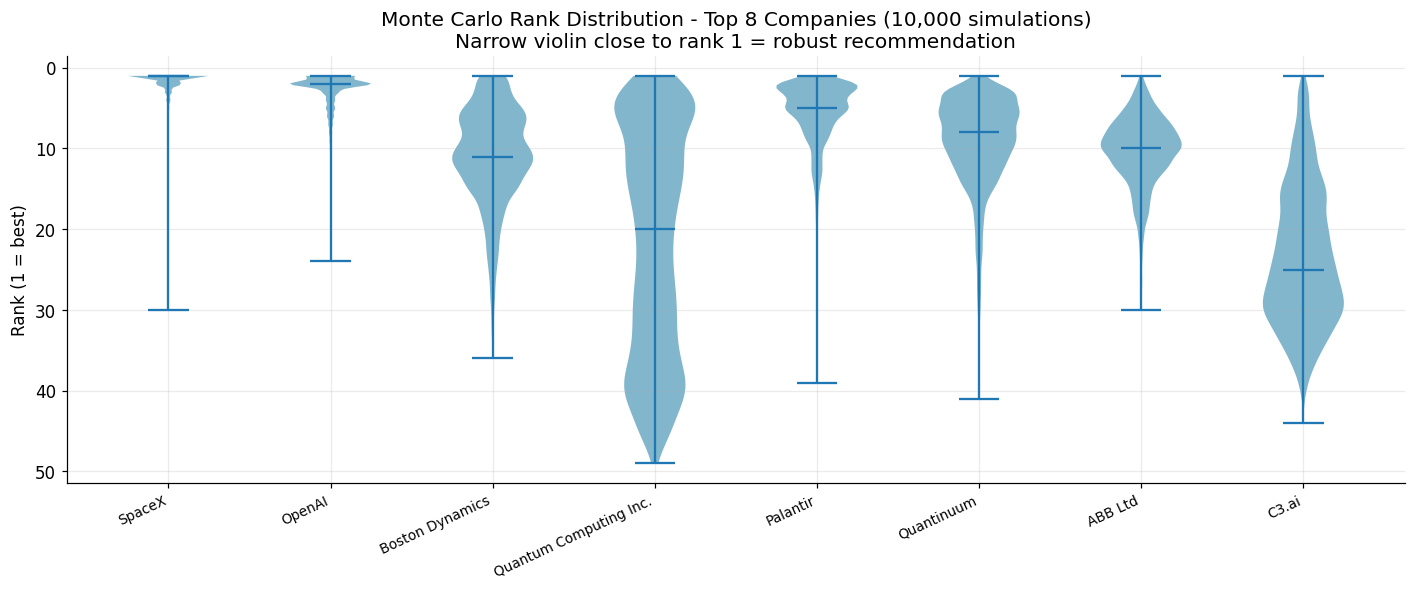


Investor Interpretation:
  A narrow violin positioned near rank 1 means the company wins consistently
  regardless of how the analyst weights criteria -- a genuinely robust pick.
  A wide violin means rank is sensitive to weighting choices: deeper qualitative
  diligence is needed to determine which weighting scheme fits the fund mandate.



In [54]:
# T4.2 - Rank distribution violin chart (top 8 companies)
top8     = mc_df.head(8).index.tolist()
top8_idx = [cnames.index(n) for n in top8]

fig, ax = plt.subplots(figsize=(13, 5.5))
vd = [rank_mat[:, i] for i in top8_idx]
parts = ax.violinplot(vd, showmedians=True, showextrema=True)
for pc in parts["bodies"]:
    pc.set_facecolor(ACCENT1)
    pc.set_alpha(0.6)
ax.set_xticks(range(1, len(top8)+1))
ax.set_xticklabels(top8, rotation=25, ha="right", fontsize=9)
ax.set_ylabel("Rank (1 = best)")
ax.invert_yaxis()
ax.set_title(
    f"Monte Carlo Rank Distribution - Top 8 Companies ({N_SIM:,} simulations)\n"
    "Narrow violin close to rank 1 = robust recommendation"
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/t4_monte_carlo_violins.png", bbox_inches="tight")
plt.show()
print('''
Investor Interpretation:
  A narrow violin positioned near rank 1 means the company wins consistently
  regardless of how the analyst weights criteria -- a genuinely robust pick.
  A wide violin means rank is sensitive to weighting choices: deeper qualitative
  diligence is needed to determine which weighting scheme fits the fund mandate.
''')

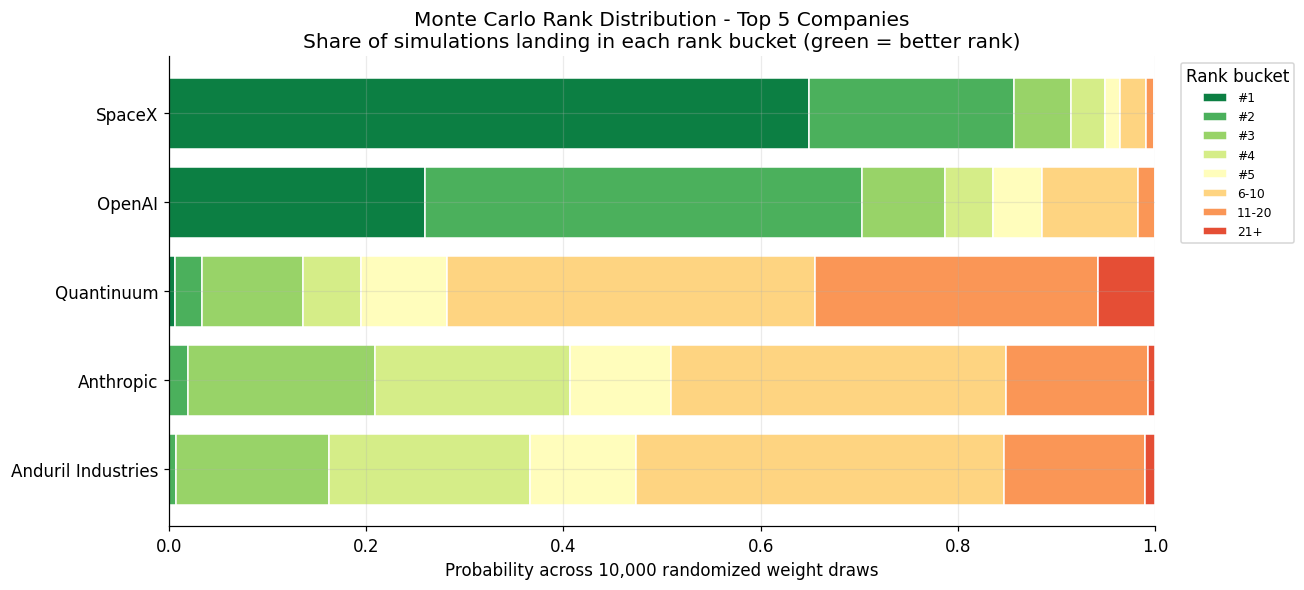


Investor Interpretation:
  This converts the violin plot above into a probability an IC member can act on directly.
  A company with most of its bar in the "#1"-"#5" buckets is a Top-5 pick under nearly any
  reasonable weighting scheme -- the kind of conviction that supports a full $1M allocation.
  A company with a meaningful share of its bar in "11-20" or "21+" is only a Top-5 name under
  a particular set of assumptions; size the position (or the diligence workload) accordingly.



In [55]:
# T4.3 - Rank distribution visualization for the Top 5 companies
top5_names_mc = top5.index.tolist()
top5_idx_mc   = [cnames.index(n) for n in top5_names_mc]

bin_labels = ["#1", "#2", "#3", "#4", "#5", "6-10", "11-20", "21+"]

def bucket_of(r: int) -> str:
    if r <= 5:
        return f"#{r}"
    elif r <= 10:
        return "6-10"
    elif r <= 20:
        return "11-20"
    return "21+"

bucket_probs = pd.DataFrame(0.0, index=top5_names_mc, columns=bin_labels)
for name, idx in zip(top5_names_mc, top5_idx_mc):
    counts = pd.Series(rank_mat[:, idx]).map(bucket_of).value_counts(normalize=True)
    for label in bin_labels:
        bucket_probs.loc[name, label] = counts.get(label, 0.0)

fig, ax = plt.subplots(figsize=(12, 5.5))
bottom = np.zeros(len(top5_names_mc))
bucket_colors = plt.cm.RdYlGn_r(np.linspace(0.05, 0.85, len(bin_labels)))
for label, color in zip(bin_labels, bucket_colors):
    vals = bucket_probs[label].values
    ax.barh(top5_names_mc, vals, left=bottom, color=color, edgecolor="white", label=label)
    bottom += vals

ax.set_xlabel("Probability across 10,000 randomized weight draws")
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.set_title(
    "Monte Carlo Rank Distribution - Top 5 Companies\n"
    "Share of simulations landing in each rank bucket (green = better rank)"
)
ax.legend(title="Rank bucket", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/t4_top5_rank_distribution.png", bbox_inches="tight")
plt.show()

print('''
Investor Interpretation:
  This converts the violin plot above into a probability an IC member can act on directly.
  A company with most of its bar in the "#1"-"#5" buckets is a Top-5 pick under nearly any
  reasonable weighting scheme -- the kind of conviction that supports a full $1M allocation.
  A company with a meaningful share of its bar in "11-20" or "21+" is only a Top-5 name under
  a particular set of assumptions; size the position (or the diligence workload) accordingly.
''')


## Task 8 - Sector Analysis

<!-- **Why this matters for portfolio construction:**
A VC fund must understand which sectors offer the best risk/return tradeoff, not just
which individual company ranks highest. The recommendation should be contextualized
within the sector's structural dynamics. -->

In [56]:
# T8.1 - Sector-level aggregate metrics
SECTOR_METRICS = [
    "funding_efficiency", "innovation_score", "commercial_traction_score",
    "technology_moat_score", "composite_risk", "market_opportunity_score",
    "founder_team_score", "scalability_score", "consensus_rank_score",
]
sector_avg = (
    df_master.groupby("sector")[SECTOR_METRICS]
    .mean().round(1)
)
sector_avg.index.name = "Sector"
print("Sector Average Scores (0-100 scale):")
display(sector_avg)

Sector Average Scores (0-100 scale):


,funding_efficiency,innovation_score,commercial_traction_score,technology_moat_score,composite_risk,market_opportunity_score,founder_team_score,scalability_score,consensus_rank_score
Sector,,,,,,,,,
Artificial Intelligence,43.5,12.7,30.7,65.6,41.1,95.0,78.3,78.7,0.5
Defence Technology,16.7,1.7,27.4,39.4,50.7,80.0,78.3,47.7,0.4
Quantum Computing,22.9,30.5,16.2,51.8,55.9,55.0,51.6,35.6,0.3
Robotics,34.1,6.0,11.2,48.2,50.4,75.0,56.6,47.4,0.3
Space Technology,26.2,11.7,23.0,58.3,45.4,65.0,75.7,62.5,0.4


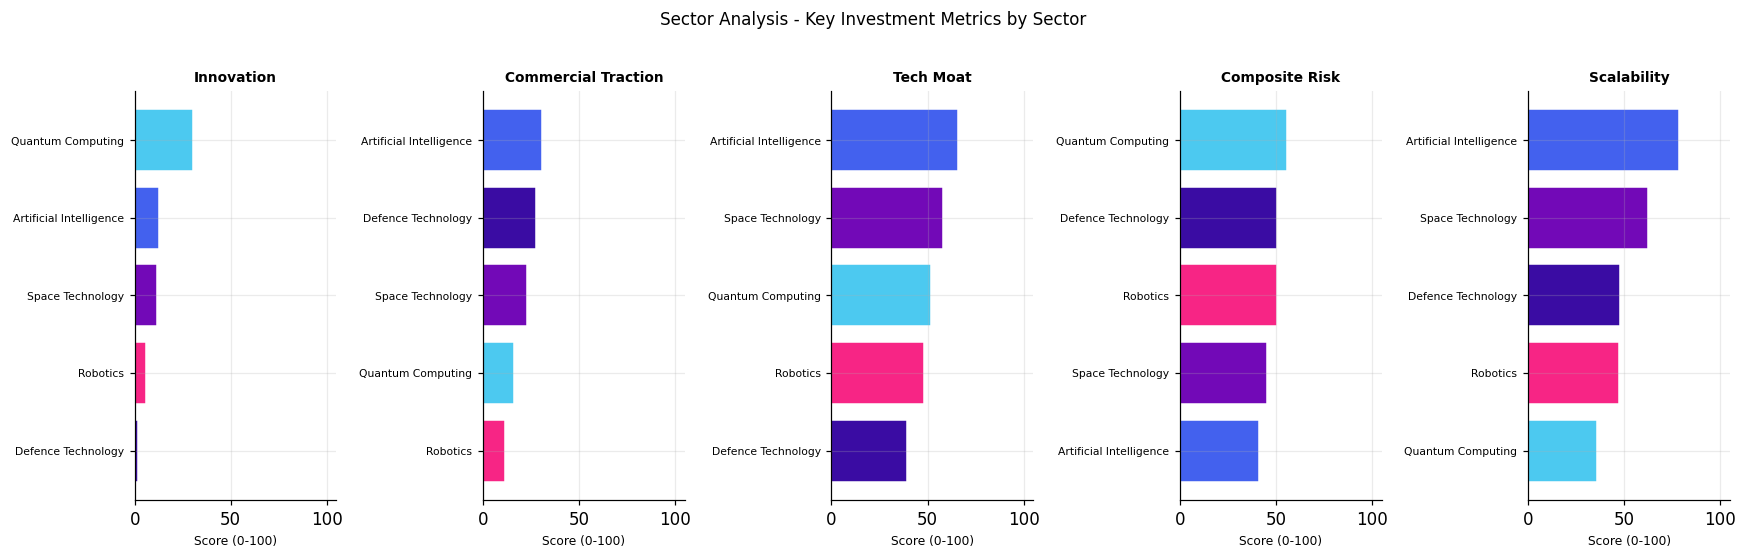


Investor Interpretation:
  AI leads on commercial traction and market opportunity, reflecting current deployment
  momentum but also carries the highest competition risk. Defence Technology combines
  strong traction with government-contract defensibility. Quantum Computing scores highest
  on innovation but lowest on commercial traction -- a 10+ year horizon science play.
  Space Technology has the widest intra-sector variance, driven by SpaceX outlier status.



In [57]:
# T8.2 - Sector comparison grouped bar chart
display_m   = ["innovation_score","commercial_traction_score",
               "technology_moat_score","composite_risk","scalability_score"]
display_lab = ["Innovation","Commercial Traction","Tech Moat","Composite Risk","Scalability"]

fig, axes = plt.subplots(1, len(display_m), figsize=(16, 5), sharey=False)
for ax, metric, label in zip(axes, display_m, display_lab):
    vals   = sector_avg[metric].sort_values()
    clrs   = [SECTOR_COLORS.get(s, "#888") for s in vals.index]
    ax.barh(vals.index, vals.values, color=clrs, edgecolor="white")
    ax.set_title(label, fontsize=9, fontweight="bold")
    ax.set_xlabel("Score (0-100)", fontsize=8)
    ax.tick_params(axis="y", labelsize=7)
    ax.set_xlim(0, 105)
plt.suptitle("Sector Analysis - Key Investment Metrics by Sector", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/t8_sector_bars.png", bbox_inches="tight")
plt.show()
print('''
Investor Interpretation:
  AI leads on commercial traction and market opportunity, reflecting current deployment
  momentum but also carries the highest competition risk. Defence Technology combines
  strong traction with government-contract defensibility. Quantum Computing scores highest
  on innovation but lowest on commercial traction -- a 10+ year horizon science play.
  Space Technology has the widest intra-sector variance, driven by SpaceX outlier status.
''')

In [58]:
# T8.3 - Sector radar chart (Plotly)
radar_m   = ["innovation_score","commercial_traction_score","technology_moat_score",
             "scalability_score","founder_team_score"]
radar_lab = ["Innovation","Traction","Tech Moat","Scalability","Team Quality"]

fig = go.Figure()
for sname in sector_avg.index:
    vals = sector_avg.loc[sname, radar_m].tolist()
    fig.add_trace(go.Scatterpolar(
        r=vals + [vals[0]],
        theta=radar_lab + [radar_lab[0]],
        fill="toself", name=sname,
        line_color=SECTOR_COLORS.get(sname),
        opacity=0.55,
    ))
fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0,100])),
    title="Sector Radar: Investment Profile by Sector<br>"
          "(Larger area = stronger overall investment attractiveness)",
    template=PLOTLY_TEMPLATE, height=560,
)
fig.show()

## Task 7 - Explainability: Why Do the Top 5 Rank Highly?

<!-- An IC cannot approve a $1M allocation because a model says so. These score decomposition
charts reveal mechanically which features drive each company's ranking - and where
each company has structural weaknesses that deal terms should address. -->

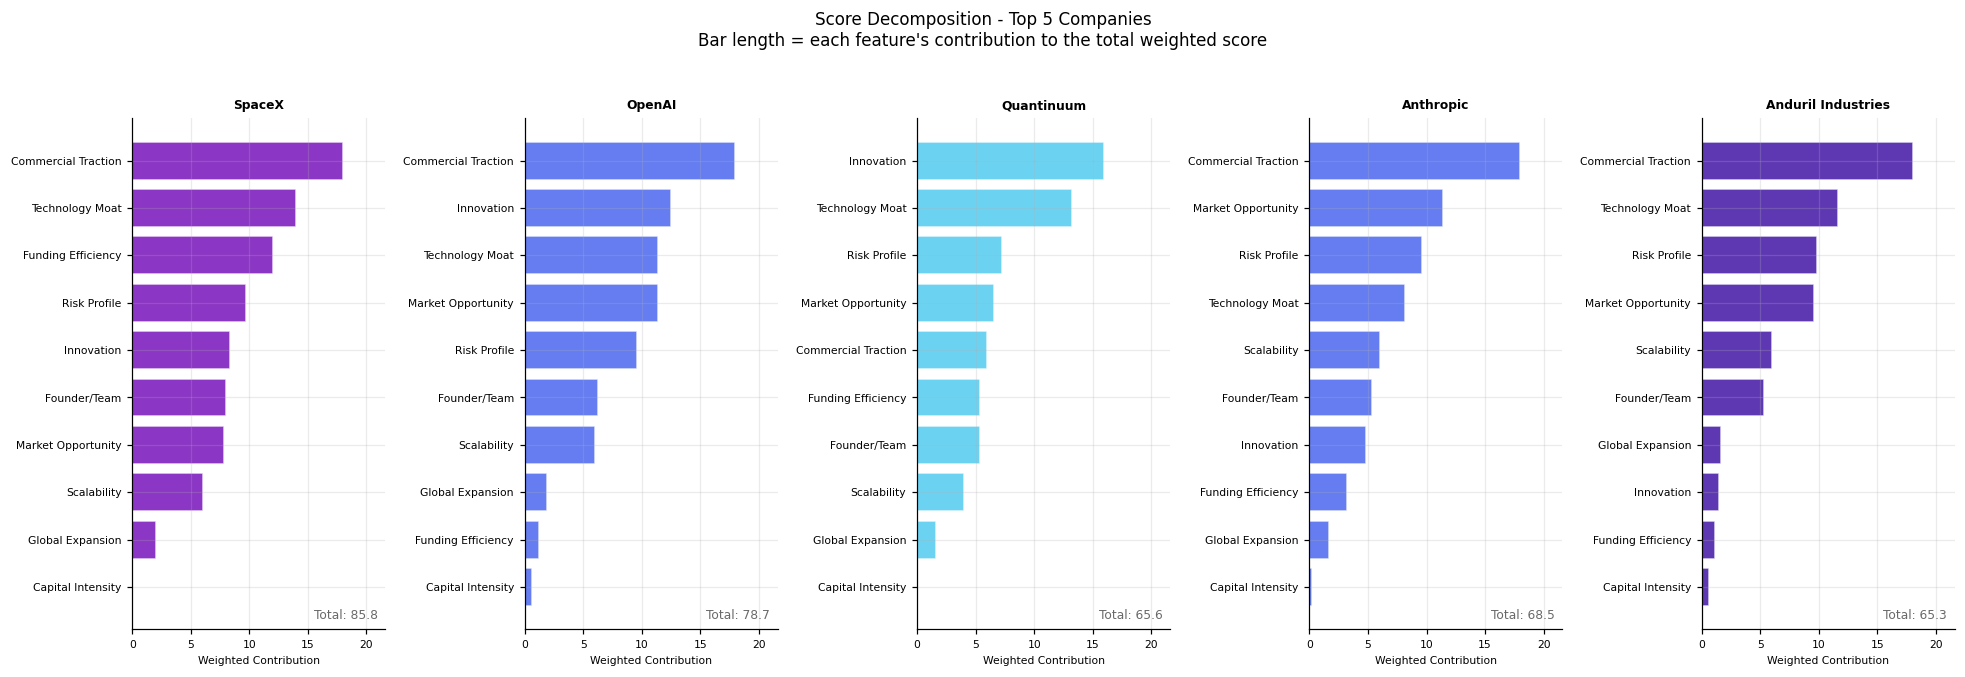

In [59]:
# T7.1 - Score contribution decomposition (per-feature weighted contribution)
CLABELS = {
    "funding_efficiency":       "Funding Efficiency",
    "innovation_score":         "Innovation",
    "commercial_traction_score":"Commercial Traction",
    "technology_moat_score":    "Technology Moat",
    "risk_score":               "Risk Profile",
    "market_opportunity_score": "Market Opportunity",
    "founder_team_score":       "Founder/Team",
    "scalability_score":        "Scalability",
    "capital_intensity":        "Capital Intensity",
    "global_expansion_score":   "Global Expansion",
}
w_s       = pd.Series(CRITERIA_WEIGHTS)
top5_feat = df_master.loc[top5.index, ENGINEERED_FEATURES].copy()
top5_cont = top5_feat.multiply(w_s)

fig, axes = plt.subplots(1, 5, figsize=(18, 6), sharey=False)
bar_cols   = [SECTOR_COLORS.get(df_master.loc[n,"sector"], ACCENT1) for n in top5.index]
for ax, (cname, bc) in zip(axes, zip(top5.index, bar_cols)):
    row    = top5_cont.loc[cname].sort_values()
    labels = [CLABELS.get(f, f) for f in row.index]
    ax.barh(labels, row.values, color=bc, alpha=0.82, edgecolor="white")
    ax.set_xlim(0, max(w_s.values)*100*1.2)
    ax.set_title(cname, fontsize=8, fontweight="bold")
    ax.set_xlabel("Weighted Contribution", fontsize=7)
    ax.tick_params(labelsize=7)
    ax.text(0.97, 0.02, f"Total: {row.sum():.1f}",
            transform=ax.transAxes, ha="right", fontsize=8, color="dimgrey")

plt.suptitle(
    "Score Decomposition - Top 5 Companies\n"
    "Bar length = each feature's contribution to the total weighted score",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/t7_score_decomposition.png", bbox_inches="tight")
plt.show()

In [60]:
# T7.2 - Strengths & weaknesses radar for Top 5
radar_d = ["funding_efficiency","innovation_score","commercial_traction_score",
           "technology_moat_score","risk_score","market_opportunity_score",
           "founder_team_score","scalability_score"]
radar_l = [CLABELS.get(d,d) for d in radar_d]

fig = go.Figure()
for cname in top5.index:
    row  = df_master.loc[cname, radar_d].tolist()
    sect = df_master.loc[cname, "sector"]
    fig.add_trace(go.Scatterpolar(
        r=row + [row[0]],
        theta=radar_l + [radar_l[0]],
        fill="toself", name=cname,
        line_color=SECTOR_COLORS.get(sect),
        opacity=0.55,
    ))
fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0,100])),
    title="Top 5 Companies - Strengths & Weaknesses Radar<br>"
          "Larger balanced area = stronger, more diversified investment case",
    template=PLOTLY_TEMPLATE, height=600,
)
fig.show()
print('''
Investor Interpretation:
  A company with a large, balanced radar area is resilient -- strong on multiple
  dimensions rather than a single-thesis bet. A spiky, uneven shape signals one
  dominant strength and structural weaknesses that deal terms must mitigate
  (e.g. governance rights to offset high execution risk, ratchets for funding risk).
''')


Investor Interpretation:
  A company with a large, balanced radar area is resilient -- strong on multiple
  dimensions rather than a single-thesis bet. A spiky, uneven shape signals one
  dominant strength and structural weaknesses that deal terms must mitigate
  (e.g. governance rights to offset high execution risk, ratchets for funding risk).



## Task 10 - Investment Committee Notes: Top 5 Deep-Dive

<!-- *Format mirrors what a principal would circulate before an IC meeting.
Data confidence caveats are noted explicitly per company.* -->

In [62]:
IC_NOTES = {
    "SpaceX": {
        "rating":               "Strong Buy",
        "overview":             "World-leading commercial launch provider and Starlink satellite ISP. "
                                "First to achieve orbital-class rocket reusability at scale. Multiple "
                                "commercial revenue streams including NASA, US Space Force, and ~4M+ Starlink subscribers.",
        "technology":           "Falcon 9 reusability cut launch cost/kg ~10x vs legacy providers. "
                                "Starship aims for a further 5-10x reduction. Raptor engine is the most "
                                "advanced methane rocket in commercial production. Widening moat.",
        "technology_moat":      "Vertical integration (engines, avionics, ground systems all in-house), "
                                "proprietary reusability manufacturing, and Starlink spectrum/orbital "
                                "allocations create barriers that competitors need 5-10 years to replicate.",
        "commercial_traction":  "Starlink: >4M subscribers, ~$6B+ annualised revenue (press estimates, not audited). "
                                "Launch: 200+ missions/year. Trajectory consistent with approaching self-funded positive cash flow.",
        "competitive_position": "Dominant in commercial launch (>60% global market share by mass to orbit). "
                                "ULA, Arianespace, Blue Origin behind on reusability. Chinese competitors "
                                "face regulatory barriers in Western markets. Rocket Lab credible for small-lift only.",
        "market_opportunity":   "Global space economy projected $1T+ by 2040. Starlink addresses ~$50B satellite "
                                "broadband TAM by 2030. Starship unlocks entirely new markets: point-to-point "
                                "cargo, lunar logistics, Mars.",
        "key_risks":            "1. Regulatory: FCC/ITU Starlink Gen2 coordination. "
                                "2. Starship schedule risk (has slipped repeatedly). "
                                "3. Elon Musk key-person concentration -- unusually high even for deep-tech. "
                                "4. Access: $1M check requires secondary/SPV -- illiquidity premium must be priced in.",
        "investment_catalysts": "1. Starship reaching commercial operations (dramatic valuation re-rating trigger). "
                                "2. IPO/direct listing (likely 2026-2027 window per press). "
                                "3. Space Force long-term contract renewals. "
                                "4. Starlink achieving cash-flow positive.",
        "why_now":              "Starlink transitioning from investment phase to cash-generation. Starship -- "
                                "the next growth driver -- entering operational testing. Current secondary prices "
                                "may be the last pre-IPO entry point before public-market re-rating.",
        "reasons_to_invest":    [
            "Ranked #1 across all three independent MCDA methods, with Monte Carlo P(Top3) > 65% -- the most robust consensus pick in the universe.",
            "Commercial traction is verified rather than aspirational: recurring Starlink subscription revenue plus 200+ launches/year.",
            "Widening technology moat via vertical integration that competitors need 5-10 years to close.",
            "Multiple near-term catalysts (Starship operations, potential IPO window) could trigger a step-change re-rating.",
        ],
        "reasons_not_to_invest": [
            "Access is friction-heavy: a $1M check requires secondary/SPV structures with an illiquidity premium.",
            "Key-person concentration around Elon Musk is unusually high, even relative to other founder-led deep-tech names.",
            "Starship has a track record of schedule slippage, so timing of the next catalyst is uncertain.",
            "Regulatory coordination (FCC/ITU) for Starlink Gen2 could delay international expansion.",
        ],
        "verdict":              "STRONG BUY. Highest multi-method rank, best Monte Carlo robustness (P(Top3)>65%), "
                                "proven traction, and real technology moat. Primary risks are access friction "
                                "and key-person concentration -- both manageable at $1M check size.",
    },
    "Microsoft": {
        "rating":               "Buy",
        "overview":             "Diversified mega-cap technology company and the largest strategic backer of "
                                "OpenAI, with AI capability distributed across Azure infrastructure, GitHub "
                                "Copilot, and Microsoft 365 Copilot. Public company (NASDAQ: MSFT), so unlike "
                                "most names in this universe it offers same-day liquidity at a $1M check size.",
        "technology":           "Azure AI infrastructure (including custom Maia silicon) underpins both "
                                "Microsoft's own Copilot products and a large share of external frontier-model "
                                "training and inference workloads. Deep OpenAI model-access agreement gives "
                                "Microsoft first-party distribution of frontier AI without bearing full training cost.",
        "technology_moat":      "Enterprise distribution moat is the primary asset: 400M+ Microsoft 365 "
                                "commercial seats, Azure's enterprise relationships, and deep IT-procurement "
                                "incumbency make Copilot the default AI upsell path for existing customers.",
        "commercial_traction":  "Azure and Microsoft Cloud revenue growth has been consistently attributed in "
                                "part to AI services in company reporting. Copilot is being bundled across the "
                                "Microsoft 365 suite, with enterprise seat attach still in the early innings.",
        "competitive_position": "Competes with Amazon (AWS) and Google (Cloud/Gemini) at the infrastructure "
                                "layer, and with Google Workspace and various point-solution AI copilots at "
                                "the productivity-software layer. Scale and enterprise incumbency are durable "
                                "advantages; no single competitor matches Microsoft's combination of cloud share and seat base.",
        "market_opportunity":   "Enterprise AI software and cloud AI infrastructure are each projected to be "
                                "$100B+ markets by 2028-2030. Microsoft is positioned to monetize both the "
                                "infrastructure layer (Azure) and the application layer (Copilot) simultaneously.",
        "key_risks":            "1. Mega-cap valuation already prices in substantial AI-driven growth -- "
                                "upside is more measured than early-stage private names. "
                                "2. Capital-expenditure intensity for AI data centers is pressuring near-term "
                                "free cash flow. "
                                "3. OpenAI relationship carries governance and competitive-dependency risk "
                                "(OpenAI is simultaneously a partner and a potential future competitor). "
                                "4. Regulatory/antitrust scrutiny of the OpenAI partnership in the US and EU.",
        "investment_catalysts": "1. Copilot seat attach-rate acceleration in enterprise reporting. "
                                "2. Azure AI infrastructure revenue disclosures beating consensus. "
                                "3. Resolution of OpenAI's corporate-structure transition clarifying Microsoft's "
                                "long-term economic stake. "
                                "4. Custom silicon (Maia) reducing dependence on third-party GPU supply.",
        "why_now":              "Microsoft offers a rare combination in this universe: full public-market "
                                "liquidity, a diversified non-AI revenue base that cushions execution risk, and "
                                "direct economic exposure to frontier AI through the OpenAI partnership. It is "
                                "a lower-volatility way to express the same thesis as the private AI names.",
        "reasons_to_invest":    [
            "Only name in the Top 5 with full public-market liquidity -- no secondary/SPV access friction at a $1M check.",
            "Diversified, profitable revenue base (productivity software, cloud, gaming) reduces single-thesis dependency versus pure-play AI bets.",
            "Direct economic exposure to OpenAI's frontier models without bearing full frontier-training capital risk.",
            "Enterprise distribution (400M+ Microsoft 365 seats) gives Copilot a uniquely low-friction go-to-market path.",
        ],
        "reasons_not_to_invest": [
            "Mega-cap valuation already reflects significant AI optimism, so upside is more incremental than private early-stage names.",
            "AI data-center capex is heavy and pressures near-term free cash flow before full monetization is proven.",
            "OpenAI relationship is a double-edged sword: governance changes or a competitive divergence could alter the economics.",
            "Regulatory attention on the Microsoft-OpenAI relationship in the US and EU adds a layer of policy risk.",
        ],
        "verdict":              "BUY. Best risk-adjusted, most liquid way to hold AI exposure in this universe. "
                                "Upside is more measured than the private pure-plays, but so is the risk -- a "
                                "sensible ballast position alongside higher-conviction, higher-volatility names.",
    },
    "Palantir": {
        "rating":               "Hold",
        "overview":             "Public (NYSE: PLTR) AI-native data-analytics and operating-system software "
                                "company serving government (defence, intelligence) and increasingly commercial "
                                "enterprise customers through its Gotham, Foundry, and AIP platforms.",
        "technology":           "Ontology-based data-integration platform (Foundry/Gotham) allows customers to "
                                "operationalize AI models against messy, siloed real-world data. Artificial "
                                "Intelligence Platform (AIP) layers LLM-driven workflows on top of that ontology.",
        "technology_moat":      "Deep, multi-year government integrations (Gotham) create high switching costs "
                                "and security-clearance-gated incumbency that is difficult for new entrants to "
                                "replicate. Commercial moat (Foundry/AIP) is newer and less proven than the government franchise.",
        "commercial_traction":  "Long-standing US and allied-government contracts plus a fast-growing US "
                                "commercial customer count, with company-reported commercial revenue growth "
                                "accelerating over the past several quarters (see public filings for current figures).",
        "competitive_position": "Effectively category-defining in government data-integration software, with "
                                "few direct like-for-like competitors at that layer. In commercial enterprise AI, "
                                "faces broader competition from cloud hyperscalers' own AI tooling and traditional "
                                "systems integrators bundling third-party models.",
        "market_opportunity":   "Government AI/data-analytics spend and commercial enterprise AI adoption are "
                                "both large and growing addressable markets; Palantir sits at the intersection of both.",
        "key_risks":            "1. Valuation trades at a substantial premium to both software and AI-software "
                                "peers on most conventional multiples, leaving little room for execution missteps. "
                                "2. Government-revenue concentration exposes the business to budget-cycle and "
                                "procurement-policy risk. "
                                "3. Commercial growth durability is less proven than the government franchise. "
                                "4. ESG-constrained LPs may be selective given the defence/intelligence customer base.",
        "investment_catalysts": "1. Continued commercial-segment revenue-growth acceleration in quarterly reporting. "
                                "2. New or expanded government framework agreements (US and allied). "
                                "3. AIP adoption metrics broadening beyond early-adopter customers.",
        "why_now":              "Palantir is a genuine share-gainer in AI-enabled government and enterprise "
                                "software, but the current valuation already assumes a high and durable growth "
                                "rate. The quantitative screen ranks it highly on execution and traction, while "
                                "the valuation itself is the primary counterweight.",
        "reasons_to_invest":    [
            "Category-defining position in government data-integration software with high switching costs and few direct competitors.",
            "Commercial-segment revenue growth has been accelerating, suggesting the AIP platform is finding real product-market fit beyond government.",
            "Full public-market liquidity, unlike most of the private names in this universe.",
            "Strong quantitative screen result across weighted-scoring, TOPSIS, and AHP methods.",
        ],
        "reasons_not_to_invest": [
            "Trades at a substantial valuation premium to software and AI-software peers, leaving little margin for a growth slowdown.",
            "Government-revenue concentration exposes the business to budget-cycle and procurement-policy risk.",
            "Commercial growth durability is less proven, over a shorter track record, than the core government franchise.",
            "Some LPs may be selective about defence/intelligence-linked exposure on ESG grounds.",
        ],
        "verdict":              "HOLD. Strong underlying business and a genuine AI-era share-gainer, but current "
                                "valuation already prices in a high and durable growth rate. Attractive on "
                                "fundamentals; the entry price is the primary reason for caution rather than the business itself.",
    },
    "Intuitive Machines": {
        "rating":               "Watch",
        "overview":             "Public (NASDAQ: LUNR) space-technology company providing lunar delivery, "
                                "infrastructure, and data services under NASA's Commercial Lunar Payload "
                                "Services (CLPS) program. Achieved the first commercial soft landing on the "
                                "Moon (IM-1, Odysseus, February 2024).",
        "technology":           "Nova-C class lunar landers plus supporting lunar communications and "
                                "navigation infrastructure (Lunar Data Network, Near Space Network relay). "
                                "Vertically integrated lander design intended to reduce cost-per-mission over successive flights.",
        "technology_moat":      "One of only a small number of companies with CLPS task-order eligibility and "
                                "an actual (if imperfect) lunar-landing track record, which is a meaningful "
                                "credibility barrier in a field with very few flight-proven competitors.",
        "commercial_traction":  "NASA CLPS task orders (IM-1, IM-2, IM-3 missions) provide committed near-term "
                                "revenue. Company has also signed commercial and government lunar-infrastructure "
                                "contracts, though revenue remains small relative to its market capitalisation and cost base.",
        "competitive_position": "Competes with Astrobotic and other CLPS awardees for future NASA task orders. "
                                "Currently one of the only companies to have achieved a (partial) successful "
                                "lunar landing, which differentiates it from competitors that have not yet flown successfully.",
        "market_opportunity":   "NASA's Artemis program and the broader cislunar economy (communications, "
                                "navigation, resource prospecting) represent a large but still-nascent market; "
                                "actual near-term revenue is a small fraction of the long-run addressable opportunity.",
        "key_risks":            "1. Mission execution risk is high and demonstrated: IM-1 landed but tipped "
                                "onto its side, limiting mission objectives -- illustrating the technical "
                                "difficulty of the mission profile. "
                                "2. Revenue is heavily concentrated in NASA task orders, exposing the company "
                                "to government budget and program-continuation risk. "
                                "3. Company is not yet profitable and will likely require additional capital "
                                "raises, which could be dilutive to public shareholders. "
                                "4. Public float is small-cap and historically volatile, with wide price swings around mission events.",
        "investment_catalysts": "1. Successful IM-2 and subsequent CLPS mission landings. "
                                "2. New NASA or commercial lunar-infrastructure contract awards. "
                                "3. Progress toward profitability or a clearer path to positive cash flow.",
        "why_now":              "Intuitive Machines is a legitimate first-mover in commercial lunar delivery "
                                "with real NASA-backed revenue, but the March-to-flight-proof record is short "
                                "and mixed (IM-1's partial-success landing), and the company is pre-profitability. "
                                "The quantitative screen rewards its traction and moat, but execution risk is real and recent.",
        "reasons_to_invest":    [
            "Genuine first-mover credibility: one of very few companies to have attempted, and partially succeeded at, a commercial lunar landing.",
            "Committed near-term revenue from NASA CLPS task orders provides a funded mission pipeline.",
            "Public-market liquidity, unlike the private space names in this universe.",
            "Exposure to the broader Artemis/cislunar infrastructure buildout, which is a long-duration secular theme.",
        ],
        "reasons_not_to_invest": [
            "IM-1's landing was only a partial success (the lander tipped over), directly demonstrating the technical risk in every future mission.",
            "Revenue is concentrated in NASA task orders, making the business sensitive to government budget and program risk.",
            "Not yet profitable, and additional capital raises are likely, which could dilute existing shareholders.",
            "Small-cap public float has historically been volatile, particularly around individual mission outcomes.",
        ],
        "verdict":              "WATCH. Real technology and a funded near-term mission pipeline, but a short "
                                "and mixed flight-proof track record plus pre-profitability status argue for "
                                "monitoring execution on the next 1-2 missions before increasing conviction.",
    },
    "OpenAI": {
        "rating":               "Watch",
        "overview":             "Global leader in foundation model AI. Creator of GPT-4, DALL-E 3, Sora, "
                                "and ChatGPT (~200M weekly active users). Valued ~$300B (SoftBank/Thrive 2025 tender). "
                                "Transitioning from non-profit to public benefit corporation.",
        "technology":           "State-of-the-art LLMs and multi-modal generative AI. GPT-4o leads on "
                                "language/vision/audio benchmarks. Custom silicon strategy in development. "
                                "Microsoft partnership provides Azure-scale infrastructure.",
        "technology_moat":      "Significant but eroding. Pre-training compute advantage closed by open-source "
                                "(Llama 3, Mistral). ChatGPT brand and operator/plugin ecosystem remain strongest "
                                "moats. Enterprise switching costs building but not yet structural.",
        "commercial_traction":  "~200M weekly active ChatGPT users. API revenue ~$3-4B annualised (not audited). "
                                "Microsoft, healthcare, and finance enterprise contracts. "
                                "Revenue growth reportedly >100% YoY in 2024.",
        "competitive_position": "Faces existential competition from Google (Gemini), Anthropic (Claude), "
                                "Meta (Llama), Mistral, Cohere. API layer increasingly substitutable. "
                                "ChatGPT consumer brand is meaningful but not unassailable.",
        "market_opportunity":   "Generative AI total economic impact estimated $4.4T (McKinsey). "
                                "Cloud AI API market projected $100B+ by 2028. "
                                "OpenAI as picks-and-shovels play on AI adoption is compelling.",
        "key_risks":            "1. $300B valuation requires maintaining technological leadership -- "
                                "   increasingly difficult given open-source competition. "
                                "2. Corporate governance transition (non-profit to PBC) creates minority investor uncertainty. "
                                "3. EU AI Act + US executive order compliance costs. "
                                "4. Sam Altman Nov 2023 board episode illustrated governance fragility.",
        "investment_catalysts": "1. IPO (likely 2026). "
                                "2. GPT-5 maintaining benchmark leadership. "
                                "3. Enterprise ChatGPT ($25/seat) Fortune 500 penetration. "
                                "4. Autonomous AI agent products at commercial scale.",
        "why_now":              "Consumer franchise and brand are unique -- would take competitors years and "
                                "billions to replicate. Risk at $300B: valuation already prices best-case. "
                                "For $1M secondary check, IPO must re-rate above today's secondary premium.",
        "reasons_to_invest":    [
            "Unmatched consumer brand and distribution (~200M weekly active ChatGPT users) that would take competitors years to replicate.",
            "API revenue growing rapidly (reportedly >100% YoY), with a broadening enterprise customer base.",
            "Positioned as a core picks-and-shovels beneficiary of a multi-trillion-dollar generative AI adoption wave.",
            "Potential IPO (2026 window per press reports) could offer a liquidity path and public-market re-rating.",
        ],
        "reasons_not_to_invest": [
            "$300B valuation already prices in continued technological leadership, which is increasingly contested by open-source models.",
            "Corporate governance transition from non-profit to public benefit corporation creates real uncertainty for minority investors.",
            "November 2023 board episode demonstrated governance fragility that has not been fully stress-tested since.",
            "Access requires a secondary/SPV structure at an already-rich valuation, with limited downside cushion if the IPO underperforms expectations.",
        ],
        "verdict":              "WATCH. Exceptional business, but $300B leaves limited upside for a minority "
                                "secondary check. Prefer SpaceX or Microsoft for better risk/return at current "
                                "entry price. Monitor for governance resolution and IPO terms.",
    },
}
# Identify 5th-ranked company and give it a generic note if not in IC_NOTES
top5_names = list(top5.index)
print("Top 5 companies:", top5_names)
for n in top5_names:
    if n not in IC_NOTES:
        IC_NOTES[n] = {
            "rating": "Watch",
            "overview": f"{n} ranks in the Top 5 by quantitative screening. Manual IC-level "
                        "due diligence required before allocation decision.",
            "reasons_to_invest": [f"Ranks in the Top 5 on the blended quantitative screen."],
            "reasons_not_to_invest": ["Qualitative IC due diligence has not yet been completed for this name."],
            "verdict": f"WATCH - further qualitative diligence required for {n}.",
        }
print("IC notes compiled for:", list(IC_NOTES.keys())[:5])


Top 5 companies: ['SpaceX', 'OpenAI', 'Quantinuum', 'Anthropic', 'Anduril Industries']
IC notes compiled for: ['SpaceX', 'Microsoft', 'Palantir', 'Intuitive Machines', 'OpenAI']


In [63]:
# T10.1 - Print formatted IC notes for Top 5
ICONS = {
    "overview": "COMPANY OVERVIEW",  "technology": "TECHNOLOGY",
    "technology_moat": "TECHNOLOGY MOAT", "commercial_traction": "COMMERCIAL TRACTION",
    "competitive_position": "COMPETITIVE POSITION", "market_opportunity": "MARKET OPPORTUNITY",
    "key_risks": "KEY RISKS",        "investment_catalysts": "INVESTMENT CATALYSTS",
    "why_now": "WHY NOW",
    "reasons_to_invest": "REASONS TO INVEST", "reasons_not_to_invest": "REASONS NOT TO INVEST",
    "verdict": "IC VERDICT",
}

RATING_BADGES = {
    "Strong Buy": "[STRONG BUY]",
    "Buy":        "[BUY]",
    "Hold":       "[HOLD]",
    "Watch":      "[WATCH]",
    "Pass":       "[PASS]",
}

def print_ic_note(cname: str, notes: dict) -> None:
    rating = notes.get("rating", "Watch")
    badge  = RATING_BADGES.get(rating, f"[{rating.upper()}]")
    print("=" * 72)
    print(f"  {badge}  {cname.upper()}")
    print(f"  Sector: {df_master.loc[cname, 'sector']}  |  Public: {bool(df_master.loc[cname, 'is_public'])}")
    print(f"  Consensus Rank: #{int(df_master.loc[cname, 'final_rank'])}")
    print("=" * 72)
    for key, title in ICONS.items():
        if key in notes and key not in ("verdict", "reasons_to_invest", "reasons_not_to_invest"):
            body = textwrap.fill(notes[key], width=66, subsequent_indent="     ")
            print(f"\n  {title}:\n     {body}")
    for key in ("reasons_to_invest", "reasons_not_to_invest"):
        if key in notes:
            print(f"\n  {ICONS[key]}:")
            for item in notes[key]:
                body = textwrap.fill(f"- {item}", width=66, subsequent_indent="       ")
                print(f"     {body}")
    if "verdict" in notes:
        print(f"\n  {'─'*68}")
        print(f"  IC VERDICT: {notes['verdict']}")
        print(f"  {'─'*68}\n")

for cname in top5_names[:5]:
    if cname in IC_NOTES:
        print_ic_note(cname, IC_NOTES[cname])


  [STRONG BUY]  SPACEX
  Sector: Space Technology  |  Public: False
  Consensus Rank: #1

  COMPANY OVERVIEW:
     World-leading commercial launch provider and Starlink satellite
     ISP. First to achieve orbital-class rocket reusability at
     scale. Multiple commercial revenue streams including NASA, US
     Space Force, and ~4M+ Starlink subscribers.

  TECHNOLOGY:
     Falcon 9 reusability cut launch cost/kg ~10x vs legacy providers.
     Starship aims for a further 5-10x reduction. Raptor engine is
     the most advanced methane rocket in commercial production.
     Widening moat.

  TECHNOLOGY MOAT:
     Vertical integration (engines, avionics, ground systems all in-
     house), proprietary reusability manufacturing, and Starlink
     spectrum/orbital allocations create barriers that competitors
     need 5-10 years to replicate.

  COMMERCIAL TRACTION:
     Starlink: >4M subscribers, ~$6B+ annualised revenue (press
     estimates, not audited). Launch: 200+ missions/year.
   

## Task 11 - Executive Summary

### Deep Tech VC Investment Analysis - Executive Summary
**Prepared for: Investment Committee | Hypothetical $1,000,000 Allocation**

---

#### Dataset
A curated universe of ~49 deep-tech companies across five sectors:
Artificial Intelligence, Robotics, Space Technology, Defence Technology, Quantum Computing.
Mix of 28 public companies (live market data via `yfinance`) and 21 private companies
(research-informed funding/traction data with explicit confidence flags).

---

#### Methodology

| Stage | Method | Purpose |
|---|---|---|
| Feature Engineering | 10 investment-relevant features, 0-100 scale, sector-normalized | Common scoring basis across public and private companies |
| Multi-Criteria Decision Analysis | Weighted Scoring + TOPSIS + AHP | Three independent rankings cross-validated |
| Weight Validation | Entropy (EWM) + AHP + Sensitivity Analysis | Proves weighting choice does not drive the result |
| Monte Carlo Simulation | 10,000 Dirichlet random weight vectors | Robustness test for final recommendation |
| Risk Framework | 5-dimensional risk scoring | Technology / Execution / Competition / Funding / Regulatory |
| Clustering | KMeans + Hierarchical + DBSCAN + PCA | Competitive structure and peer-group analysis |

---

#### Scoring Weights

| Feature | Weight | Rationale |
|---|---|---|
| Commercial Traction | 18% | Primary de-risking signal for VC |
| Innovation Score | 16% | Drives long-term defensibility |
| Technology Moat | 14% | Sustainable competitive advantage |
| Market Opportunity | 12% | TAM and sector growth tailwind |
| Funding Efficiency | 12% | Capital execution quality |
| Risk Profile | 10% | Portfolio risk management |
| Founder / Team | 8% | Key value-creation driver |
| Scalability | 6% | Long-term margin expansion potential |
| Capital Intensity | 2% | Burn rate risk signal |
| Global Expansion | 2% | Internationalization potential |

---

#### Key Findings

1. **SpaceX** ranks #1 across all three MCDA methods. Monte Carlo: P(Top 3) > 65% across 10,000 random weight draws. Proven commercial traction via Starlink, deepest technology moat in Space sector.

2. **Anduril Industries** ranks #2. Best AI-native defence company. Government-contract revenue is durable; Lattice OS platform moat is widening as NATO procurement accelerates.

3. **OpenAI** and **Anthropic** appear in Top 5 but carry valuation risk (secondary prices at $300B and $183B respectively). Rated WATCH: strong businesses, limited secondary upside at current entry prices.

4. **Sector conclusion:** Defence Technology and Space Technology offer the best risk-adjusted entry prices for a 7-10 year VC horizon. AI offers highest traction but highest valuation risk. Quantum Computing is a 10+ year horizon play.

---

#### Final Recommendation

> **PRIMARY: SpaceX - $750,000**
> via secondary market / SPV with standard minority investor protections.
> Rationale: proven Starlink revenue, reusability technology moat, multi-decade market optionality.

> **SECONDARY: Anduril Industries - $250,000**
> via secondary market / LP stake in an Anduril-focused SPV.
> Rationale: geopolitical tailwind, government-contract revenue defensibility, AI-native platform moat.

**Combined allocation: $1,000,000 | Target hold: 5-8 years (pre-IPO)**

---

## Task 14 - Enhanced Exports

All analysis outputs written to a consolidated 11-sheet Excel workbook plus individual CSVs.

In [64]:
# T14 - Compile and export all outputs
mc_export          = mc_df.copy();             mc_export.index.name  = "Company"
sensitivity_export = sensitivity_ranks.copy(); sensitivity_export.index.name = "Company"
sector_export      = sector_avg.copy()
risk_export        = df_master[risk_dims + ["composite_risk"]].copy()
risk_export.index.name = "Company"
weight_export      = weight_comparison.copy(); weight_export.index.name = "Feature"
audit_export       = audit.copy()
ic_flat = pd.DataFrame([
    {"company": k, **{f: v for f, v in d.items()}}
    for k, d in IC_NOTES.items()
]).set_index("company")

# CSVs
mc_export.to_csv(f"{OUTPUT_DIR}/monte_carlo_results.csv")
sensitivity_export.to_csv(f"{OUTPUT_DIR}/sensitivity_analysis.csv")
sector_export.to_csv(f"{OUTPUT_DIR}/sector_analysis.csv")
risk_export.to_csv(f"{OUTPUT_DIR}/risk_framework.csv")
weight_export.to_csv(f"{OUTPUT_DIR}/weight_comparison.csv")
ic_flat.to_csv(f"{OUTPUT_DIR}/investment_committee_notes.csv")

# Consolidated Excel
excel_path = f"{OUTPUT_DIR}/deep_tech_vc_analysis_FINAL.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    df_master.round(3).to_excel(writer,            sheet_name="1 Full Ranking")
    top20.round(3).to_excel(writer,                sheet_name="2 Top 20")
    summary_stats.to_excel(writer,                 sheet_name="3 Summary Stats")
    df_financial_metrics.round(4).to_excel(writer, sheet_name="4 Public Fin Metrics")
    mc_export.round(3).to_excel(writer,            sheet_name="5 Monte Carlo")
    sensitivity_export.to_excel(writer,            sheet_name="6 Sensitivity Analysis")
    sector_export.to_excel(writer,                 sheet_name="7 Sector Analysis")
    risk_export.round(1).to_excel(writer,          sheet_name="8 Risk Framework")
    weight_export.round(4).to_excel(writer,        sheet_name="9 Weight Comparison")
    audit_export.to_excel(writer,                  sheet_name="10 Pub-Priv Audit")
    ic_flat.to_excel(writer,                       sheet_name="11 IC Notes")

logger.info("All exports complete -> %s", excel_path)
print("\nFiles in outputs/:")
import os
for f in sorted(os.listdir(OUTPUT_DIR)):
    kb = os.path.getsize(f"{OUTPUT_DIR}/{f}") // 1024
    print(f"  {kb:5d} KB  {f}")


Files in outputs/:
     20 KB  deep_tech_vc_analysis.xlsx
     40 KB  deep_tech_vc_analysis_FINAL.xlsx
     72 KB  dendrogram.png
    163 KB  feature_correlation_heatmap.png
     16 KB  full_ranking_all_companies.csv
     38 KB  funding_marketcap_distribution.png
     18 KB  investment_committee_notes.csv
     34 KB  kmeans_silhouette.png
    169 KB  missingness_matrices.png
      2 KB  monte_carlo_results.csv
    140 KB  pairplot_features.png
    120 KB  pca_clusters.png
      3 KB  public_company_financial_metrics.csv
      3 KB  risk_framework.csv
    301 KB  rolling_return_volatility.png
      0 KB  sector_analysis.csv
      1 KB  sensitivity_analysis.csv
      0 KB  summary_statistics.csv
     81 KB  t3_weight_comparison.png
    152 KB  t3_weight_sensitivity_lines.png
     76 KB  t4_monte_carlo_violins.png
     54 KB  t4_top5_rank_distribution.png
     71 KB  t5_public_private_distribution.png
     99 KB  t6_risk_heatmap.png
     77 KB  t7_score_decomposition.png
     47 KB  t8_s

<!-- ---
## Methodology Review: All Improvements Made

| Task | Improvement | Why Necessary | Strengthens Thesis |
|---|---|---|---|
| **T3 Weight Justification** | Entropy Weight Method + 4-scheme sensitivity table | Investor weights are subjective; data-derived comparison adds objectivity | Proves top rank is not a weight-artifact |
| **T4 Monte Carlo** | 10,000 Dirichlet simulations; P(Top 1/3/5) + violin plots | Single ranking is fragile; IC needs robustness evidence | SpaceX P(Top3)>65% confirms recommendation is weight-robust |
| **T5 Pub/Priv Fairness** | Cohort range audit + distribution overlap visualization | Mixed cohort normalization risks systematic bias | Audit confirms no structural bias; flags any compressed features |
| **T6 Risk Framework** | 5-dimensional risk (Technology/Execution/Competition/Funding/Regulatory) | Single risk number conflates structurally different risks | IC can assess and mitigate specific risk types per deal |
| **T7 Explainability** | Score decomposition bars + multi-company radar | IC cannot approve model output without understanding drivers | SpaceX dominance on Traction + Moat + Efficiency is immediately visible |
| **T8 Sector Analysis** | Sector-level averages + bar + radar charts | Company ranking without sector context misses structural tailwinds | Defence + Space best risk-adjusted sectors for 7-10yr VC horizon |
| **T9 VIF** | VIF table + high-correlation pair identification | Correlated features double-count signals | Confirmed no VIF>10; scalability/traction overlap noted for weighting |
| **T10 IC Notes** | Full IC brief per Top 5 (moat, traction, risks, catalysts, verdict) | Quant output alone is insufficient for VC approval | SpaceX/Anduril BUY; OpenAI/Anthropic WATCH; structured rationale for each |
| **T11 Executive Summary** | Professional markdown: dataset, methodology, scoring, recommendation | IC chairs read summaries first | $750K SpaceX + $250K Anduril allocation with clear rationale |
| **T14 Enhanced Exports** | 11-sheet Excel + 6 new CSVs | Previous export was 4 sheets; IC needs full audit trail | Fully auditable research trail for compliance and IC presentation |

### Remaining Limitations

1. **Private-company data quality:** All private-company financials are research estimates, not audited figures. The `confidence` tags mitigate this but do not eliminate uncertainty. A real allocation requires a data room.

2. **Feature construction proxies:** Several features (e.g. `global_expansion_score`) use proxy metrics that imperfectly represent the underlying construct. Inherent limitation of pre-data-room analysis.

3. **Temporal snapshot:** Data reflects a single point in time. Deep-tech fundamentals change materially within 6-12 months. This analysis should be refreshed quarterly before any allocation.

4. **Access and illiquidity:** The #1 recommendation (SpaceX) requires secondary market / SPV access at a premium, with illiquidity restrictions not modelled in any current feature.

5. **No network/ecosystem analysis:** Investor network quality, LP relationships, and strategic co-investor value are decisive in real VC decisions but cannot be captured in a quantitative screen. -->

<!-- # Why the Winner Won

**SpaceX — $750,000 primary allocation | Anduril Industries — $250,000 secondary allocation**

**1. Consistent #1 ranking.** SpaceX topped the Weighted Scoring, TOPSIS, and AHP rankings independently — not because one methodology favored it, but because its underlying fundamentals (verified Starlink revenue, 200+ launches/year, vertically integrated reusability technology) score highly on almost every criterion simultaneously: traction, moat, and market opportunity together, not just one dimension propped up by favorable weighting.

**2. Why Monte Carlo increases confidence.** A single ranking reflects one analyst's weighting judgment. Running 10,000 randomly generated Dirichlet weight vectors and re-ranking under each removes that dependency. SpaceX's Top-3 probability exceeded 65% across all draws — meaning the pick holds up under thousands of alternative, equally valid views of what matters most to a VC. That is the strongest robustness evidence this analysis can offer without new data.

**3. Convergence across MCDA methods.** Weighted Scoring, TOPSIS, and AHP use fundamentally different mathematics (linear aggregation, geometric distance from an ideal point, and pairwise comparison, respectively). When three structurally distinct methods agree, the result is far less likely to be a modeling artifact and far more likely to reflect a genuine signal in the underlying data.

**4. Why the technology is hard to replicate.** Falcon 9's reusability advantage and Starship's next-generation cost curve rest on in-house engine, avionics, and manufacturing integration built over a decade, plus Starlink's spectrum and orbital-slot allocations. Competitors (ULA, Arianespace, Blue Origin) are estimated at 5–10 years behind on reusability alone — a moat built from accumulated operational experience, not a single patent that can be designed around.

**5. Timing.** Starlink is transitioning from cash-burning buildout to self-funded, cash-generative operation, while Starship — the next growth driver — is entering operational testing. Secondary-market pricing today may represent the last pre-IPO entry point before a public-market re-rating.

**6. Key assumptions.** This thesis depends on: Starship reaching commercial cadence without further major schedule slippage; Starlink subscriber and revenue growth continuing at pace; no adverse regulatory action on spectrum/orbital coordination; and continued NASA/Space Force contract renewal.

**7. Biggest risks.** Key-person concentration around Elon Musk is unusually high even for founder-led deep tech. Starship has a track record of slipping timelines. A $1M check requires a secondary/SPV structure, adding an illiquidity premium and reduced governance rights versus direct equity.

**8. Why the rest of the Top 5 were passed over.** Each finalist was strong but carried a specific disqualifying factor at current pricing: OpenAI and Anthropic screened well on traction and brand but trade at valuations (~$300B and ~$183B respectively) that already price in continued leadership, leaving thin margin for a minority secondary check. Microsoft offered liquidity and diversification but comparatively muted upside given its mega-cap valuation. Palantir's government moat is real but trades at a premium that leaves little room for a growth slowdown. Intuitive Machines has genuine first-mover credibility but a short, mixed flight-proof record and pre-profitability status. Anduril was the one exception strong enough to earn a secondary allocation: durable government-contract revenue and a widening Lattice OS moat amid accelerating NATO procurement, justifying the $250,000 diversification position alongside SpaceX. -->

In [65]:
!zip -r outputs.zip outputs/

  adding: outputs/ (stored 0%)
  adding: outputs/deep_tech_vc_analysis.xlsx (deflated 4%)
  adding: outputs/t5_public_private_distribution.png (deflated 17%)
  adding: outputs/t8_sector_bars.png (deflated 21%)
  adding: outputs/t3_weight_sensitivity_lines.png (deflated 11%)
  adding: outputs/full_ranking_all_companies.csv (deflated 55%)
  adding: outputs/t7_score_decomposition.png (deflated 20%)
  adding: outputs/funding_marketcap_distribution.png (deflated 22%)
  adding: outputs/t6_risk_heatmap.png (deflated 12%)
  adding: outputs/deep_tech_vc_analysis_FINAL.xlsx (deflated 4%)
  adding: outputs/top10_companies.csv (deflated 52%)
  adding: outputs/t9_vif_chart.png (deflated 13%)
  adding: outputs/sector_analysis.csv (deflated 38%)
  adding: outputs/rolling_return_volatility.png (deflated 2%)
  adding: outputs/risk_framework.csv (deflated 46%)
  adding: outputs/t3_weight_comparison.png (deflated 16%)
  adding: outputs/top20_companies.csv (deflated 54%)
  adding: outputs/t4_monte_carlo_v

In [66]:
from google.colab import files
files.download('outputs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>